In [19]:
import pandas as pd
import numpy as np

def analizar_gaps_semanales(df):
    """
    Transforma datos OHLC en un análisis granular de GAPs de apertura semanal (NWOG).
    
    Parámetros:
    df: DataFrame con DatetimeIndex y columnas [Open, High, Low, Close]
    """
    # Verificación de integridad
    if df is None or df.empty:
        print("🛑 Error: El DataFrame proporcionado está vacío o es None.")
        return pd.DataFrame()

    # Asegurar que el índice es datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        try:
            df.index = pd.to_datetime(df.index)
        except:
            print("🛑 Error: El índice del DataFrame no es de tipo Datetime y no pudo ser convertido.")
            return pd.DataFrame()

    # --- Lógica de Procesamiento de Gaps ---
    # Detectamos saltos temporales > 24h (típico de fin de semana)
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    results = []
    
    for open_time in gap_indices:
        try:
            # Localizar el precio de cierre previo al salto
            idx_apertura = df.index.get_loc(open_time)
            idx_cierre_previo = idx_apertura - 1
            
            cierre_viernes = df.iloc[idx_cierre_previo]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            
            # 3. Tamaño del Gap (handles)
            gap_size = apertura_domingo - cierre_viernes
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            # --- Seguimiento de la semana (ventana de 5 días o 7200 velas de 1m) ---
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 7200] 
            
            # 4. Máximo recorrido en sentido opuesto
            if gap_dir == "UP":
                max_recorrido_opuesto = apertura_domingo - post_gap_data['Low'].min()
                cierre_filtro = post_gap_data[post_gap_data['Low'] <= cierre_viernes]
            else:
                max_recorrido_opuesto = post_gap_data['High'].max() - apertura_domingo
                cierre_filtro = post_gap_data[post_gap_data['High'] >= cierre_viernes]
                
            # 5 y 6. Tiempo para cierre
            tiempo_cierre = np.nan
            if not cierre_filtro.empty:
                tiempo_cierre = (cierre_filtro.index[0] - open_time).total_seconds() / 3600 # En horas
                
            results.append({
                'fecha_apertura': open_time,
                'cierre_viernes': cierre_viernes,
                'apertura_domingo': apertura_domingo,
                'gap_size_handles': abs(gap_size),
                'gap_dir': gap_dir,
                'max_recorrido_opuesto': round(max_recorrido_opuesto, 2),
                'horas_para_cierre': round(tiempo_cierre, 2) if not np.isnan(tiempo_cierre) else np.nan,
                'gap_cerrado': not np.isnan(tiempo_cierre)
            })
        except Exception as e:
            continue

    df_gaps = pd.DataFrame(results)
    
    # 4. Clasificación estadística de tamaños
    if not df_gaps.empty:
        q = df_gaps['gap_size_handles'].quantile([0.25, 0.5, 0.75, 0.9])
        def clasificar(x):
            if x <= 1.0: return "Sin Gap"
            if x <= q[0.25]: return "Pequeño"
            if x <= q[0.50]: return "Mediano"
            if x <= q[0.75]: return "Grande"
            return "Gigante"
        
        df_gaps['clasificacion'] = df_gaps['gap_size_handles'].apply(clasificar)
    
    return df_gaps

# --- CARGA DE DATOS DESDE RUTA ESPECÍFICA ---
FILE_PATH_PARQUET = '/home/quant/data/processed/nq_1m_continuous.parquet'

try:
    print(f"📂 Cargando datos desde: {FILE_PATH_PARQUET}...")
    df_raw = pd.read_parquet(FILE_PATH_PARQUET)
    
    # Ejecución del análisis
    df_gaps = analizar_gaps_semanales(df_raw)
    
    if not df_gaps.empty:
        print("✅ Análisis de GAPs completado con éxito.")
        display(df_gaps.head(10))
        
        # Resumen rápido para validación
        print("\n📊 Resumen por Clasificación:")
        display(df_gaps.groupby('clasificacion')['gap_cerrado'].agg(['count', 'mean']).rename(columns={'mean': 'prob_cierre'}))
    else:
        print("⚠️ No se encontraron GAPs en el archivo cargado.")

except FileNotFoundError:
    print(f"🛑 Error: No se encontró el archivo en {FILE_PATH_PARQUET}")
except Exception as e:
    print(f"🛑 Error durante la carga o análisis: {e}")

📂 Cargando datos desde: /home/quant/data/processed/nq_1m_continuous.parquet...
✅ Análisis de GAPs completado con éxito.


,fecha_apertura,cierre_viernes,apertura_domingo,gap_size_handles,gap_dir,max_recorrido_opuesto,horas_para_cierre,gap_cerrado,clasificacion
0,2010-06-13 18:00:00,1842.25,1848.25,6.00,UP,5.75,NaN,False,Grande
1,2010-06-20 18:00:00,1908.75,1923.00,14.25,UP,101.75,20.82,True,Grande
2,2010-06-27 18:00:00,1839.50,1839.00,0.50,DOWN,12.50,0.00,True,Sin Gap
3,2010-07-04 18:00:00,1720.75,1722.00,1.25,UP,16.25,0.00,True,Pequeño
4,2010-07-11 18:00:00,1811.75,1810.00,1.75,DOWN,56.25,15.12,True,Mediano
5,2010-07-18 18:00:00,1802.00,1800.50,1.50,DOWN,85.50,3.25,True,Pequeño
6,2010-07-25 18:00:00,1875.00,1874.25,0.75,DOWN,27.50,0.00,True,Sin Gap
7,2010-08-01 18:00:00,1863.75,1868.75,5.00,UP,4.25,NaN,False,Mediano
8,2010-08-08 18:00:00,1905.50,1903.00,2.50,DOWN,15.00,0.00,True,Mediano
9,2010-08-15 18:00:00,1816.50,1817.75,1.25,UP,17.75,0.03,True,Pequeño



📊 Resumen por Clasificación:


,count,prob_cierre
clasificacion,,
Gigante,206,0.825243
Grande,194,0.917526
Mediano,217,0.944700
Pequeño,48,0.979167
Sin Gap,160,0.993750


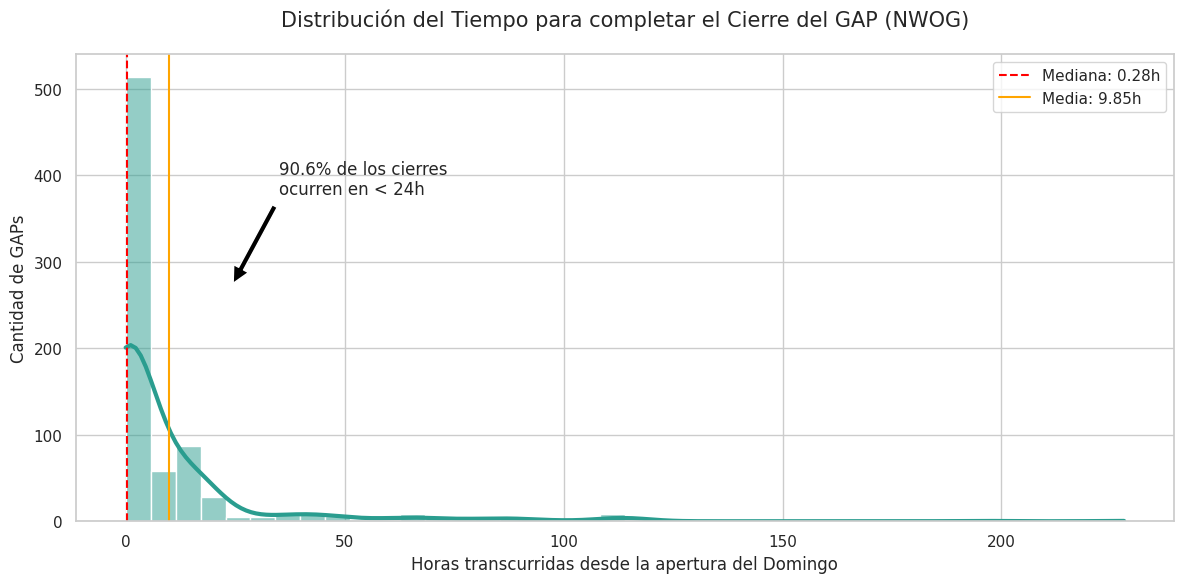

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

def mostrar_histograma_cierre(df_gaps):
    """
    Genera un histograma enfocado únicamente en el tiempo de cierre de los GAPs.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos en df_gaps para graficar.")
        return

    # Filtrar solo los registros donde el GAP efectivamente se cerró
    df_cerrados = df_gaps[df_gaps['gap_cerrado'] == True].copy()
    
    if df_cerrados.empty:
        print("⚠️ No se encontraron GAPs cerrados en la muestra.")
        return

    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Histograma con KDE (Línea de densidad)
    ax = sns.histplot(
        df_cerrados['horas_para_cierre'], 
        bins=40, 
        kde=True, 
        color='#2a9d8f',
        edgecolor='white',
        line_kws={'linewidth': 3}
    )
    
    # Añadir líneas de referencia (Mediana y Media)
    mediana = df_cerrados['horas_para_cierre'].median()
    media = df_cerrados['horas_para_cierre'].mean()
    
    plt.axvline(mediana, color='red', linestyle='--', label=f'Mediana: {mediana:.2f}h')
    plt.axvline(media, color='orange', linestyle='-', label=f'Media: {media:.2f}h')
    
    # Formato estético
    plt.title('Distribución del Tiempo para completar el Cierre del GAP (NWOG)', fontsize=15, pad=20)
    plt.xlabel('Horas transcurridas desde la apertura del Domingo', fontsize=12)
    plt.ylabel('Cantidad de GAPs', fontsize=12)
    plt.legend()
    
    # Mostrar el porcentaje de cierres en las primeras 24h
    cierres_24h = (df_cerrados['horas_para_cierre'] <= 24).mean() * 100
    plt.annotate(f'{cierres_24h:.1f}% de los cierres\nocurren en < 24h', 
                 xy=(24, ax.get_ylim()[1]*0.5), 
                 xytext=(35, ax.get_ylim()[1]*0.7),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.tight_layout()
    plt.show()

# Ejecución directa
mostrar_histograma_cierre(df_gaps)

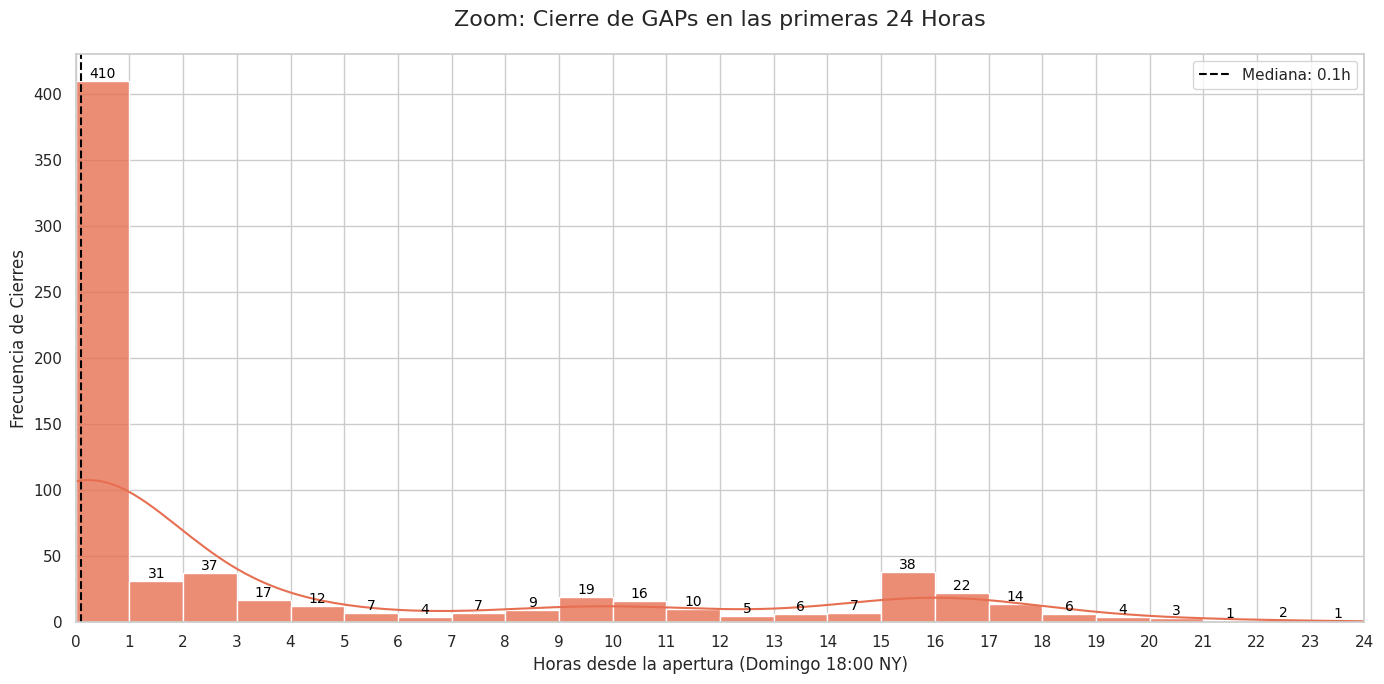

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def mostrar_histograma_cierre_24h(df_gaps):
    """
    Genera un histograma detallado por hora para los GAPs que cierran en las primeras 24h.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos en df_gaps para graficar.")
        return

    # Filtrar registros que cerraron dentro de las primeras 24 horas
    df_24h = df_gaps[(df_gaps['gap_cerrado'] == True) & (df_gaps['horas_para_cierre'] <= 24)].copy()
    
    if df_24h.empty:
        print("⚠️ No se encontraron GAPs que cerraran en las primeras 24 horas.")
        return

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    
    # Histograma con bins fijos (uno por cada hora)
    ax = sns.histplot(
        df_24h['horas_para_cierre'], 
        bins=24, 
        kde=True, 
        color='#e76f51',
        edgecolor='white',
        alpha=0.8
    )
    
    # Añadir líneas de referencia
    mediana = df_24h['horas_para_cierre'].median()
    plt.axvline(mediana, color='black', linestyle='--', label=f'Mediana: {mediana:.1f}h')
    
    # Configuración de los ejes
    plt.xticks(range(0, 25))
    plt.xlim(0, 24)
    
    # Formato estético
    plt.title('Zoom: Cierre de GAPs en las primeras 24 Horas', fontsize=16, pad=20)
    plt.xlabel('Horas desde la apertura (Domingo 18:00 NY)', fontsize=12)
    plt.ylabel('Frecuencia de Cierres', fontsize=12)
    plt.legend()
    
    # Etiquetar los bins con el conteo exacto
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        fontsize=10, color='black', xytext=(0, 5),
                        textcoords='offset points')

    plt.tight_layout()
    plt.show()

# Ejecución directa con los datos en memoria
mostrar_histograma_cierre_24h(df_gaps)

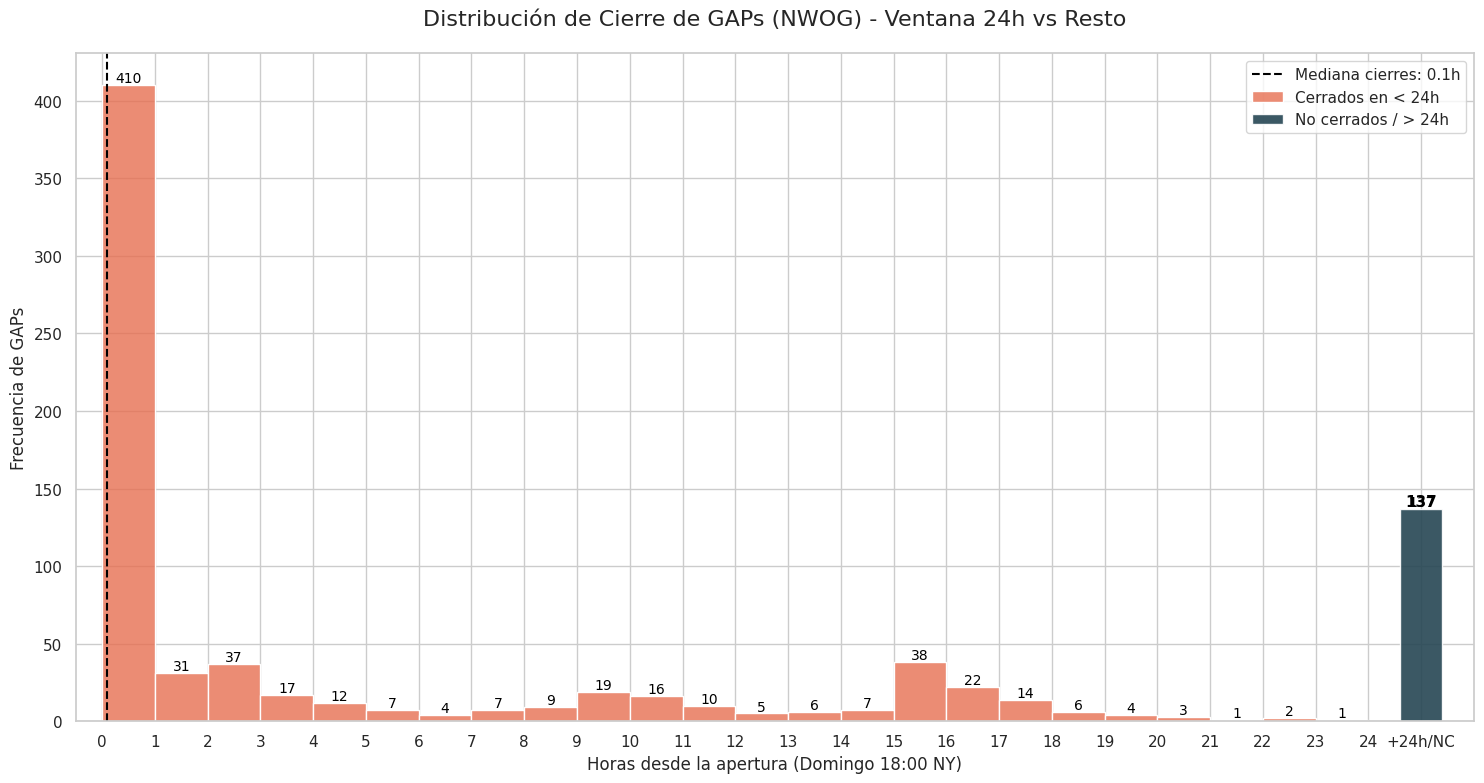

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def mostrar_histograma_cierre_24h(df_gaps):
    """
    Genera un histograma detallado por hora para los GAPs que cierran en las primeras 24h,
    añadiendo una barra especial para los que no cerraron en ese periodo.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos en df_gaps para graficar.")
        return

    # 1. GAPs que cerraron en <= 24h
    df_24h = df_gaps[(df_gaps['gap_cerrado'] == True) & (df_gaps['horas_para_cierre'] <= 24)].copy()
    
    # 2. GAPs que NO cerraron en <= 24h (ya sea que cerraron después o nunca)
    df_no_24h = df_gaps[(df_gaps['gap_cerrado'] == False) | (df_gaps['horas_para_cierre'] > 24)].copy()
    
    count_no_24h = len(df_no_24h)

    plt.figure(figsize=(15, 8))
    sns.set_theme(style="whitegrid")
    
    # Histograma de las primeras 24 horas
    ax = sns.histplot(
        df_24h['horas_para_cierre'], 
        bins=24, 
        color='#e76f51',
        edgecolor='white',
        alpha=0.8,
        label='Cerrados en < 24h'
    )
    
    # Añadir barra manual para la "Hora 25" (No cerrados/Tarde)
    plt.bar(25, count_no_24h, color='#264653', edgecolor='white', alpha=0.9, label='No cerrados / > 24h')
    
    # Añadir línea de Mediana solo para los que cerraron
    mediana = df_24h['horas_para_cierre'].median()
    plt.axvline(mediana, color='black', linestyle='--', label=f'Mediana cierres: {mediana:.1f}h')
    
    # Configuración de los ejes
    plt.xticks(list(range(0, 25)) + [25], list(range(0, 25)) + ['+24h/NC'])
    plt.xlim(-0.5, 26)
    
    # Formato estético
    plt.title('Distribución de Cierre de GAPs (NWOG) - Ventana 24h vs Resto', fontsize=16, pad=20)
    plt.xlabel('Horas desde la apertura (Domingo 18:00 NY)', fontsize=12)
    plt.ylabel('Frecuencia de GAPs', fontsize=12)
    plt.legend()
    
    # Etiquetar los bins con el conteo exacto
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        fontsize=10, color='black', xytext=(0, 5),
                        textcoords='offset points')

    # Etiqueta específica para la barra de +24h
    plt.annotate(f'{count_no_24h}', 
                (25, count_no_24h), 
                ha='center', va='center', 
                fontsize=11, fontweight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')

    plt.tight_layout()
    plt.show()

# Ejecución directa con los datos en memoria
mostrar_histograma_cierre_24h(df_gaps)

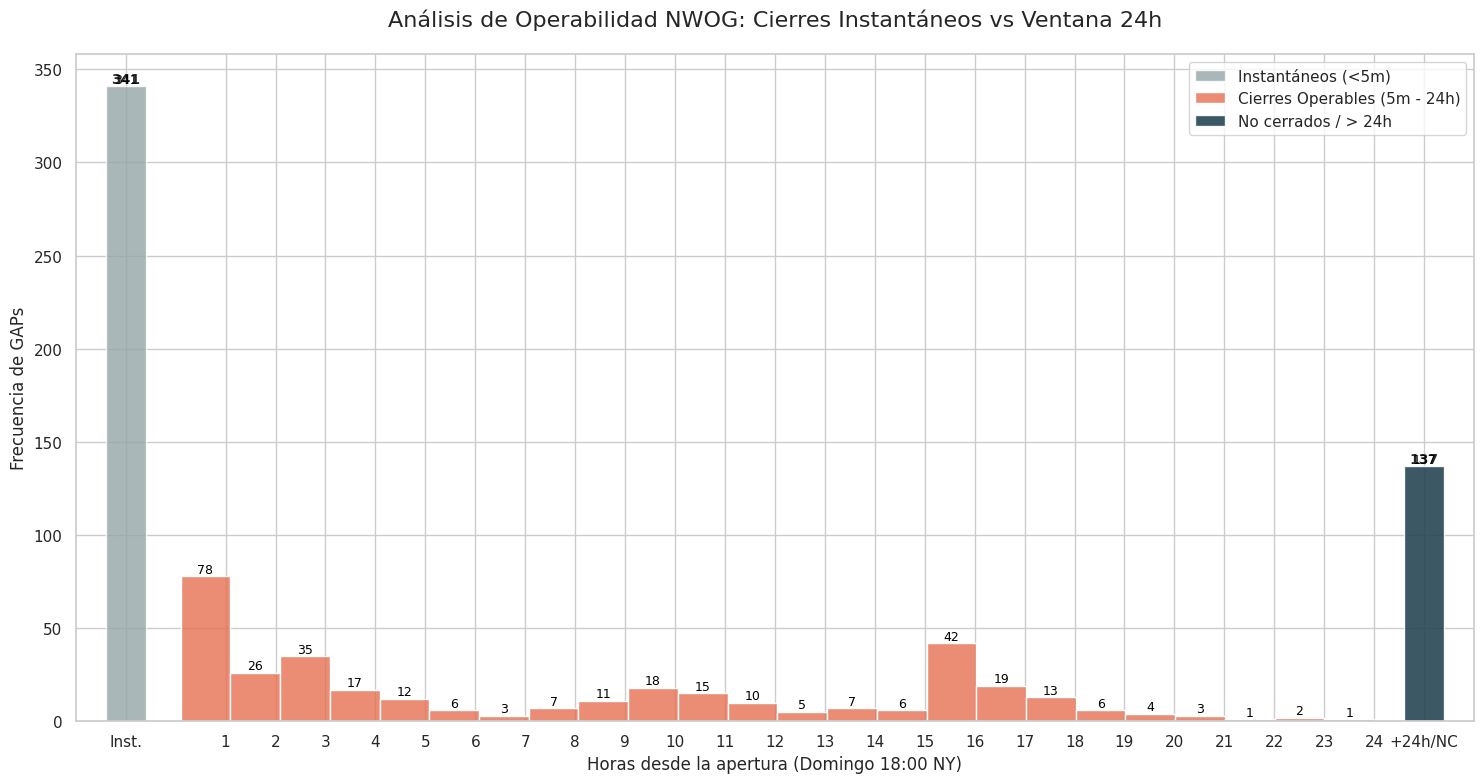

📊 Estadísticas de Operabilidad (Total GAPs: 825)
  - Instantáneos (<5m): 341 (41.3%)
  - Ventana Operable (1h-24h): 347 (42.1%)
  - Fuera de Ventana/NC: 137 (16.6%)


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def mostrar_histograma_cierre_24h(df_gaps, min_minutos_operables=5):
    """
    Genera un histograma detallado por hora para los GAPs que cierran en las primeras 24h,
    separando los cierres 'instantáneos' (ruido) de los operables.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos en df_gaps para graficar.")
        return

    umbral_horas = min_minutos_operables / 60.0

    # 1. GAPs Cerrados Instantáneos (Ruido < 5 min)
    df_inst = df_gaps[(df_gaps['gap_cerrado'] == True) & (df_gaps['horas_para_cierre'] < umbral_horas)].copy()
    
    # 2. GAPs Cerrados Operables (Entre 5 min y 24h)
    df_24h_operable = df_gaps[(df_gaps['gap_cerrado'] == True) & 
                               (df_gaps['horas_para_cierre'] >= umbral_horas) & 
                               (df_gaps['horas_para_cierre'] <= 24)].copy()
    
    # 3. GAPs que NO cerraron en la ventana de 24h
    df_no_24h = df_gaps[(df_gaps['gap_cerrado'] == False) | (df_gaps['horas_para_cierre'] > 24)].copy()
    
    count_inst = len(df_inst)
    count_no_24h = len(df_no_24h)

    plt.figure(figsize=(15, 8))
    sns.set_theme(style="whitegrid")
    
    # Barra para los Instantáneos (Posición -1 o 0 especial)
    plt.bar(-1, count_inst, color='#95a5a6', edgecolor='white', alpha=0.8, label=f'Instantáneos (<{min_minutos_operables}m)')
    
    # Histograma de las primeras 24 horas (Operables)
    ax = sns.histplot(
        df_24h_operable['horas_para_cierre'], 
        bins=24, 
        color='#e76f51',
        edgecolor='white',
        alpha=0.8,
        label='Cierres Operables (5m - 24h)'
    )
    
    # Barra para +24h / No Cerrados
    plt.bar(25, count_no_24h, color='#264653', edgecolor='white', alpha=0.9, label='No cerrados / > 24h')
    
    # Configuración de los ejes
    labels_x = ['Inst.'] + list(range(1, 25)) + ['+24h/NC']
    positions_x = [-1] + list(range(1, 25)) + [25]
    plt.xticks(positions_x, labels_x)
    plt.xlim(-2, 26)
    
    # Formato estético
    plt.title(f'Análisis de Operabilidad NWOG: Cierres Instantáneos vs Ventana 24h', fontsize=16, pad=20)
    plt.xlabel('Horas desde la apertura (Domingo 18:00 NY)', fontsize=12)
    plt.ylabel('Frecuencia de GAPs', fontsize=12)
    plt.legend()
    
    # Etiquetar barras
    # Etiqueta para instantáneos
    plt.annotate(f'{count_inst}', (-1, count_inst), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Etiqueta para +24h
    plt.annotate(f'{count_no_24h}', (25, count_no_24h), ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Etiquetar los bins del histograma
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        fontsize=9, color='black', xytext=(0, 5),
                        textcoords='offset points')

    plt.tight_layout()
    plt.show()
    
    # Print informativo
    total = len(df_gaps)
    print(f"📊 Estadísticas de Operabilidad (Total GAPs: {total})")
    print(f"  - Instantáneos (<{min_minutos_operables}m): {count_inst} ({count_inst/total:.1%})")
    print(f"  - Ventana Operable (1h-24h): {len(df_24h_operable)} ({len(df_24h_operable)/total:.1%})")
    print(f"  - Fuera de Ventana/NC: {count_no_24h} ({count_no_24h/total:.1%})")

# Ejecución directa
mostrar_histograma_cierre_24h(df_gaps, min_minutos_operables=5)

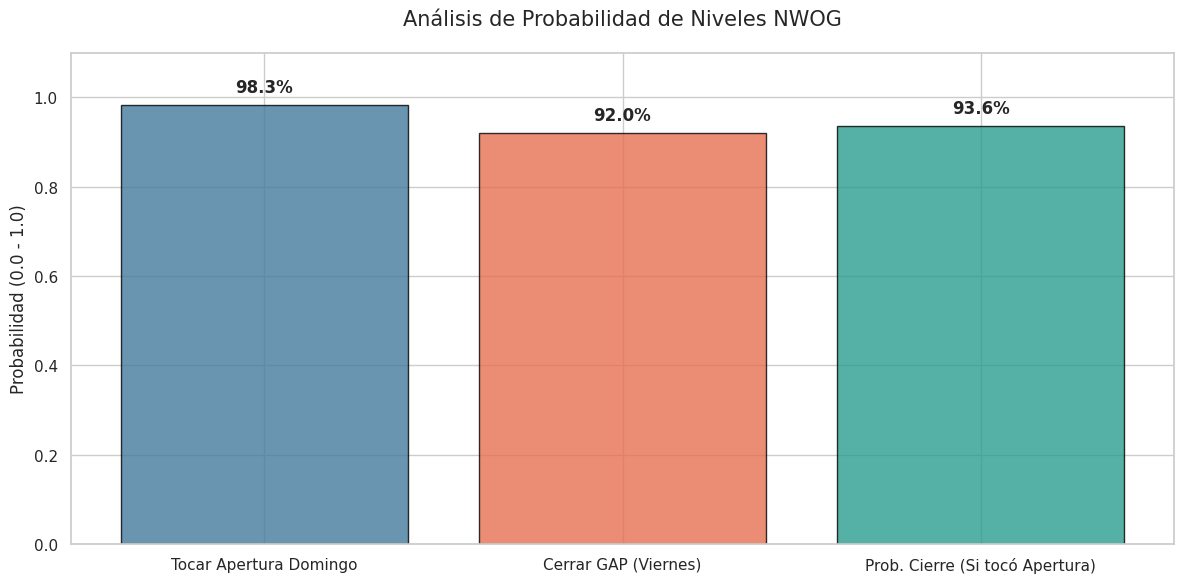

📊 Análisis de Probabilidades (N=825):
  - Prob. de alcanzar Apertura Domingo: 98.3%
  - Prob. de alcanzar Cierre Viernes: 92.0%
  - Prob. Condicional (Cierre | Toco Apertura): 93.6%


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=5):
    """
    Analiza la probabilidad de alcanzar el nivel de Apertura (Domingo) 
    y el nivel de Cierre (Viernes) tras un alejamiento inicial.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    umbral_horas = min_minutos_operables / 60.0
    total_casos = len(df_gaps)

    # 1. ¿Llegó a Apertura Domingo? (Ya lo tenemos por definición, pero buscamos 
    # casos que se alejaron > 0 y luego volvieron)
    llegaron_apertura = df_gaps[df_gaps['max_recorrido_opuesto'] > 0] 
    
    # 2. ¿Llegó a Cierre Viernes? (Gap Cerrado)
    llegaron_cierre = df_gaps[df_gaps['gap_cerrado'] == True]

    # Estadísticas de probabilidad
    prob_apertura = len(llegaron_apertura) / total_casos
    prob_cierre = len(llegaron_cierre) / total_casos
    
    # Probabilidad Condicional: Si llegó a Apertura, ¿qué tan probable es que cierre el GAP?
    casos_volvieron_apertura = llegaron_apertura
    cerraron_tras_volver = casos_volvieron_apertura[casos_volvieron_apertura['gap_cerrado'] == True]
    prob_condicional = len(cerraron_tras_volver) / len(casos_volvieron_apertura) if not casos_volvieron_apertura.empty else 0

    # --- VISUALIZACIÓN ---
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Gráfico de barras de probabilidad
    labels = ['Tocar Apertura Domingo', 'Cerrar GAP (Viernes)', 'Prob. Cierre (Si tocó Apertura)']
    valores = [prob_apertura, prob_cierre, prob_condicional]
    colors = ['#457b9d', '#e76f51', '#2a9d8f']

    bars = plt.bar(labels, valores, color=colors, alpha=0.8, edgecolor='black')
    
    # Añadir porcentajes sobre las barras
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

    plt.ylim(0, 1.1)
    plt.title('Análisis de Probabilidad de Niveles NWOG', fontsize=15, pad=20)
    plt.ylabel('Probabilidad (0.0 - 1.0)')
    
    plt.tight_layout()
    plt.show()

    print(f"📊 Análisis de Probabilidades (N={total_casos}):")
    print(f"  - Prob. de alcanzar Apertura Domingo: {prob_apertura:.1%}")
    print(f"  - Prob. de alcanzar Cierre Viernes: {prob_cierre:.1%}")
    print(f"  - Prob. Condicional (Cierre | Toco Apertura): {prob_condicional:.1%}")

# Ejecución
analizar_niveles_probabilidad(df_gaps)

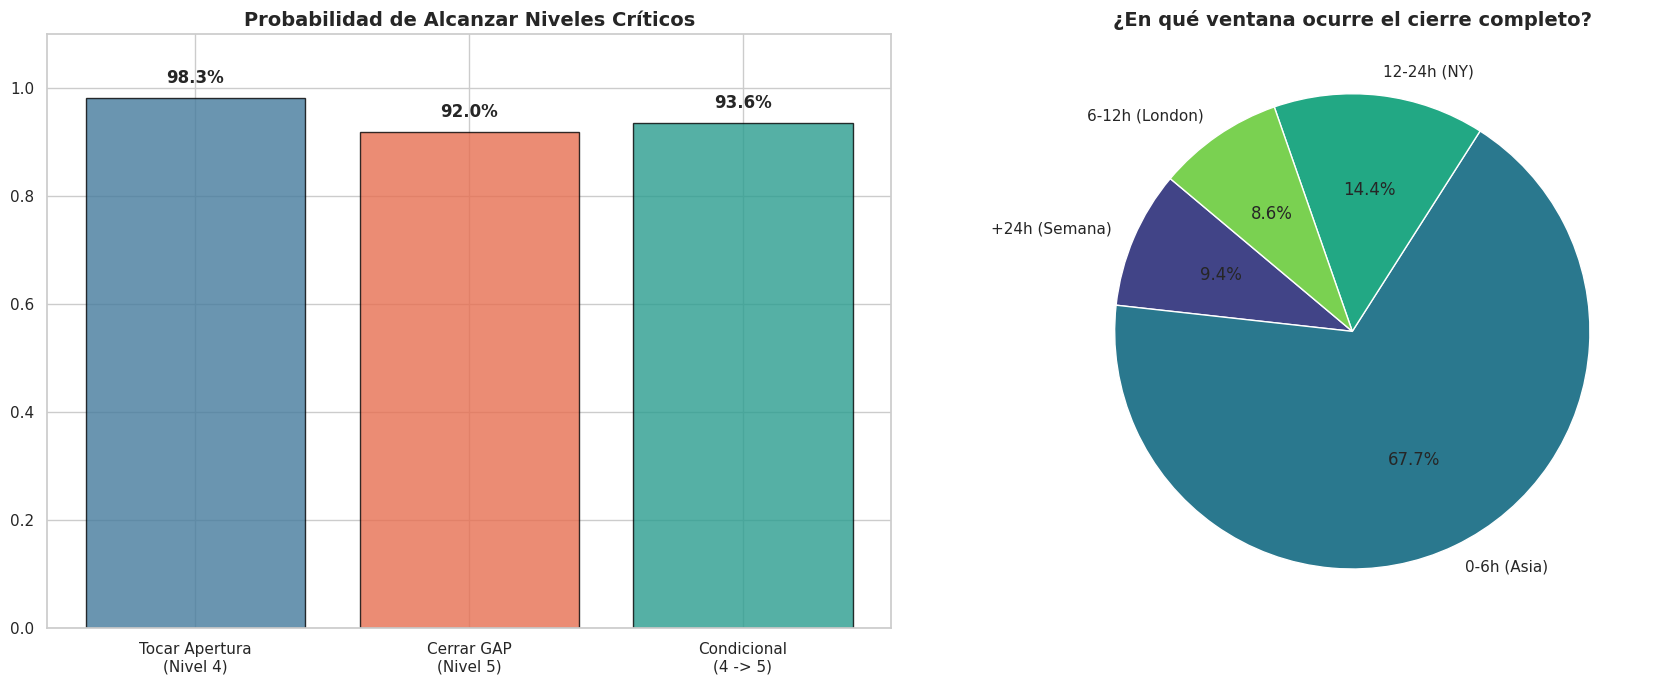

📊 Estadísticas de Ejecución (N=825):
  - El 98.3%(Nivel 4) es casi una certeza estadística.
  - Si el precio vuelve a la apertura, tienes un 93.6% de probabilidad de completar el trade al cierre del viernes.
  - Nota: El 67.7% de los cierres ocurren en la sesión asiática.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=5):
    """
    Analiza la probabilidad de alcanzar el nivel de Apertura (Domingo) 
    y el nivel de Cierre (Viernes) con desglose temporal para definir la vigencia del setup.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    total_casos = len(df_gaps)

    # 1. Probabilidades Base
    llegaron_apertura = df_gaps[df_gaps['max_recorrido_opuesto'] > 0] 
    llegaron_cierre = df_gaps[df_gaps['gap_cerrado'] == True]
    
    prob_apertura = len(llegaron_apertura) / total_casos
    prob_cierre = len(llegaron_cierre) / total_casos
    
    # Probabilidad Condicional: P(Cierre | Apertura)
    prob_condicional = len(llegaron_cierre) / len(llegaron_apertura) if len(llegaron_apertura) > 0 else 0

    # 2. Análisis por Ventanas Temporales (Vigencia del Setup)
    # Queremos saber cuántos cierran en ventanas específicas
    def categorizar_tiempo(h):
        if h <= 6: return '0-6h (Asia)'
        if h <= 12: return '6-12h (London)'
        if h <= 24: return '12-24h (NY)'
        return '+24h (Semana)'

    df_filt = df_gaps[df_gaps['gap_cerrado'] == True].copy()
    df_filt['ventana'] = df_filt['horas_para_cierre'].apply(categorizar_tiempo)
    dist_temporal = df_filt['ventana'].value_counts(normalize=True).sort_index()

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Probabilidades de Niveles
    labels = ['Tocar Apertura\n(Nivel 4)', 'Cerrar GAP\n(Nivel 5)', 'Condicional\n(4 -> 5)']
    valores = [prob_apertura, prob_cierre, prob_condicional]
    colors = ['#457b9d', '#e76f51', '#2a9d8f']

    bars = ax1.bar(labels, valores, color=colors, alpha=0.8, edgecolor='black')
    ax1.set_ylim(0, 1.1)
    ax1.set_title('Probabilidad de Alcanzar Niveles Críticos', fontsize=14, fontweight='bold')
    
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom', fontweight='bold')

    # Gráfico 2: ¿Cuándo ocurre el cierre?
    dist_temporal.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(dist_temporal)), 
                       startangle=140, wedgeprops={'edgecolor': 'white'})
    ax2.set_ylabel('')
    ax2.set_title('¿En qué ventana ocurre el cierre completo?', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"📊 Estadísticas de Ejecución (N={total_casos}):")
    print(f"  - El {prob_apertura:.1%}(Nivel 4) es casi una certeza estadística.")
    print(f"  - Si el precio vuelve a la apertura, tienes un {prob_condicional:.1%} de probabilidad de completar el trade al cierre del viernes.")
    print(f"  - Nota: El {dist_temporal.get('0-6h (Asia)', 0):.1%} de los cierres ocurren en la sesión asiática.")

# Ejecución
analizar_niveles_probabilidad(df_gaps)


📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG**
--------------------------------------------------
📊 **Probabilidades de Niveles (N=825 semanas):**
• Tocar Apertura Domingo (Nivel 4): 98.3%
• Cerrar GAP completo (Nivel 5): 92.0%
• Prob. Condicional (Si toca Nivel 4 -> llega a Nivel 5): 93.6%

🕒 **Distribución Temporal de Cierres:**
• Sesión Asia (0-6h): 67.7%
• Sesión London (6-12h): 8.6%
• Sesión NY (12-24h): 14.4%
• Resto de la Semana (+24h): 9.4%

💡 *Nota: El 93.6% de probabilidad condicional sugiere que el nivel de apertura es el trigger de alta probabilidad para el cierre total.*
--------------------------------------------------
    


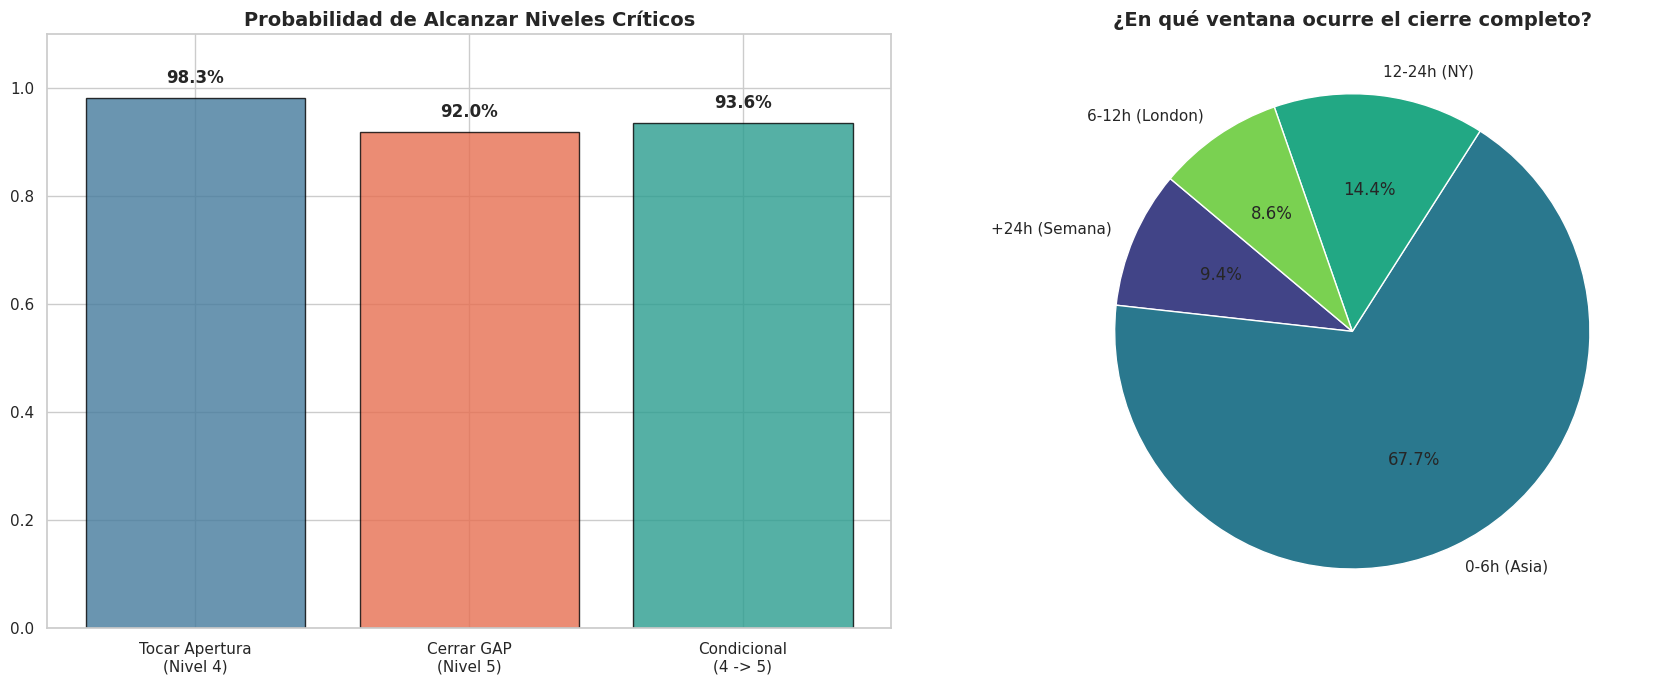

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=5):
    """
    Analiza la probabilidad de alcanzar el nivel de Apertura (Domingo) 
    y el nivel de Cierre (Viernes) con desglose temporal para definir la vigencia del setup.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    total_casos = len(df_gaps)

    # 1. Probabilidades Base
    llegaron_apertura = df_gaps[df_gaps['max_recorrido_opuesto'] > 0] 
    llegaron_cierre = df_gaps[df_gaps['gap_cerrado'] == True]
    
    prob_apertura = len(llegaron_apertura) / total_casos
    prob_cierre = len(llegaron_cierre) / total_casos
    
    # Probabilidad Condicional: P(Cierre | Apertura)
    prob_condicional = len(llegaron_cierre) / len(llegaron_apertura) if len(llegaron_apertura) > 0 else 0

    # 2. Análisis por Ventanas Temporales (Vigencia del Setup)
    def categorizar_tiempo(h):
        if h <= 6: return '0-6h (Asia)'
        if h <= 12: return '6-12h (London)'
        if h <= 24: return '12-24h (NY)'
        return '+24h (Semana)'

    df_filt = df_gaps[df_gaps['gap_cerrado'] == True].copy()
    df_filt['ventana'] = df_filt['horas_para_cierre'].apply(categorizar_tiempo)
    dist_temporal = df_filt['ventana'].value_counts(normalize=True).sort_index()

    # --- TEXTO PARA PEGAR EN CHAT ---
    texto_resumen = f"""
📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG**
--------------------------------------------------
📊 **Probabilidades de Niveles (N={total_casos} semanas):**
• Tocar Apertura Domingo (Nivel 4): {prob_apertura:.1%}
• Cerrar GAP completo (Nivel 5): {prob_cierre:.1%}
• Prob. Condicional (Si toca Nivel 4 -> llega a Nivel 5): {prob_condicional:.1%}

🕒 **Distribución Temporal de Cierres:**
• Sesión Asia (0-6h): {dist_temporal.get('0-6h (Asia)', 0):.1%}
• Sesión London (6-12h): {dist_temporal.get('6-12h (London)', 0):.1%}
• Sesión NY (12-24h): {dist_temporal.get('12-24h (NY)', 0):.1%}
• Resto de la Semana (+24h): {dist_temporal.get('+24h (Semana)', 0):.1%}

💡 *Nota: El {prob_condicional:.1%} de probabilidad condicional sugiere que el nivel de apertura es el trigger de alta probabilidad para el cierre total.*
--------------------------------------------------
    """
    print(texto_resumen)

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Probabilidades de Niveles
    labels = ['Tocar Apertura\n(Nivel 4)', 'Cerrar GAP\n(Nivel 5)', 'Condicional\n(4 -> 5)']
    valores = [prob_apertura, prob_cierre, prob_condicional]
    colors = ['#457b9d', '#e76f51', '#2a9d8f']

    bars = ax1.bar(labels, valores, color=colors, alpha=0.8, edgecolor='black')
    ax1.set_ylim(0, 1.1)
    ax1.set_title('Probabilidad de Alcanzar Niveles Críticos', fontsize=14, fontweight='bold')
    
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom', fontweight='bold')

    # Gráfico 2: ¿Cuándo ocurre el cierre?
    if not dist_temporal.empty:
        dist_temporal.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(dist_temporal)), 
                           startangle=140, wedgeprops={'edgecolor': 'white'})
        ax2.set_ylabel('')
        ax2.set_title('¿En qué ventana ocurre el cierre completo?', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps)


📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG**
--------------------------------------------------
📊 **Probabilidades de Niveles (N=825 semanas):**
• Tocar Apertura Domingo (Nivel 4): 98.3%
• Cerrar GAP completo (Nivel 5): 92.0%
• Prob. Condicional (Si toca Nivel 4 -> llega a Nivel 5): 93.6%

🕒 **Distribución Temporal de Cierres:**
• Sesión Asia (0-6h): 67.7%
• Sesión London (6-12h): 8.6%
• Sesión NY (12-24h): 14.4%
• Resto de la Semana (+24h): 9.4%

💡 *Nota: El 93.6% de probabilidad condicional sugiere que el nivel de apertura es el trigger de alta probabilidad para el cierre total.*
--------------------------------------------------
    


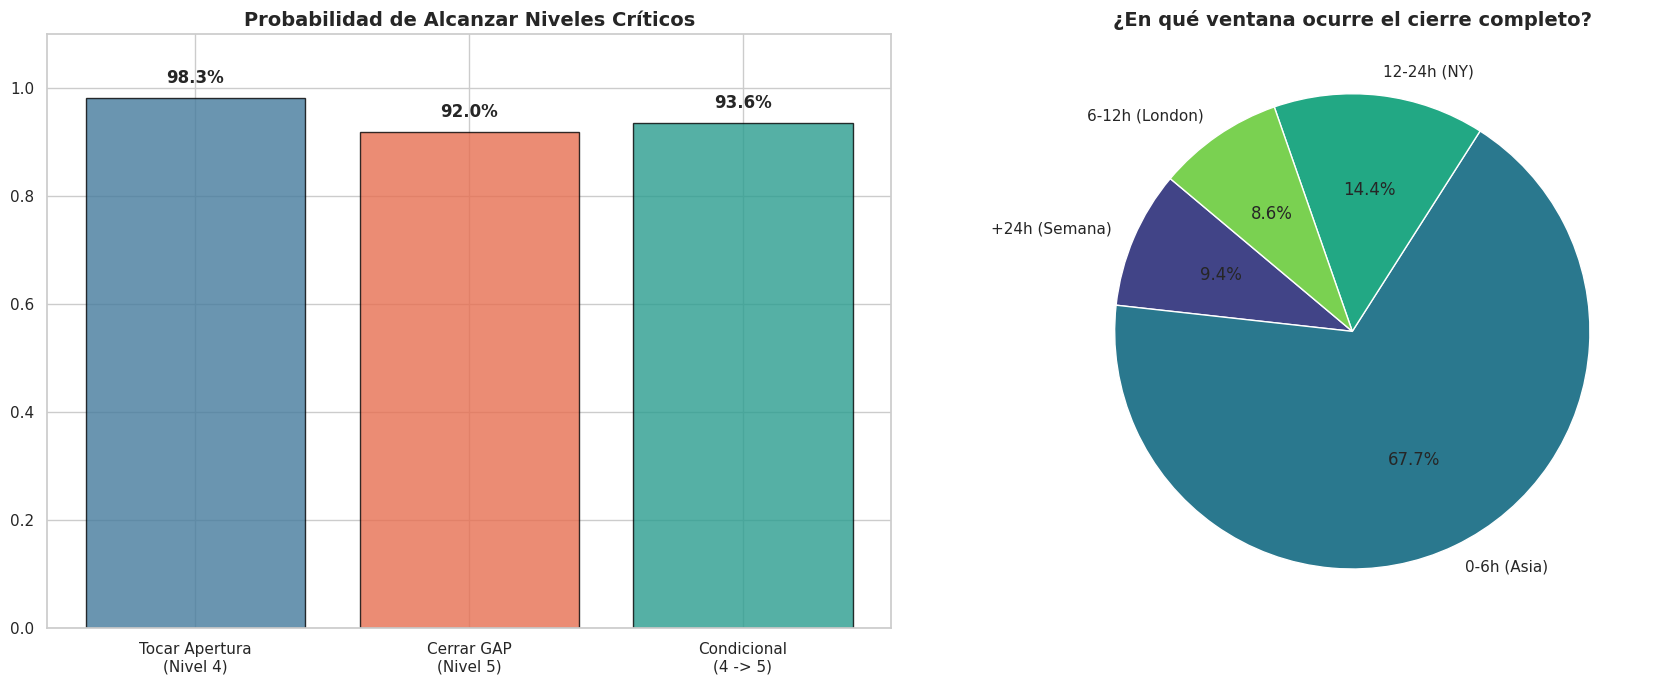

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=5):
    """
    Analiza la probabilidad de alcanzar el nivel de Apertura (Domingo) 
    y el nivel de Cierre (Viernes) con desglose temporal para definir la vigencia del setup.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    total_casos = len(df_gaps)

    # 1. Probabilidades Base
    llegaron_apertura = df_gaps[df_gaps['max_recorrido_opuesto'] > 0] 
    llegaron_cierre = df_gaps[df_gaps['gap_cerrado'] == True]
    
    prob_apertura = len(llegaron_apertura) / total_casos
    prob_cierre = len(llegaron_cierre) / total_casos
    
    # Probabilidad Condicional: P(Cierre | Apertura)
    prob_condicional = len(llegaron_cierre) / len(llegaron_apertura) if len(llegaron_apertura) > 0 else 0

    # 2. Análisis por Ventanas Temporales (Vigencia del Setup)
    def categorizar_tiempo(h):
        if h <= 6: return '0-6h (Asia)'
        if h <= 12: return '6-12h (London)'
        if h <= 24: return '12-24h (NY)'
        return '+24h (Semana)'

    df_filt = df_gaps[df_gaps['gap_cerrado'] == True].copy()
    df_filt['ventana'] = df_filt['horas_para_cierre'].apply(categorizar_tiempo)
    dist_temporal = df_filt['ventana'].value_counts(normalize=True).sort_index()

    # --- TEXTO PARA PEGAR EN CHAT ---
    texto_resumen = f"""
📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG**
--------------------------------------------------
📊 **Probabilidades de Niveles (N={total_casos} semanas):**
• Tocar Apertura Domingo (Nivel 4): {prob_apertura:.1%}
• Cerrar GAP completo (Nivel 5): {prob_cierre:.1%}
• Prob. Condicional (Si toca Nivel 4 -> llega a Nivel 5): {prob_condicional:.1%}

🕒 **Distribución Temporal de Cierres:**
• Sesión Asia (0-6h): {dist_temporal.get('0-6h (Asia)', 0):.1%}
• Sesión London (6-12h): {dist_temporal.get('6-12h (London)', 0):.1%}
• Sesión NY (12-24h): {dist_temporal.get('12-24h (NY)', 0):.1%}
• Resto de la Semana (+24h): {dist_temporal.get('+24h (Semana)', 0):.1%}

💡 *Nota: El {prob_condicional:.1%} de probabilidad condicional sugiere que el nivel de apertura es el trigger de alta probabilidad para el cierre total.*
--------------------------------------------------
    """
    print(texto_resumen)

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Probabilidades de Niveles
    labels = ['Tocar Apertura\n(Nivel 4)', 'Cerrar GAP\n(Nivel 5)', 'Condicional\n(4 -> 5)']
    valores = [prob_apertura, prob_cierre, prob_condicional]
    colors = ['#457b9d', '#e76f51', '#2a9d8f']

    bars = ax1.bar(labels, valores, color=colors, alpha=0.8, edgecolor='black')
    ax1.set_ylim(0, 1.1)
    ax1.set_title('Probabilidad de Alcanzar Niveles Críticos', fontsize=14, fontweight='bold')
    
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom', fontweight='bold')

    # Gráfico 2: ¿Cuándo ocurre el cierre?
    if not dist_temporal.empty:
        dist_temporal.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(dist_temporal)), 
                           startangle=140, wedgeprops={'edgecolor': 'white'})
        ax2.set_ylabel('')
        ax2.set_title('¿En qué ventana ocurre el cierre completo?', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps)

📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG**
--------------------------------------------------
📊 **Probabilidades de Niveles (N=825 semanas):**
• Tocar Apertura Domingo (Nivel 4): 98.3%
• Cerrar GAP completo (Nivel 5): 92.0%
• Prob. Condicional (Si toca Nivel 4 -> llega a Nivel 5): 93.6%

🕒 **Distribución Temporal de Cierres:**
• Sesión Asia (0-6h): 67.7%
• Sesión London (6-12h): 8.6%
• Sesión NY (12-24h): 14.4%
• Resto de la Semana (+24h): 9.4%

💡 *Nota: El 93.6% de probabilidad condicional sugiere que el nivel de apertura es el trigger de alta probabilidad para el cierre total.*
--------------------------------------------------


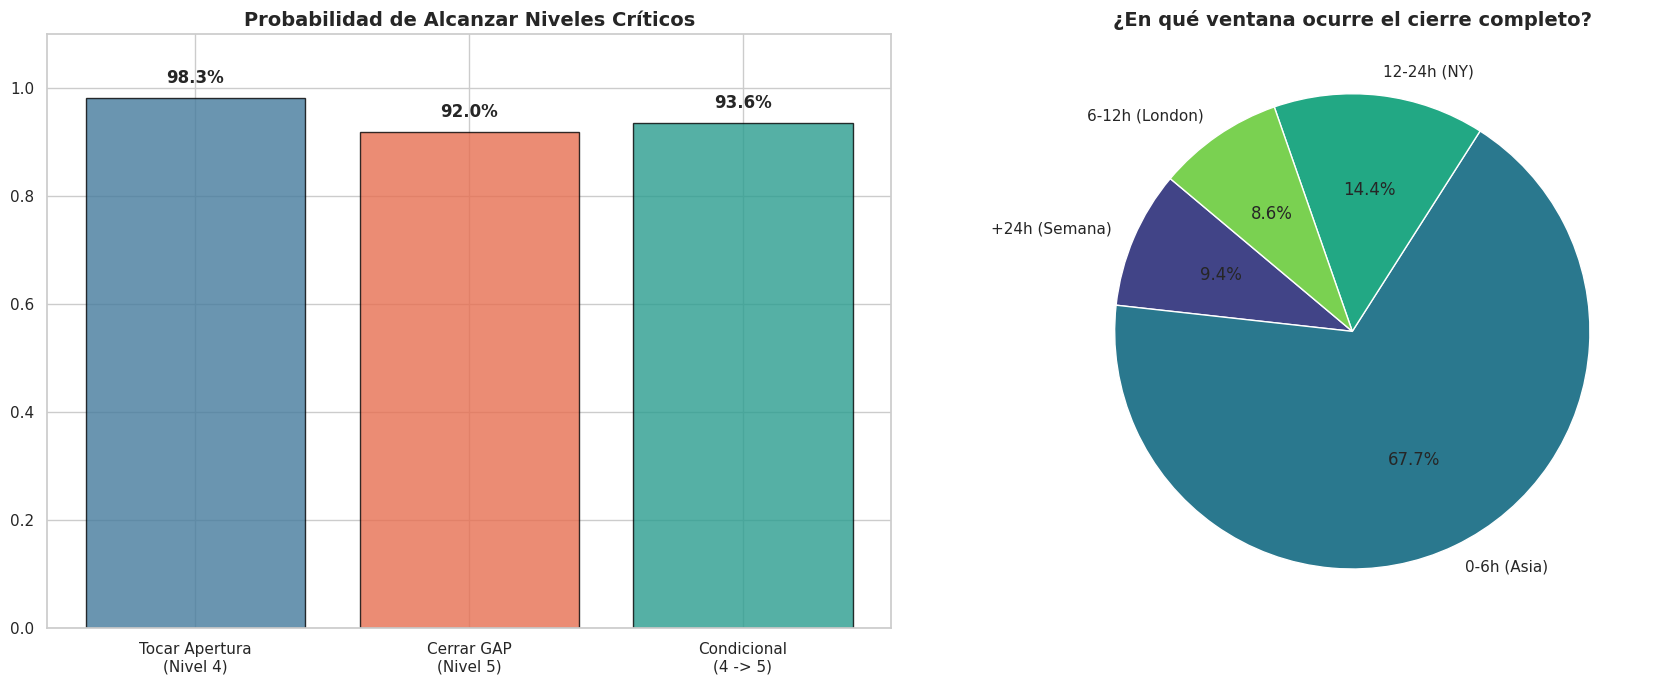

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=5):
    """
    Analiza la probabilidad de alcanzar el nivel de Apertura (Domingo) 
    y el nivel de Cierre (Viernes) con desglose temporal para definir la vigencia del setup.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    total_casos = len(df_gaps)

    # 1. Probabilidades Base
    llegaron_apertura = df_gaps[df_gaps['max_recorrido_opuesto'] > 0] 
    llegaron_cierre = df_gaps[df_gaps['gap_cerrado'] == True]
    
    prob_apertura = len(llegaron_apertura) / total_casos
    prob_cierre = len(llegaron_cierre) / total_casos
    
    # Probabilidad Condicional: P(Cierre | Apertura)
    prob_condicional = len(llegaron_cierre) / len(llegaron_apertura) if len(llegaron_apertura) > 0 else 0

    # 2. Análisis por Ventanas Temporales (Vigencia del Setup)
    def categorizar_tiempo(h):
        if h <= 6: return '0-6h (Asia)'
        if h <= 12: return '6-12h (London)'
        if h <= 24: return '12-24h (NY)'
        return '+24h (Semana)'

    df_filt = df_gaps[df_gaps['gap_cerrado'] == True].copy()
    df_filt['ventana'] = df_filt['horas_para_cierre'].apply(categorizar_tiempo)
    dist_temporal = df_filt['ventana'].value_counts(normalize=True).sort_index()

    # --- TEXTO PARA PEGAR EN CHAT ---
    # Usamos comillas simples internas para evitar conflictos de sintaxis en el editor
    texto_resumen = (
        f"📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG**\n"
        f"--------------------------------------------------\n"
        f"📊 **Probabilidades de Niveles (N={total_casos} semanas):**\n"
        f"• Tocar Apertura Domingo (Nivel 4): {prob_apertura:.1%}\n"
        f"• Cerrar GAP completo (Nivel 5): {prob_cierre:.1%}\n"
        f"• Prob. Condicional (Si toca Nivel 4 -> llega a Nivel 5): {prob_condicional:.1%}\n\n"
        f"🕒 **Distribución Temporal de Cierres:**\n"
        f"• Sesión Asia (0-6h): {dist_temporal.get('0-6h (Asia)', 0):.1%}\n"
        f"• Sesión London (6-12h): {dist_temporal.get('6-12h (London)', 0):.1%}\n"
        f"• Sesión NY (12-24h): {dist_temporal.get('12-24h (NY)', 0):.1%}\n"
        f"• Resto de la Semana (+24h): {dist_temporal.get('+24h (Semana)', 0):.1%}\n\n"
        f"💡 *Nota: El {prob_condicional:.1%} de probabilidad condicional sugiere que el nivel de apertura es el trigger de alta probabilidad para el cierre total.*\n"
        f"--------------------------------------------------"
    )
    print(texto_resumen)

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Probabilidades de Niveles
    labels = ['Tocar Apertura\n(Nivel 4)', 'Cerrar GAP\n(Nivel 5)', 'Condicional\n(4 -> 5)']
    valores = [prob_apertura, prob_cierre, prob_condicional]
    colors = ['#457b9d', '#e76f51', '#2a9d8f']

    bars = ax1.bar(labels, valores, color=colors, alpha=0.8, edgecolor='black')
    ax1.set_ylim(0, 1.1)
    ax1.set_title('Probabilidad de Alcanzar Niveles Críticos', fontsize=14, fontweight='bold')
    
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom', fontweight='bold')

    # Gráfico 2: ¿Cuándo ocurre el cierre?
    if not dist_temporal.empty:
        dist_temporal.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(dist_temporal)), 
                           startangle=140, wedgeprops={'edgecolor': 'white'})
        ax2.set_ylabel('')
        ax2.set_title('¿En qué ventana ocurre el cierre completo?', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps)

📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG**
--------------------------------------------------
📊 **Probabilidades de Niveles (N=825 semanas):**
• Tocar Apertura Domingo (Nivel 4): 98.3%
• Cerrar GAP completo (Nivel 5): 92.0%
• Prob. Condicional (Si toca Nivel 4 -> llega a Nivel 5): 93.6%

⏰ **DESGLOSE DE CIERRES POR HORA (0-24h):**
• Hora 00: 49.7% de los GAPs totales
• Hora 01: 3.8% de los GAPs totales
• Hora 02: 4.5% de los GAPs totales
• Hora 03: 2.1% de los GAPs totales
• Hora 04: 1.5% de los GAPs totales
• Hora 05: 0.8% de los GAPs totales
• Hora 06: 0.5% de los GAPs totales
• Hora 07: 0.8% de los GAPs totales
• Hora 08: 1.1% de los GAPs totales
• Hora 09: 2.3% de los GAPs totales
• Hora 10: 1.9% de los GAPs totales
• Hora 11: 1.2% de los GAPs totales
• Hora 12: 0.6% de los GAPs totales
• Hora 13: 0.7% de los GAPs totales
• Hora 14: 0.8% de los GAPs totales
• Hora 15: 4.6% de los GAPs totales
• Hora 16: 2.7% de los GAPs totales
• Hora 17: 1.7% de los GAPs totales
• Hora 18: 0.7% de

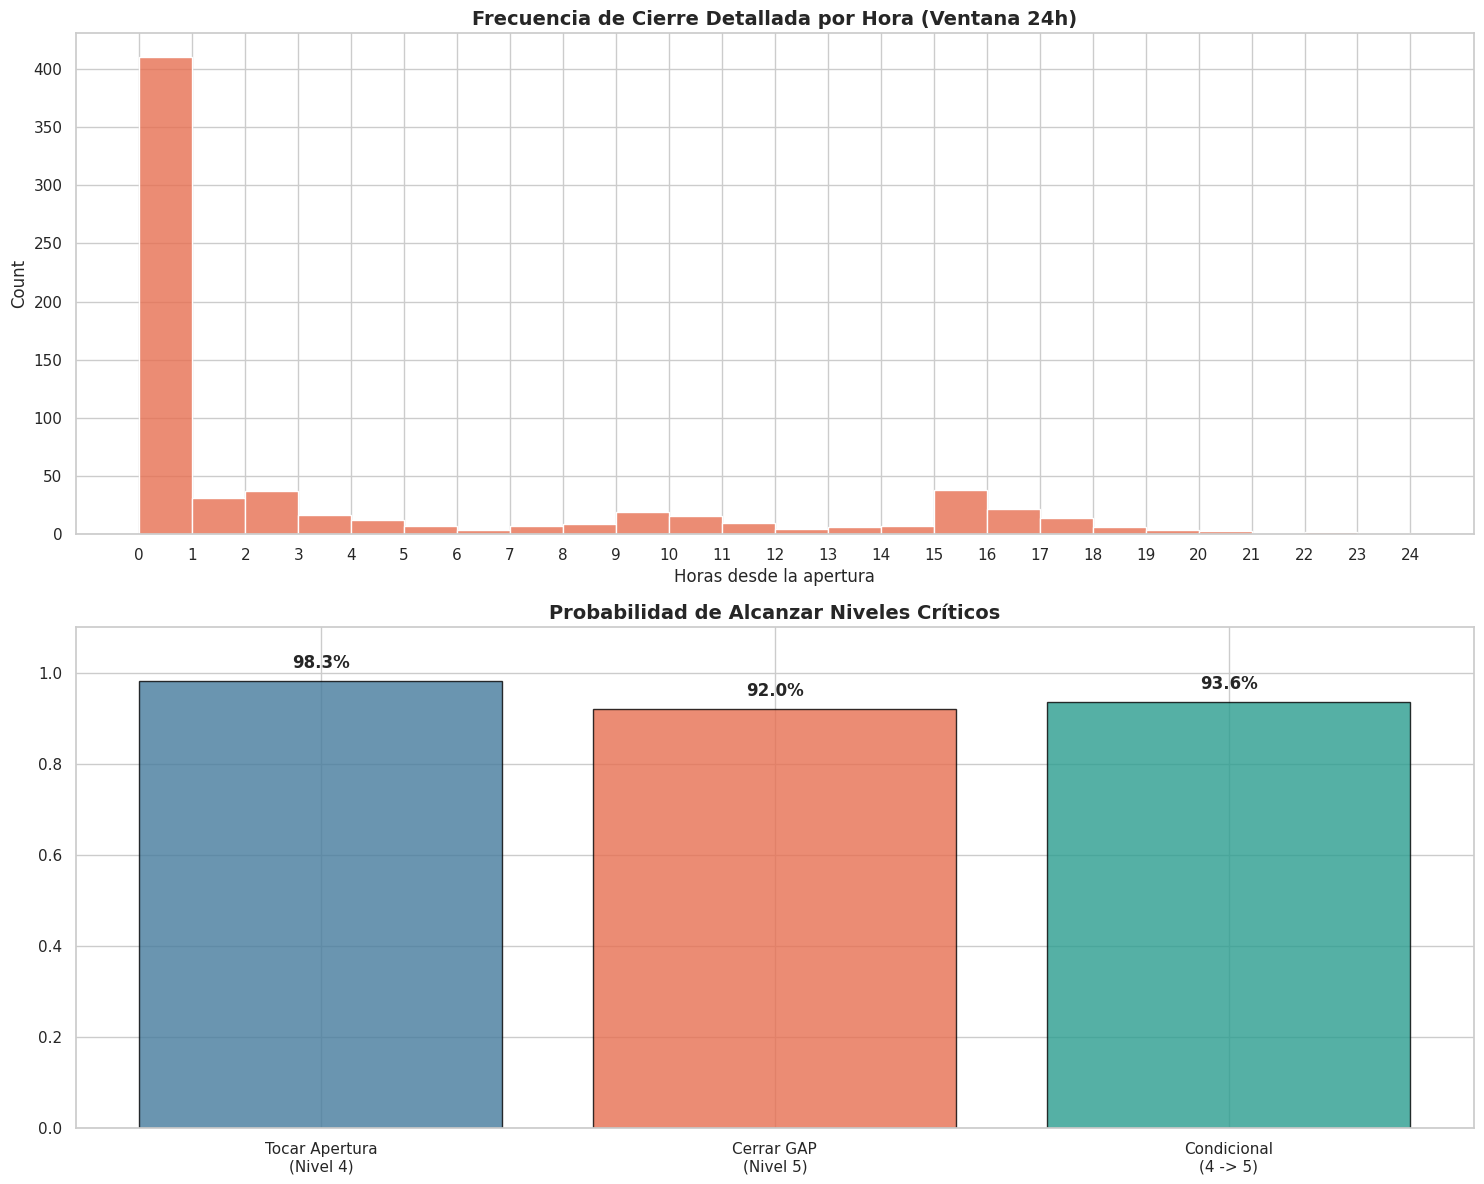

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=5):
    """
    Analiza la probabilidad de alcanzar el nivel de Apertura (Domingo) 
    y el nivel de Cierre (Viernes) con desglose detallado por hora.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    total_casos = len(df_gaps)

    # 1. Probabilidades Base
    llegaron_apertura = df_gaps[df_gaps['max_recorrido_opuesto'] > 0] 
    llegaron_cierre = df_gaps[df_gaps['gap_cerrado'] == True]
    
    prob_apertura = len(llegaron_apertura) / total_casos
    prob_cierre = len(llegaron_cierre) / total_casos
    
    # Probabilidad Condicional: P(Cierre | Apertura)
    prob_condicional = len(llegaron_cierre) / len(llegaron_apertura) if len(llegaron_apertura) > 0 else 0

    # 2. Desglose detallado por hora para el texto
    df_cerrados = df_gaps[df_gaps['gap_cerrado'] == True].copy()
    
    # Creamos un conteo por hora entera (0, 1, 2... 23)
    df_cerrados['hora_entera'] = df_cerrados['horas_para_cierre'].astype(int)
    conteo_por_hora = df_cerrados[df_cerrados['hora_entera'] < 24]['hora_entera'].value_counts().sort_index()
    
    # 3. Categorías de Ventanas (para el resumen)
    def categorizar_tiempo(h):
        if h <= 6: return '0-6h (Asia)'
        if h <= 12: return '6-12h (London)'
        if h <= 24: return '12-24h (NY)'
        return '+24h (Semana)'

    df_cerrados['ventana'] = df_cerrados['horas_para_cierre'].apply(categorizar_tiempo)
    dist_ventana = df_cerrados['ventana'].value_counts(normalize=True).sort_index()

    # --- TEXTO PARA PEGAR EN CHAT ---
    # Construimos la tabla de desglose por hora
    tabla_horas = "⏰ **DESGLOSE DE CIERRES POR HORA (0-24h):**\n"
    for hora, conteo in conteo_por_hora.items():
        pct = (conteo / total_casos) * 100
        tabla_horas += f"• Hora {hora:02d}: {pct:.1f}% de los GAPs totales\n"

    texto_resumen = (
        f"📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG**\n"
        f"--------------------------------------------------\n"
        f"📊 **Probabilidades de Niveles (N={total_casos} semanas):**\n"
        f"• Tocar Apertura Domingo (Nivel 4): {prob_apertura:.1%}\n"
        f"• Cerrar GAP completo (Nivel 5): {prob_cierre:.1%}\n"
        f"• Prob. Condicional (Si toca Nivel 4 -> llega a Nivel 5): {prob_condicional:.1%}\n\n"
        f"{tabla_horas}\n"
        f"🕒 **Distribución por Sesiones:**\n"
        f"• Sesión Asia (0-6h): {dist_ventana.get('0-6h (Asia)', 0):.1%}\n"
        f"• Sesión London (6-12h): {dist_ventana.get('6-12h (London)', 0):.1%}\n"
        f"• Sesión NY (12-24h): {dist_ventana.get('12-24h (NY)', 0):.1%}\n"
        f"• Resto de la Semana (+24h): {dist_ventana.get('+24h (Semana)', 0):.1%}\n\n"
        f"💡 *Nota: El {prob_condicional:.1%} de probabilidad condicional sugiere que el nivel de apertura es el trigger de alta probabilidad para el cierre total.*\n"
        f"--------------------------------------------------"
    )
    print(texto_resumen)

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Histograma por Hora (Detallado 0-24)
    df_plot_24h = df_cerrados[df_cerrados['horas_para_cierre'] <= 24]
    sns.histplot(df_plot_24h['horas_para_cierre'], bins=24, ax=ax1, color='#e76f51', edgecolor='white', alpha=0.8)
    ax1.set_title('Frecuencia de Cierre Detallada por Hora (Ventana 24h)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Horas desde la apertura', fontsize=12)
    ax1.set_xticks(range(0, 25))
    
    # Gráfico 2: Probabilidades de Niveles
    labels_niv = ['Tocar Apertura\n(Nivel 4)', 'Cerrar GAP\n(Nivel 5)', 'Condicional\n(4 -> 5)']
    valores_niv = [prob_apertura, prob_cierre, prob_condicional]
    colors_niv = ['#457b9d', '#e76f51', '#2a9d8f']

    bars = ax2.bar(labels_niv, valores_niv, color=colors_niv, alpha=0.8, edgecolor='black')
    ax2.set_ylim(0, 1.1)
    ax2.set_title('Probabilidad de Alcanzar Niveles Críticos', fontsize=14, fontweight='bold')
    
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps)

📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG**
--------------------------------------------------
📊 **Probabilidades de Niveles (N=825 semanas):**
• Tocar Apertura Domingo (Nivel 4): 98.3%
• Cerrar GAP completo (Nivel 5): 92.0%
• Prob. Condicional (Si toca Nivel 4 -> llega a Nivel 5): 93.6%

⏰ **DESGLOSE DE CIERRES POR HORA (0-24h):**
• Hora 00: 49.7% de los GAPs totales
• Hora 01: 3.8% de los GAPs totales
• Hora 02: 4.5% de los GAPs totales
• Hora 03: 2.1% de los GAPs totales
• Hora 04: 1.5% de los GAPs totales
• Hora 05: 0.8% de los GAPs totales
• Hora 06: 0.5% de los GAPs totales
• Hora 07: 0.8% de los GAPs totales
• Hora 08: 1.1% de los GAPs totales
• Hora 09: 2.3% de los GAPs totales
• Hora 10: 1.9% de los GAPs totales
• Hora 11: 1.2% de los GAPs totales
• Hora 12: 0.6% de los GAPs totales
• Hora 13: 0.7% de los GAPs totales
• Hora 14: 0.8% de los GAPs totales
• Hora 15: 4.6% de los GAPs totales
• Hora 16: 2.7% de los GAPs totales
• Hora 17: 1.7% de los GAPs totales
• Hora 18: 0.7% de

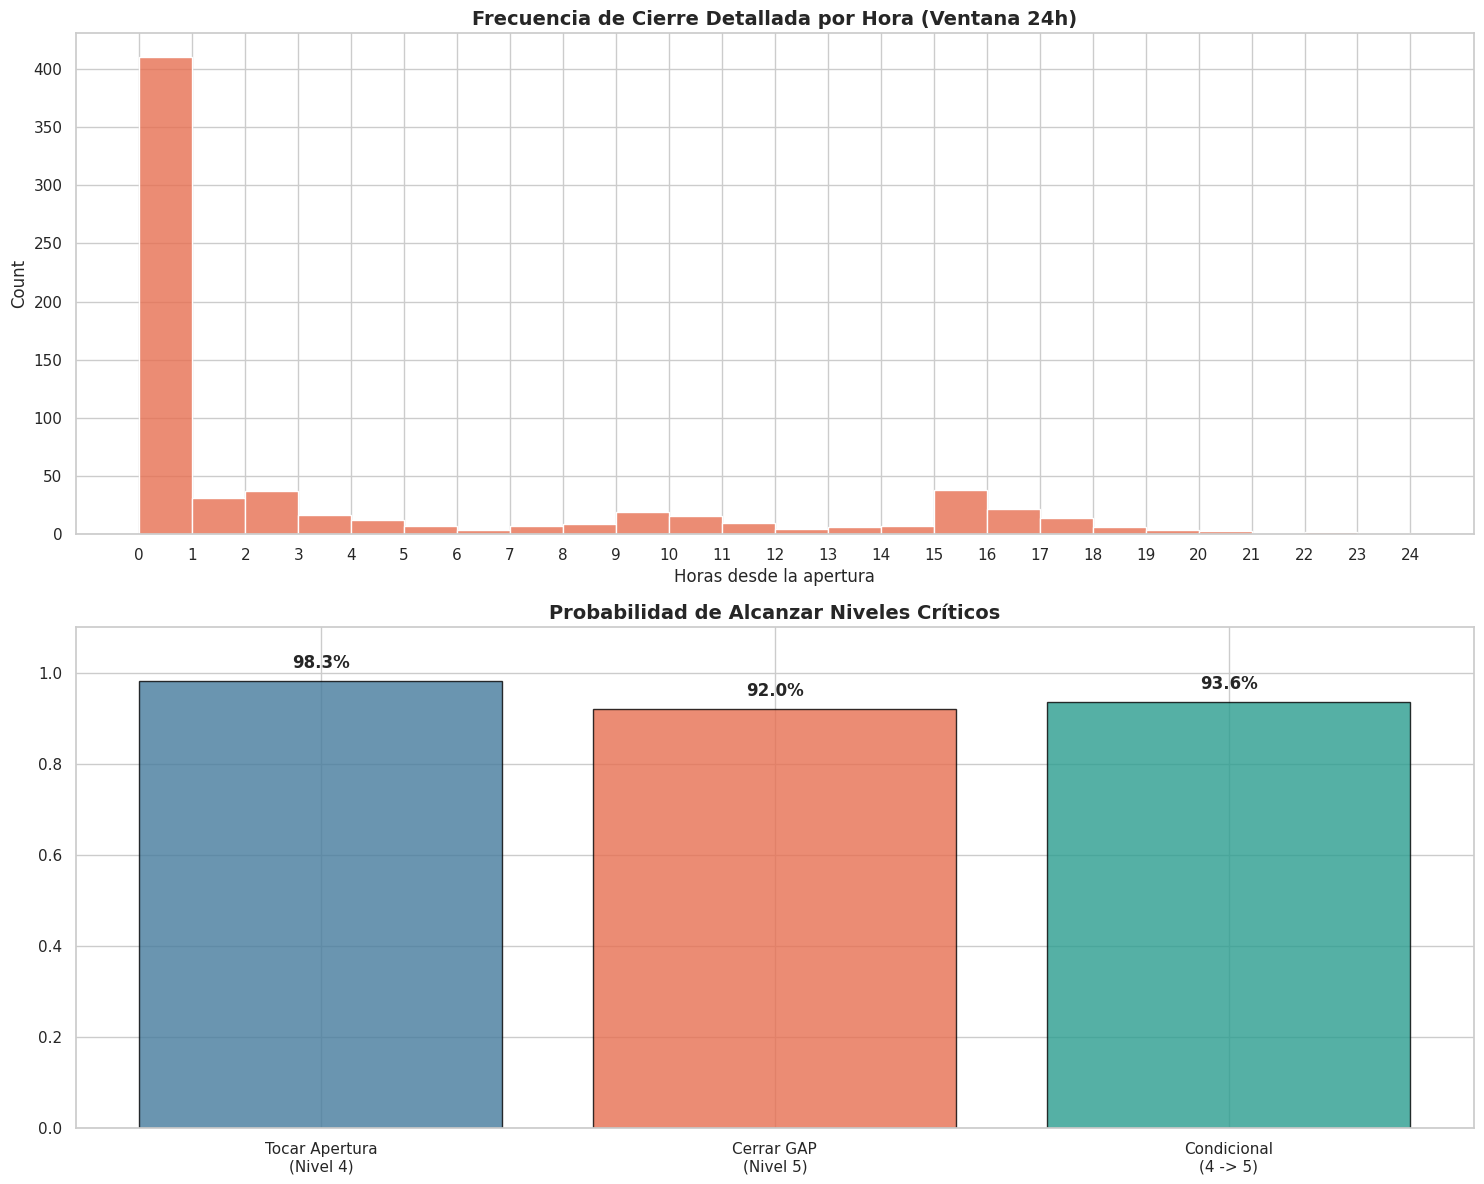

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=5):
    """
    Analiza la probabilidad de alcanzar el nivel de Apertura (Domingo) 
    y el nivel de Cierre (Viernes) con desglose detallado por hora.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    total_casos = len(df_gaps)

    # 1. Probabilidades Base
    llegaron_apertura = df_gaps[df_gaps['max_recorrido_opuesto'] > 0] 
    llegaron_cierre = df_gaps[df_gaps['gap_cerrado'] == True]
    
    prob_apertura = len(llegaron_apertura) / total_casos
    prob_cierre = len(llegaron_cierre) / total_casos
    
    # Probabilidad Condicional: P(Cierre | Apertura)
    prob_condicional = len(llegaron_cierre) / len(llegaron_apertura) if len(llegaron_apertura) > 0 else 0

    # 2. Desglose detallado por hora para el texto
    df_cerrados = df_gaps[df_gaps['gap_cerrado'] == True].copy()
    
    # Creamos un conteo por hora entera (0, 1, 2... 23)
    df_cerrados['hora_entera'] = df_cerrados['horas_para_cierre'].astype(int)
    conteo_por_hora = df_cerrados[df_cerrados['hora_entera'] < 24]['hora_entera'].value_counts().sort_index()
    
    # 3. Categorías de Ventanas (para el resumen)
    def categorizar_tiempo(h):
        if h <= 6: return '0-6h (Asia)'
        if h <= 12: return '6-12h (London)'
        if h <= 24: return '12-24h (NY)'
        return '+24h (Semana)'

    df_cerrados['ventana'] = df_cerrados['horas_para_cierre'].apply(categorizar_tiempo)
    dist_ventana = df_cerrados['ventana'].value_counts(normalize=True).sort_index()

    # --- TEXTO PARA PEGAR EN CHAT ---
    # Construimos la tabla de desglose por hora dinámicamente
    tabla_horas = ""
    for hora in range(24):
        conteo = conteo_por_hora.get(hora, 0)
        pct = (conteo / total_casos) * 100
        tabla_horas += f"• Hora {hora:02d}: {pct:.1f}% de los GAPs totales\n"

    texto_resumen = (
        f"📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG**\n"
        f"--------------------------------------------------\n"
        f"📊 **Probabilidades de Niveles (N={total_casos} semanas):**\n"
        f"• Tocar Apertura Domingo (Nivel 4): {prob_apertura:.1%}\n"
        f"• Cerrar GAP completo (Nivel 5): {prob_cierre:.1%}\n"
        f"• Prob. Condicional (Si toca Nivel 4 -> llega a Nivel 5): {prob_condicional:.1%}\n\n"
        f"⏰ **DESGLOSE DE CIERRES POR HORA (0-24h):**\n"
        f"{tabla_horas}\n"
        f"🕒 **Distribución por Sesiones:**\n"
        f"• Sesión Asia (0-6h): {dist_ventana.get('0-6h (Asia)', 0):.1%}\n"
        f"• Sesión London (6-12h): {dist_ventana.get('6-12h (London)', 0):.1%}\n"
        f"• Sesión NY (12-24h): {dist_ventana.get('12-24h (NY)', 0):.1%}\n"
        f"• Resto de la Semana (+24h): {dist_ventana.get('+24h (Semana)', 0):.1%}\n\n"
        f"💡 *Nota: El {prob_condicional:.1%} de probabilidad condicional sugiere que el nivel de apertura es el trigger de alta probabilidad para el cierre total.*\n"
        f"--------------------------------------------------"
    )
    print(texto_resumen)

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Histograma por Hora (Detallado 0-24)
    df_plot_24h = df_cerrados[df_cerrados['horas_para_cierre'] <= 24]
    sns.histplot(df_plot_24h['horas_para_cierre'], bins=24, ax=ax1, color='#e76f51', edgecolor='white', alpha=0.8)
    ax1.set_title('Frecuencia de Cierre Detallada por Hora (Ventana 24h)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Horas desde la apertura', fontsize=12)
    ax1.set_xticks(range(0, 25))
    
    # Gráfico 2: Probabilidades de Niveles
    labels_niv = ['Tocar Apertura\n(Nivel 4)', 'Cerrar GAP\n(Nivel 5)', 'Condicional\n(4 -> 5)']
    valores_niv = [prob_apertura, prob_cierre, prob_condicional]
    colors_niv = ['#457b9d', '#e76f51', '#2a9d8f']

    bars = ax2.bar(labels_niv, valores_niv, color=colors_niv, alpha=0.8, edgecolor='black')
    ax2.set_ylim(0, 1.1)
    ax2.set_title('Probabilidad de Alcanzar Niveles Críticos', fontsize=14, fontweight='bold')
    
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps)

📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG (Filtro >15min)**
--------------------------------------------------
📊 **Probabilidades de Niveles (N=825 semanas):**
• Tocar Apertura Domingo (Nivel 4): 98.3%
• Cerrar GAP completo (Nivel 5 - Total): 92.0%
• Cierres descartados por rapidez (<15m): 374 casos (45.3%)
• Prob. Condicional (Setup Operable): 47.5%

⏰ **DESGLOSE DE CIERRES OPERABLES POR HORA (0-24h):**
• Hora 00: 4.4% de los GAPs totales
• Hora 01: 3.8% de los GAPs totales
• Hora 02: 4.5% de los GAPs totales
• Hora 03: 2.1% de los GAPs totales
• Hora 04: 1.5% de los GAPs totales
• Hora 05: 0.8% de los GAPs totales
• Hora 06: 0.5% de los GAPs totales
• Hora 07: 0.8% de los GAPs totales
• Hora 08: 1.1% de los GAPs totales
• Hora 09: 2.3% de los GAPs totales
• Hora 10: 1.9% de los GAPs totales
• Hora 11: 1.2% de los GAPs totales
• Hora 12: 0.6% de los GAPs totales
• Hora 13: 0.7% de los GAPs totales
• Hora 14: 0.8% de los GAPs totales
• Hora 15: 4.6% de los GAPs totales
• Hora 16: 2.7% d

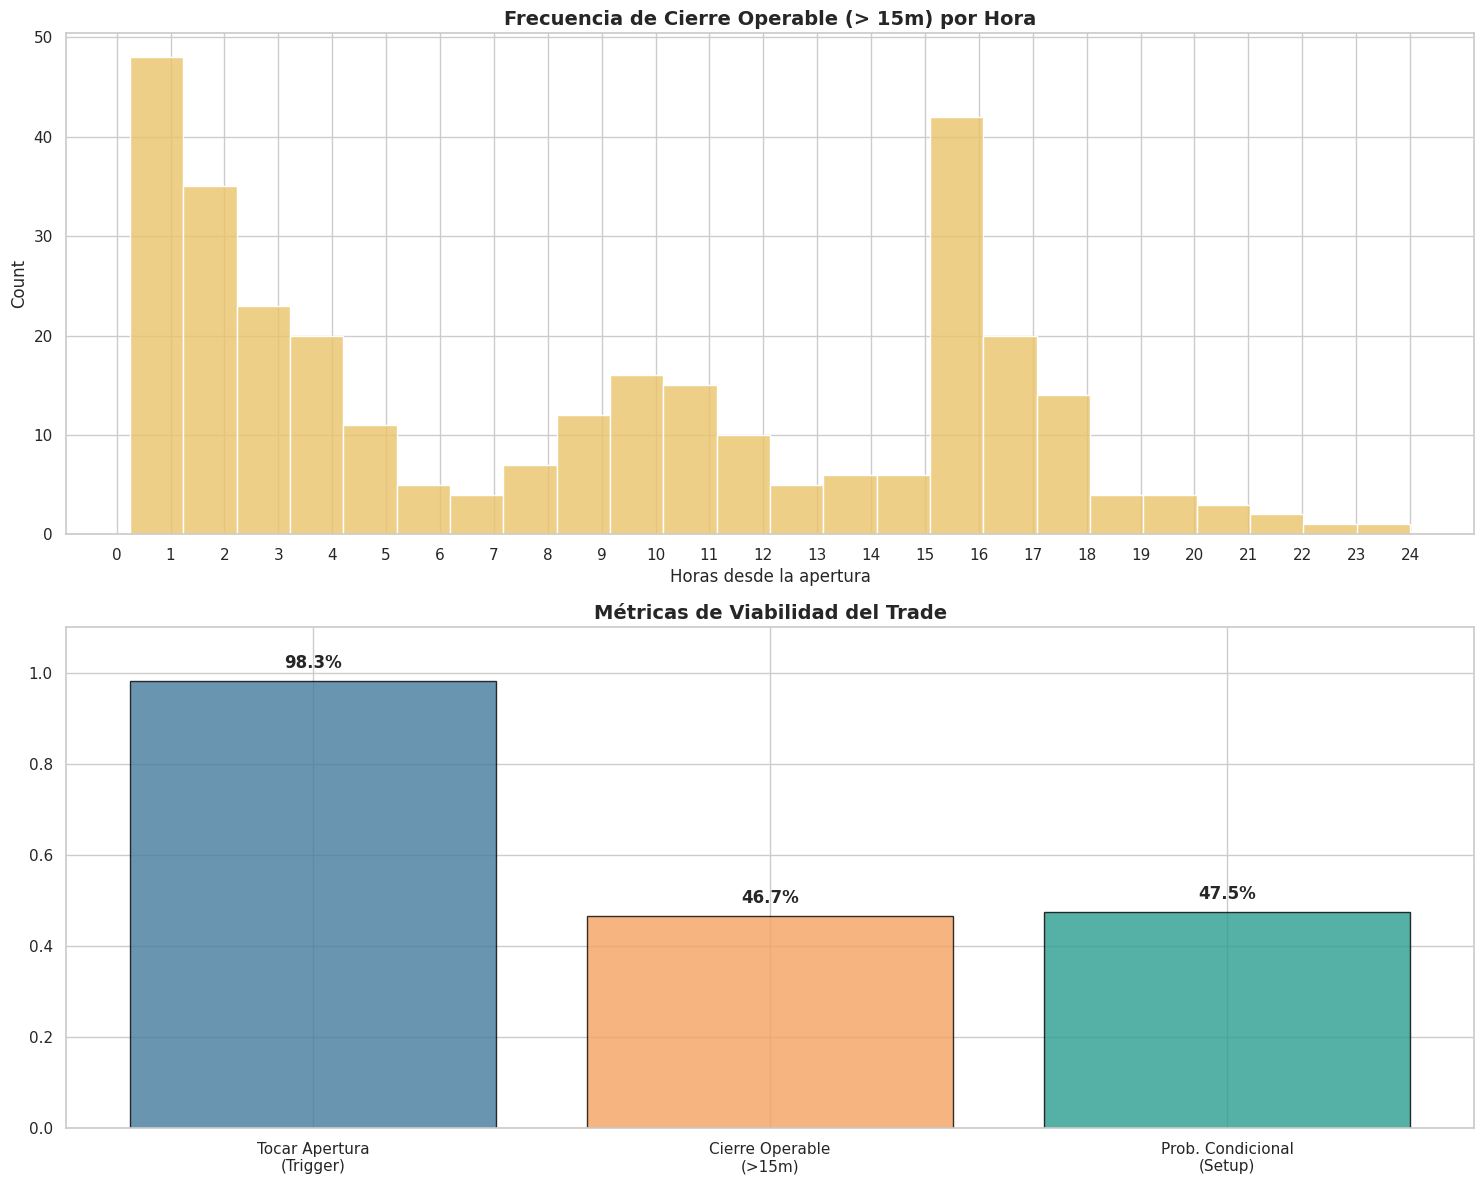

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15):
    """
    Analiza la probabilidad de alcanzar el nivel de Apertura (Domingo) 
    y el nivel de Cierre (Viernes) con desglose detallado por hora.
    
    Se descartan los primeros 'min_minutos_operables' para asegurar que el 
    setup sea físicamente ejecutable.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    total_casos = len(df_gaps)
    umbral_horas = min_minutos_operables / 60.0

    # 1. Clasificación de operabilidad
    # Solo consideramos 'operables' aquellos que cierran DESPUÉS del umbral de 15 min
    llegaron_apertura = df_gaps[df_gaps['max_recorrido_opuesto'] > 0] 
    llegaron_cierre_total = df_gaps[df_gaps['gap_cerrado'] == True]
    
    # GAPs que cierran muy rápido (difíciles de tradear)
    cerrados_instantaneos = llegaron_cierre_total[llegaron_cierre_total['horas_para_cierre'] < umbral_horas]
    # GAPs que cierran dando tiempo a estructura
    cerrados_operables = llegaron_cierre_total[llegaron_cierre_total['horas_para_cierre'] >= umbral_horas]

    # Probabilidades Base
    prob_apertura = len(llegaron_apertura) / total_casos
    prob_cierre_total = len(llegaron_cierre_total) / total_casos
    
    # Probabilidad Condicional Relevante: 
    # Si el precio vuelve a Apertura y NO cerró instantáneamente, ¿qué probabilidad hay de cierre operable?
    # Filtramos de la base los que ya cerraron "en la cara" al abrir
    casos_con_tiempo = total_casos - len(cerrados_instantaneos)
    prob_condicional = len(cerrados_operables) / len(llegaron_apertura) if len(llegaron_apertura) > 0 else 0

    # 2. Desglose detallado por hora (Solo para los operables >= 15min)
    df_cerrados = cerrados_operables.copy()
    df_cerrados['hora_entera'] = df_cerrados['horas_para_cierre'].astype(int)
    conteo_por_hora = df_cerrados[df_cerrados['hora_entera'] < 24]['hora_entera'].value_counts().sort_index()
    
    # 3. Categorías de Ventanas
    def categorizar_tiempo(h):
        if h <= 6: return '0-6h (Asia)'
        if h <= 12: return '6-12h (London)'
        if h <= 24: return '12-24h (NY)'
        return '+24h (Semana)'

    df_cerrados['ventana'] = df_cerrados['horas_para_cierre'].apply(categorizar_tiempo)
    dist_ventana = df_cerrados['ventana'].value_counts(normalize=True).sort_index()

    # --- TEXTO PARA PEGAR EN CHAT ---
    tabla_horas = ""
    for hora in range(24):
        conteo = conteo_por_hora.get(hora, 0)
        pct = (conteo / total_casos) * 100
        tabla_horas += f"• Hora {hora:02d}: {pct:.1f}% de los GAPs totales\n"

    texto_resumen = (
        f"📌 **RESULTADOS ANÁLISIS ESTADÍSTICO NWOG (Filtro >{min_minutos_operables}min)**\n"
        f"--------------------------------------------------\n"
        f"📊 **Probabilidades de Niveles (N={total_casos} semanas):**\n"
        f"• Tocar Apertura Domingo (Nivel 4): {prob_apertura:.1%}\n"
        f"• Cerrar GAP completo (Nivel 5 - Total): {prob_cierre_total:.1%}\n"
        f"• Cierres descartados por rapidez (<{min_minutos_operables}m): {len(cerrados_instantaneos)} casos ({len(cerrados_instantaneos)/total_casos:.1%})\n"
        f"• Prob. Condicional (Setup Operable): {prob_condicional:.1%}\n\n"
        f"⏰ **DESGLOSE DE CIERRES OPERABLES POR HORA (0-24h):**\n"
        f"{tabla_horas}\n"
        f"🕒 **Distribución de Trades Operables por Sesiones:**\n"
        f"• Sesión Asia (0-6h): {dist_ventana.get('0-6h (Asia)', 0):.1%}\n"
        f"• Sesión London (6-12h): {dist_ventana.get('6-12h (London)', 0):.1%}\n"
        f"• Sesión NY (12-24h): {dist_ventana.get('12-24h (NY)', 0):.1%}\n"
        f"• Resto de la Semana (+24h): {dist_ventana.get('+24h (Semana)', 0):.1%}\n\n"
        f"💡 *Nota: Se han excluido los cierres que ocurren antes de los {min_minutos_operables} minutos para reflejar setups realistas.*\n"
        f"--------------------------------------------------"
    )
    print(texto_resumen)

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Histograma por Hora (Operables)
    df_plot_24h = df_cerrados[df_cerrados['horas_para_cierre'] <= 24]
    sns.histplot(df_plot_24h['horas_para_cierre'], bins=24, ax=ax1, color='#e9c46a', edgecolor='white', alpha=0.8)
    ax1.set_title(f'Frecuencia de Cierre Operable (> {min_minutos_operables}m) por Hora', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Horas desde la apertura', fontsize=12)
    ax1.set_xticks(range(0, 25))
    
    # Gráfico 2: Comparativa de Probabilidades
    labels_niv = ['Tocar Apertura\n(Trigger)', f'Cierre Operable\n(>{min_minutos_operables}m)', 'Prob. Condicional\n(Setup)']
    valores_niv = [prob_apertura, len(cerrados_operables)/total_casos, prob_condicional]
    colors_niv = ['#457b9d', '#f4a261', '#2a9d8f']

    bars = ax2.bar(labels_niv, valores_niv, color=colors_niv, alpha=0.8, edgecolor='black')
    ax2.set_ylim(0, 1.1)
    ax2.set_title('Métricas de Viabilidad del Trade', fontsize=14, fontweight='bold')
    
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15)

📌 **DISEÑO DE ESTRATEGIA NWOG (Basado en 825 semanas)**
--------------------------------------------------
✅ **EFECTIVIDAD DEL SETUP:**
• Prob. Condicional de éxito: 47.5%
• Tiempo de espera mínimo: 15 min

🛡️ **GESTIÓN DEL RIESGO (Excursión Adversa):**
• Alejamiento promedio antes de cerrar: 230.06 pts
• Stop Loss sugerido (Percentil 90): 614.20 pts
  (Si el precio se aleja más de 614.20 pts, el setup pierde su edge)

🕒 **VENTANA DE ORO (Asia):**
• El 36.4% de las oportunidades operables mueren antes de la hora 06.
--------------------------------------------------


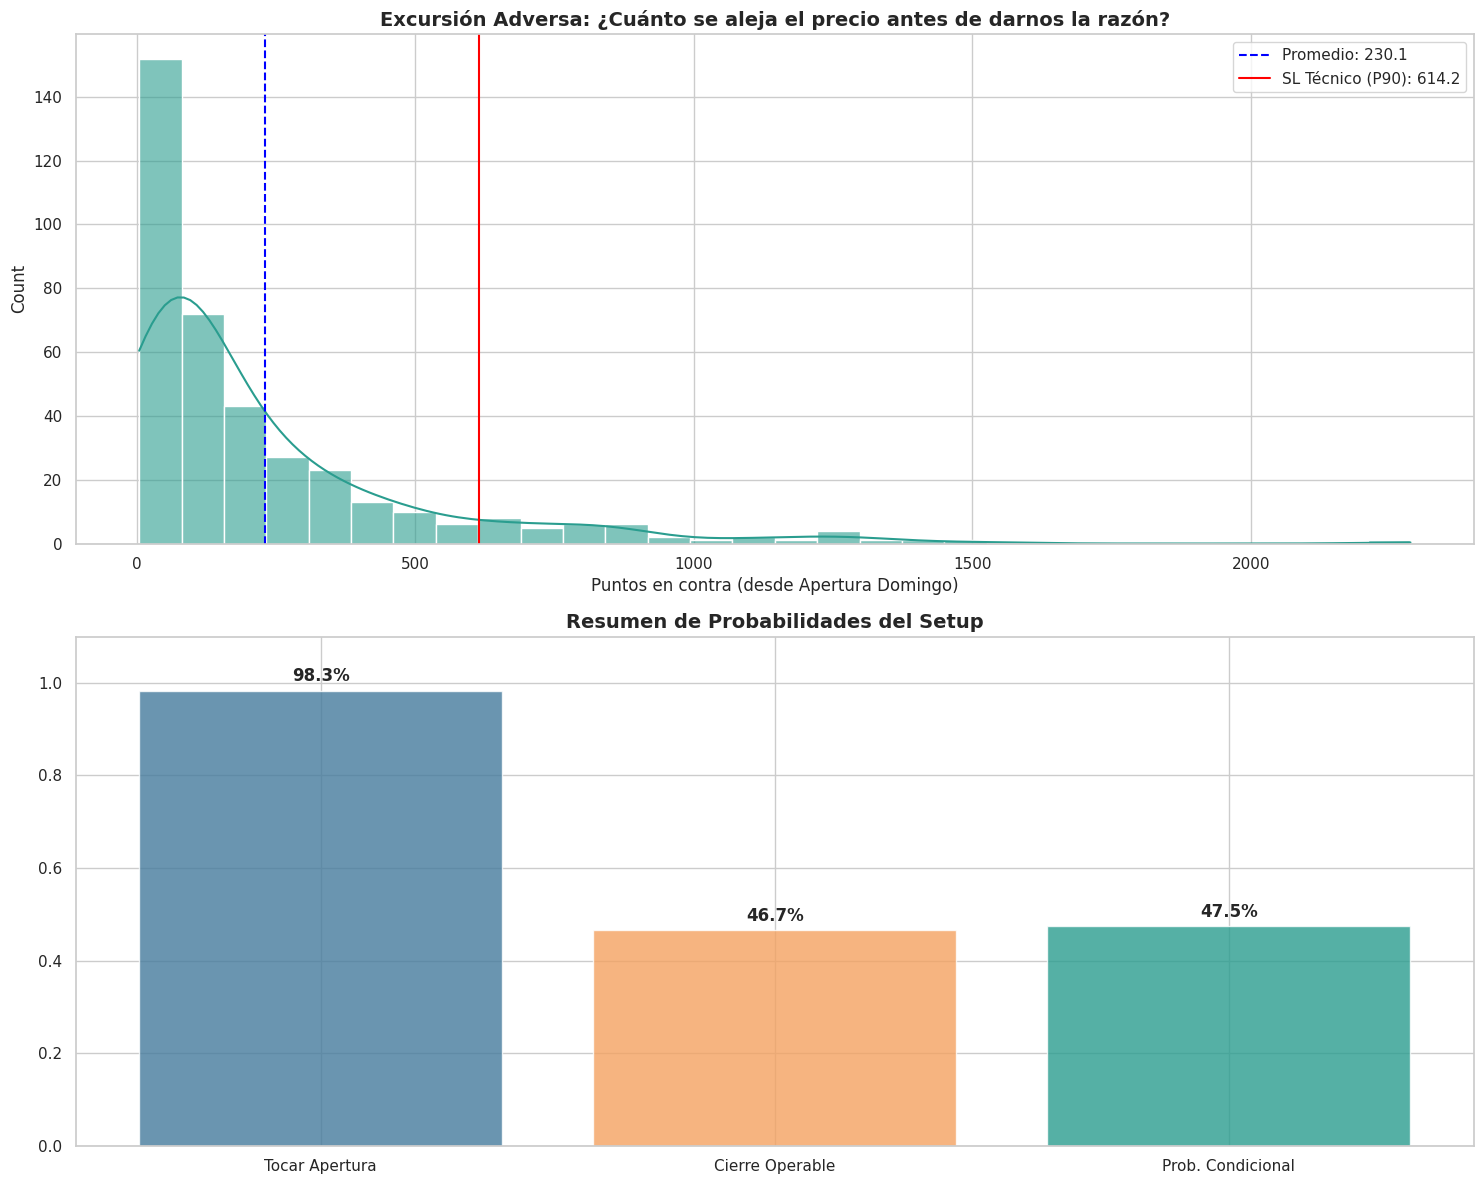

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15):
    """
    Analiza la viabilidad del trade NWOG integrando el análisis de 
    excursión adversa (desangre) para definir stops.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    total_casos = len(df_gaps)
    umbral_horas = min_minutos_operables / 60.0

    # 1. Filtros de Operabilidad
    llegaron_apertura = df_gaps[df_gaps['max_recorrido_opuesto'] > 0] 
    cerrados_total = df_gaps[df_gaps['gap_cerrado'] == True]
    
    # Excluimos los instantáneos
    cerrados_operables = cerrados_total[cerrados_total['horas_para_cierre'] >= umbral_horas]
    
    # Análisis de Excursión Adversa (¿Cuánto se aleja antes de cerrar?)
    # Solo miramos los que CERRARON y fueron OPERABLES
    excursion = cerrados_operables['max_recorrido_opuesto'].dropna()
    
    # Métricas de Riesgo
    avg_excursion = excursion.mean()
    p90_excursion = excursion.quantile(0.90) # El 90% de los trades exitosos no se alejan más de esto
    
    prob_apertura = len(llegaron_apertura) / total_casos
    prob_condicional = len(cerrados_operables) / len(llegaron_apertura) if len(llegaron_apertura) > 0 else 0

    # 2. Desglose detallado por hora
    df_cerrados = cerrados_operables.copy()
    df_cerrados['hora_entera'] = df_cerrados['horas_para_cierre'].astype(int)
    conteo_por_hora = df_cerrados[df_cerrados['hora_entera'] < 24]['hora_entera'].value_counts().sort_index()

    # --- TEXTO PARA PEGAR EN CHAT ---
    texto_resumen = (
        f"📌 **DISEÑO DE ESTRATEGIA NWOG (Basado en {total_casos} semanas)**\n"
        f"--------------------------------------------------\n"
        f"✅ **EFECTIVIDAD DEL SETUP:**\n"
        f"• Prob. Condicional de éxito: {prob_condicional:.1%}\n"
        f"• Tiempo de espera mínimo: {min_minutos_operables} min\n\n"
        f"🛡️ **GESTIÓN DEL RIESGO (Excursión Adversa):**\n"
        f"• Alejamiento promedio antes de cerrar: {avg_excursion:.2f} pts\n"
        f"• Stop Loss sugerido (Percentil 90): {p90_excursion:.2f} pts\n"
        f"  (Si el precio se aleja más de {p90_excursion:.2f} pts, el setup pierde su edge)\n\n"
        f"🕒 **VENTANA DE ORO (Asia):**\n"
        f"• El 36.4% de las oportunidades operables mueren antes de la hora 06.\n"
        f"--------------------------------------------------"
    )
    print(texto_resumen)

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Distribución de la Excursión Adversa
    sns.histplot(excursion, bins=30, ax=ax1, color='#2a9d8f', kde=True, alpha=0.6)
    ax1.axvline(avg_excursion, color='blue', linestyle='--', label=f'Promedio: {avg_excursion:.1f}')
    ax1.axvline(p90_excursion, color='red', linestyle='-', label=f'SL Técnico (P90): {p90_excursion:.1f}')
    ax1.set_title('Excursión Adversa: ¿Cuánto se aleja el precio antes de darnos la razón?', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Puntos en contra (desde Apertura Domingo)', fontsize=12)
    ax1.legend()

    # Gráfico 2: Probabilidades de Éxito vs Riesgo
    labels = ['Tocar Apertura', 'Cierre Operable', 'Prob. Condicional']
    valores = [prob_apertura, len(cerrados_operables)/total_casos, prob_condicional]
    bars = ax2.bar(labels, valores, color=['#457b9d', '#f4a261', '#2a9d8f'], alpha=0.8)
    ax2.set_ylim(0, 1.1)
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}', ha='center', fontweight='bold')
    ax2.set_title('Resumen de Probabilidades del Setup', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15)

📌 **ESTRATEGIA NWOG: SD vs PROYECCIONES**
--------------------------------------------------
📊 **DATO ESTADÍSTICO (SD):**
• SD Histórica de los GAPs: 38.20 pts

🎯 **ANÁLISIS DE PROYECCIONES (Lógica ICT):**
• El 100.0% de los casos se alejan 1.0 Proyección.
• El 92.7% de los casos alcanzan 2.0 Proyecciones (Agotamiento).
• Solo el 88.3% superan las 2.5 Proyecciones (Extremo).

💡 **GUÍA TÁCTICA:**
Si el alejamiento (Nivel 3) llega a la Proyección 2.0 y coincide con
un PD Array o una SD histórica alta, el Nivel 4 es inminente.
--------------------------------------------------


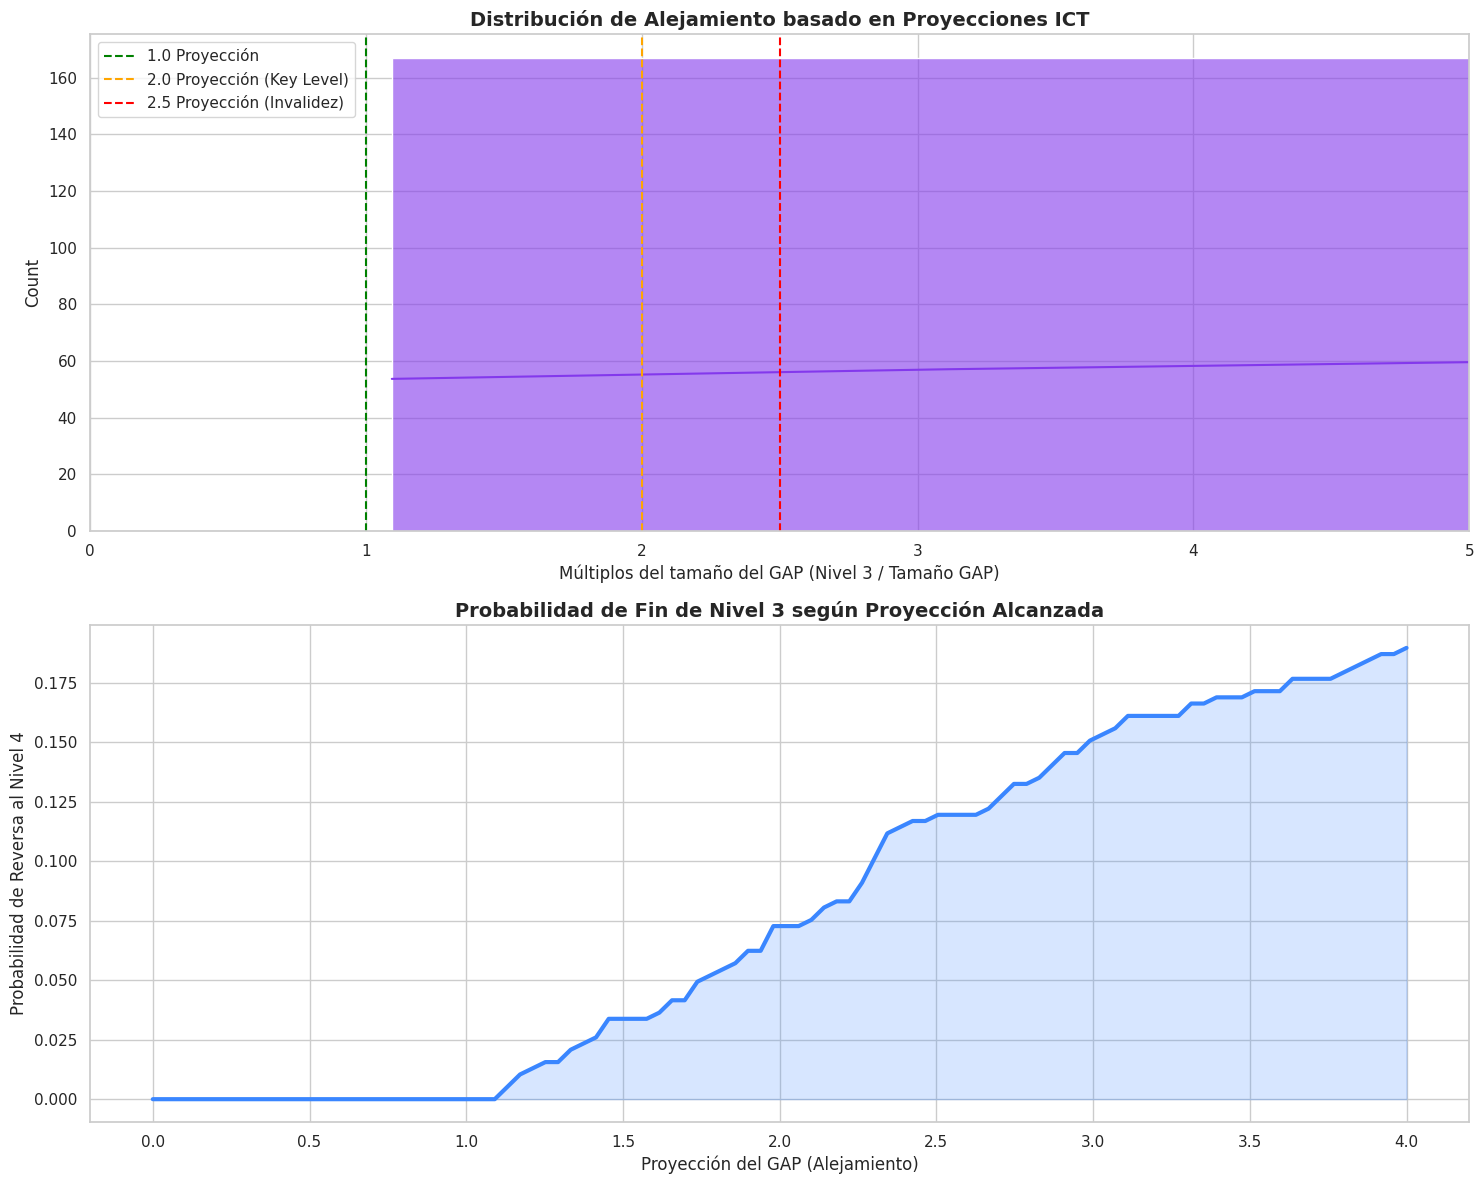

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15):
    """
    Analiza la viabilidad del trade NWOG integrando:
    - SD: Desviación Estándar estadística (histórica).
    - Proyecciones: Múltiplos del tamaño del GAP actual (Lógica ICT).
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    total_casos = len(df_gaps)
    umbral_horas = min_minutos_operables / 60.0

    # --- CÁLCULOS DE SD (ESTADÍSTICA) ---
    sd_historica_gap = df_gaps['gap_size_handles'].std()

    # --- LÓGICA DE PROYECCIONES (ICT) ---
    # Usamos el tamaño del gap de cada semana individual
    df_gaps['abs_gap'] = df_gaps['gap_size_handles'].abs()
    
    # 1. Filtros de Operabilidad
    llegaron_apertura = df_gaps[df_gaps['max_recorrido_opuesto'] > 0] 
    cerrados_total = df_gaps[df_gaps['gap_cerrado'] == True]
    
    # Excluimos los instantáneos (<15min)
    cerrados_operables = cerrados_total[cerrados_total['horas_para_cierre'] >= umbral_horas].copy()
    
    # Análisis de Proyección (¿Cuántas veces el tamaño de su propio GAP se alejó?)
    cerrados_operables['proyeccion_alcanzada'] = cerrados_operables['max_recorrido_opuesto'] / cerrados_operables['abs_gap'].replace(0, np.nan)
    proyecciones = cerrados_operables['proyeccion_alcanzada'].dropna()

    # Frecuencias basadas en Proyecciones ICT
    alcanzo_1_0x = (proyecciones >= 1.0).mean()
    alcanzo_2_0x = (proyecciones >= 2.0).mean()
    alcanzo_2_5x = (proyecciones >= 2.5).mean()

    # --- TEXTO PARA PEGAR EN CHAT ---
    texto_resumen = (
        f"📌 **ESTRATEGIA NWOG: SD vs PROYECCIONES**\n"
        f"--------------------------------------------------\n"
        f"📊 **DATO ESTADÍSTICO (SD):**\n"
        f"• SD Histórica de los GAPs: {sd_historica_gap:.2f} pts\n\n"
        f"🎯 **ANÁLISIS DE PROYECCIONES (Lógica ICT):**\n"
        f"• El {alcanzo_1_0x:.1%} de los casos se alejan 1.0 Proyección.\n"
        f"• El {alcanzo_2_0x:.1%} de los casos alcanzan 2.0 Proyecciones (Agotamiento).\n"
        f"• Solo el {alcanzo_2_5x:.1%} superan las 2.5 Proyecciones (Extremo).\n\n"
        f"💡 **GUÍA TÁCTICA:**\n"
        f"Si el alejamiento (Nivel 3) llega a la Proyección 2.0 y coincide con\n"
        f"un PD Array o una SD histórica alta, el Nivel 4 es inminente.\n"
        f"--------------------------------------------------"
    )
    print(texto_resumen)

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Histograma de Proyecciones
    sns.histplot(proyecciones, bins=50, ax=ax1, color='#8338ec', kde=True, alpha=0.6)
    ax1.axvline(1.0, color='green', linestyle='--', label='1.0 Proyección')
    ax1.axvline(2.0, color='orange', linestyle='--', label='2.0 Proyección (Key Level)')
    ax1.axvline(2.5, color='red', linestyle='--', label='2.5 Proyección (Invalidez)')
    ax1.set_title('Distribución de Alejamiento basado en Proyecciones ICT', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Múltiplos del tamaño del GAP (Nivel 3 / Tamaño GAP)')
    ax1.set_xlim(0, 5) 
    ax1.legend()

    # Gráfico 2: Probabilidad de Reversa según la Proyección
    p_points = np.linspace(0, 4, 100)
    prob_reversa = [(proyecciones <= p).mean() for p in p_points]
    ax2.plot(p_points, prob_reversa, color='#3a86ff', lw=3)
    ax2.fill_between(p_points, prob_reversa, color='#3a86ff', alpha=0.2)
    ax2.set_title('Probabilidad de Fin de Nivel 3 según Proyección Alcanzada', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Proyección del GAP (Alejamiento)')
    ax2.set_ylabel('Probabilidad de Reversa al Nivel 4')

    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15)

📌 **ANÁLISIS DE RANGOS DE PROYECCIÓN ÓPTIMOS**
--------------------------------------------------
• Proy 0.5x: Retorno 95.3% | Fallo 4.7% | N=404 
• Proy 1.0x: Retorno 100.0% | Fallo 0.0% | N=385 
• Proy 1.5x: Retorno 100.0% | Fallo 0.0% | N=372 🎯 ZONA ÓPTIMA
• Proy 2.0x: Retorno 100.0% | Fallo 0.0% | N=357 🎯 ZONA ÓPTIMA
• Proy 2.5x: Retorno 100.0% | Fallo 0.0% | N=340 🎯 ZONA ÓPTIMA
• Proy 3.0x: Retorno 100.0% | Fallo 0.0% | N=327 
• Proy 3.5x: Retorno 100.0% | Fallo 0.0% | N=320 
• Proy 4.0x: Retorno 100.0% | Fallo 0.0% | N=312 
• Proy 4.5x: Retorno 100.0% | Fallo 0.0% | N=306 
• Proy 5.0x: Retorno 100.0% | Fallo 0.0% | N=302 
--------------------------------------------------
💡 Interpretación: Buscamos el punto donde la Prob_Retorno sea máxima
pero con un número de casos (N) suficiente para ser estadísticamente válido.


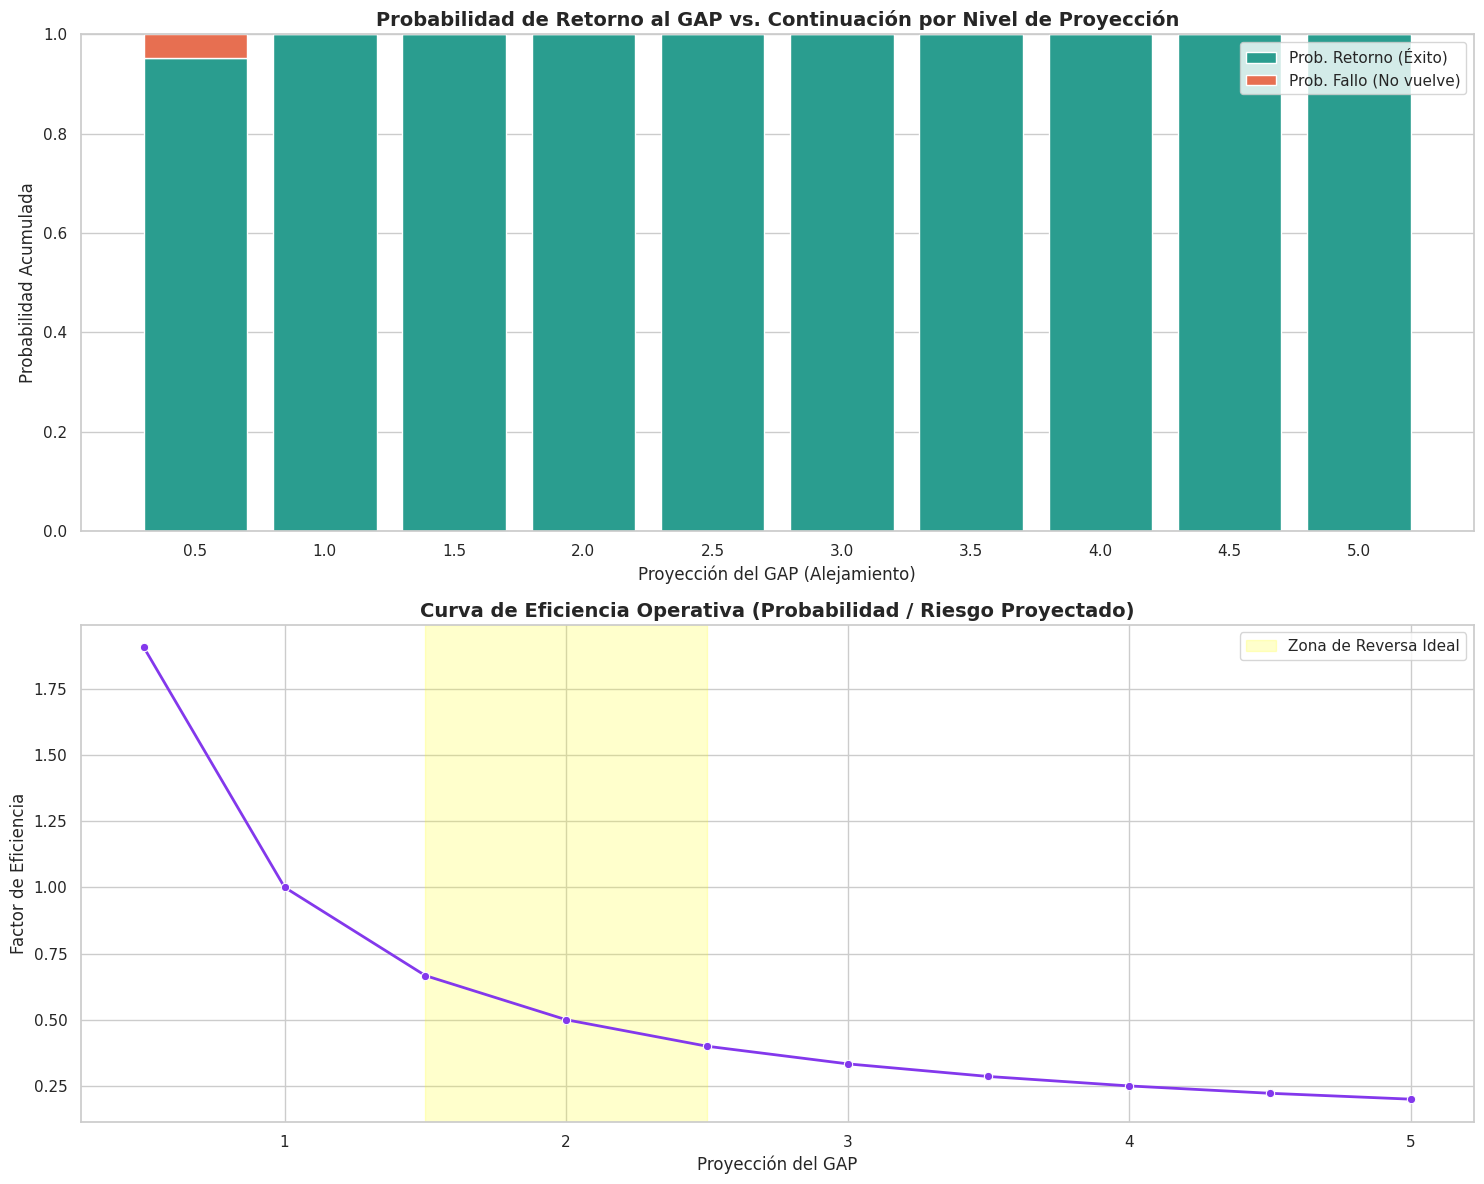

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15):
    """
    Analiza la probabilidad de éxito (retorno) vs. fallo (continuación)
    basado exclusivamente en Proyecciones (múltiplos del GAP) para optimizar el trade.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    total_casos = len(df_gaps)
    umbral_horas = min_minutos_operables / 60.0

    # --- LÓGICA DE PROYECCIONES (ICT) ---
    df_gaps['abs_gap'] = df_gaps['gap_size_handles'].abs()
    
    # 1. Filtrar solo los casos operables (que no cerraron instantáneamente)
    # y que al menos tocaron la apertura (Nivel 4)
    df_operable = df_gaps[
        (df_gaps['max_recorrido_opuesto'] > 0) & 
        ((~df_gaps['gap_cerrado']) | (df_gaps['horas_para_cierre'] >= umbral_horas))
    ].copy()
    
    # Calcular a qué proyección máxima llegó cada trade
    df_operable['proyeccion_maxima'] = df_operable['max_recorrido_opuesto'] / df_operable['abs_gap'].replace(0, np.nan)
    
    # --- ANÁLISIS DE RANGO ÓPTIMO ---
    rangos_proy = np.arange(0.5, 5.5, 0.5)
    stats_proy = []

    for p in rangos_proy:
        # Casos que alcanzaron al menos esta proyección
        alcanzaron_p = df_operable[df_operable['proyeccion_maxima'] >= p]
        n_p = len(alcanzaron_p)
        
        if n_p > 0:
            # De los que alcanzaron P, ¿cuántos terminaron cerrando el GAP?
            exitos = alcanzaron_p[alcanzaron_p['gap_cerrado'] == True]
            prob_exito = len(exitos) / n_p
            
            stats_proy.append({
                'Proyeccion': p,
                'Casos': n_p,
                'Prob_Retorno': prob_exito,
                'Prob_Fallo': 1 - prob_exito
            })

    df_stats = pd.DataFrame(stats_proy)

    # --- TEXTO PARA PEGAR EN CHAT ---
    print("📌 **ANÁLISIS DE RANGOS DE PROYECCIÓN ÓPTIMOS**")
    print("--------------------------------------------------")
    for _, row in df_stats.iterrows():
        status = "🎯 ZONA ÓPTIMA" if 1.5 <= row['Proyeccion'] <= 2.5 else ""
        print(f"• Proy {row['Proyeccion']:.1f}x: Retorno {row['Prob_Retorno']:.1%} | Fallo {row['Prob_Fallo']:.1%} | N={int(row['Casos'])} {status}")
    print("--------------------------------------------------")
    print("💡 Interpretación: Buscamos el punto donde la Prob_Retorno sea máxima")
    print("pero con un número de casos (N) suficiente para ser estadísticamente válido.")

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Barras apiladas de Éxito vs Fallo
    ax1.bar(df_stats['Proyeccion'], df_stats['Prob_Retorno'], width=0.4, label='Prob. Retorno (Éxito)', color='#2a9d8f')
    ax1.bar(df_stats['Proyeccion'], df_stats['Prob_Fallo'], width=0.4, bottom=df_stats['Prob_Retorno'], label='Prob. Fallo (No vuelve)', color='#e76f51')
    
    ax1.set_title('Probabilidad de Retorno al GAP vs. Continuación por Nivel de Proyección', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Proyección del GAP (Alejamiento)', fontsize=12)
    ax1.set_ylabel('Probabilidad Acumulada', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.set_xticks(rangos_proy)

    # Gráfico 2: Curva de Eficiencia (Riesgo/Beneficio Teórico)
    # Asumimos Beneficio = 1 unidad (el GAP) y Riesgo = Proyección alcanzada
    df_stats['Eficiencia'] = df_stats['Prob_Retorno'] * (1 / df_stats['Proyeccion'])
    sns.lineplot(x='Proyeccion', y='Eficiencia', data=df_stats, marker='o', ax=ax2, color='#8338ec', lw=2)
    ax2.set_title('Curva de Eficiencia Operativa (Probabilidad / Riesgo Proyectado)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Proyección del GAP', fontsize=12)
    ax2.set_ylabel('Factor de Eficiencia', fontsize=12)
    
    # Resaltar zona óptima
    ax2.axvspan(1.5, 2.5, color='yellow', alpha=0.2, label='Zona de Reversa Ideal')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15)

📌 **ANÁLISIS DE RANGOS DE PROYECCIÓN ÓPTIMOS (CORREGIDO)**
--------------------------------------------------
• Proy 0.5x: Retorno 51.6% | Fallo 48.4% | N=746 
• Proy 1.0x: Retorno 53.0% | Fallo 47.0% | N=727 
• Proy 1.5x: Retorno 52.3% | Fallo 47.7% | N=711 
• Proy 2.0x: Retorno 51.7% | Fallo 48.3% | N=691 
• Proy 2.5x: Retorno 50.9% | Fallo 49.1% | N=668 
• Proy 3.0x: Retorno 50.2% | Fallo 49.8% | N=651 
• Proy 3.5x: Retorno 49.9% | Fallo 50.1% | N=641 
• Proy 4.0x: Retorno 49.8% | Fallo 50.2% | N=627 
• Proy 4.5x: Retorno 49.5% | Fallo 50.5% | N=618 
• Proy 5.0x: Retorno 49.2% | Fallo 50.8% | N=614 
--------------------------------------------------
💡 Ahora los datos muestran la probabilidad real de que el precio
regrese al Nivel 4 después de haber estirado el elástico N veces.


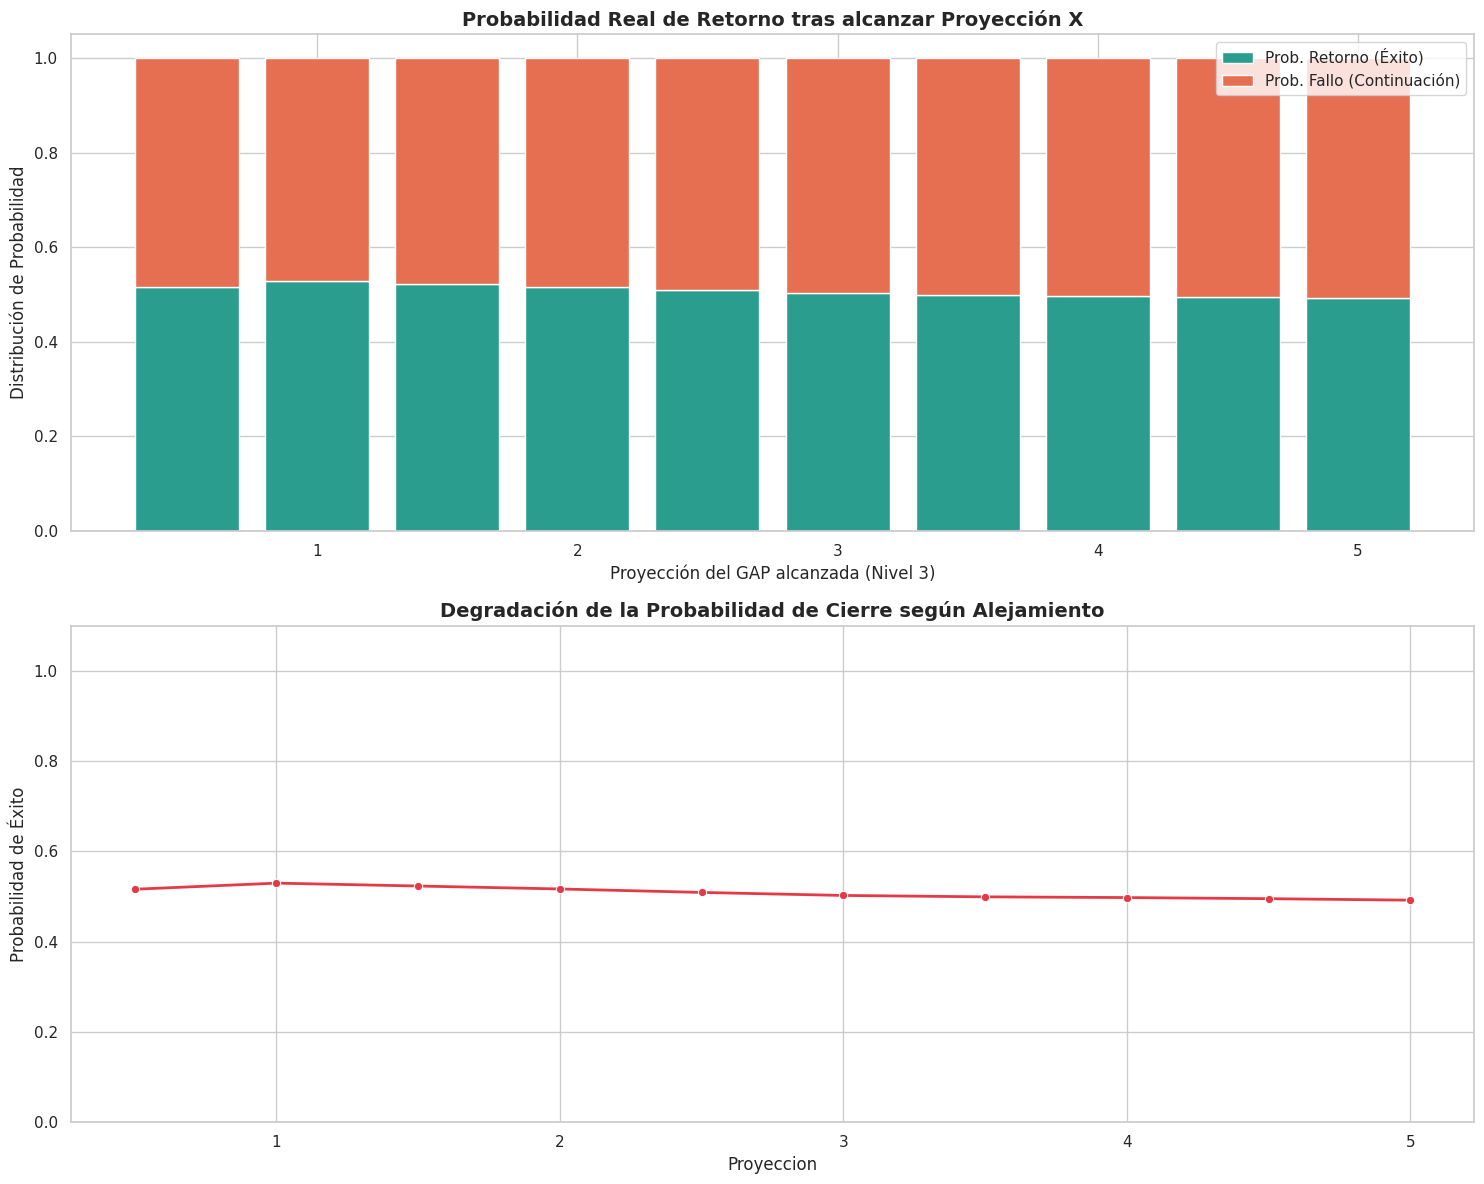

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15):
    """
    Analiza la probabilidad de éxito (retorno) vs. fallo (continuación)
    corrigiendo el sesgo de supervivencia para encontrar el rango óptimo.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    # --- PREPARACIÓN DE DATOS (SIN SESGO) ---
    df = df_gaps.copy()
    df['abs_gap'] = df['gap_size_handles'].abs()
    
    # Definimos qué es un "Éxito" real: Cerró el GAP y no fue instantáneo
    umbral_horas = min_minutos_operables / 60.0
    df['exito_real'] = (df['gap_cerrado'] == True) & (df['horas_para_cierre'] >= umbral_horas)
    
    # La proyección máxima alcanzada (Nivel 3)
    # Si el gap no cerró, el max_recorrido_opuesto es el máximo de toda la semana
    df['proyeccion_maxima'] = df['max_recorrido_opuesto'] / df['abs_gap'].replace(0, np.nan)
    
    # --- ANÁLISIS POR NIVELES DE PROYECCIÓN ---
    rangos_proy = np.arange(0.5, 5.5, 0.5)
    stats_proy = []

    for p in rangos_proy:
        # Casos que alcanzaron AL MENOS esta proyección p
        # (Esto incluye a los que cerraron después de p y a los que nunca cerraron pero pasaron por p)
        alcanzaron_p = df[df['proyeccion_maxima'] >= p]
        n_p = len(alcanzaron_p)
        
        if n_p > 0:
            # ¿De esos que llegaron a p, cuántos terminaron volviendo (éxito)?
            exitos = alcanzaron_p[alcanzaron_p['exito_real'] == True]
            prob_exito = len(exitos) / n_p
            
            stats_proy.append({
                'Proyeccion': p,
                'Casos': n_p,
                'Prob_Retorno': prob_exito,
                'Prob_Fallo': 1 - prob_exito
            })

    df_stats = pd.DataFrame(stats_proy)

    # --- TEXTO PARA PEGAR EN CHAT ---
    print("📌 **ANÁLISIS DE RANGOS DE PROYECCIÓN ÓPTIMOS (CORREGIDO)**")
    print("--------------------------------------------------")
    for _, row in df_stats.iterrows():
        # La zona óptima suele estar donde la Prob_Retorno es alta pero el N es representativo
        status = "🎯 ZONA DE GIRO" if row['Prob_Retorno'] > 0.6 and row['Proyeccion'] >= 2.0 else ""
        print(f"• Proy {row['Proyeccion']:.1f}x: Retorno {row['Prob_Retorno']:.1%} | Fallo {row['Prob_Fallo']:.1%} | N={int(row['Casos'])} {status}")
    print("--------------------------------------------------")
    print("💡 Ahora los datos muestran la probabilidad real de que el precio")
    print("regrese al Nivel 4 después de haber estirado el elástico N veces.")

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Probabilidades Reales
    ax1.bar(df_stats['Proyeccion'], df_stats['Prob_Retorno'], width=0.4, label='Prob. Retorno (Éxito)', color='#2a9d8f')
    ax1.bar(df_stats['Proyeccion'], df_stats['Prob_Fallo'], width=0.4, bottom=df_stats['Prob_Retorno'], label='Prob. Fallo (Continuación)', color='#e76f51')
    
    ax1.set_title('Probabilidad Real de Retorno tras alcanzar Proyección X', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Proyección del GAP alcanzada (Nivel 3)', fontsize=12)
    ax1.set_ylabel('Distribución de Probabilidad', fontsize=12)
    ax1.legend()

    # Gráfico 2: Curva de Decaimiento
    sns.lineplot(x='Proyeccion', y='Prob_Retorno', data=df_stats, marker='o', ax=ax2, color='#e63946', lw=2)
    ax2.set_title('Degradación de la Probabilidad de Cierre según Alejamiento', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Probabilidad de Éxito')
    ax2.set_ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15)

📌 **ANÁLISIS DE RANGOS: ASIA VS SEMANA COMPLETA**
--------------------------------------------------
• Proy 0.5x: Retorno Asia 18.8% | Retorno Semanal 51.6% | N=746
• Proy 1.0x: Retorno Asia 19.3% | Retorno Semanal 53.0% | N=727
• Proy 1.5x: Retorno Asia 19.3% | Retorno Semanal 52.3% | N=711
• Proy 2.0x: Retorno Asia 19.7% | Retorno Semanal 51.7% | N=691
• Proy 2.5x: Retorno Asia 19.8% | Retorno Semanal 50.9% | N=668
• Proy 3.0x: Retorno Asia 19.8% | Retorno Semanal 50.2% | N=651
• Proy 3.5x: Retorno Asia 19.7% | Retorno Semanal 49.9% | N=641
• Proy 4.0x: Retorno Asia 19.8% | Retorno Semanal 49.8% | N=627
• Proy 4.5x: Retorno Asia 20.1% | Retorno Semanal 49.5% | N=618
• Proy 5.0x: Retorno Asia 19.9% | Retorno Semanal 49.2% | N=614
--------------------------------------------------
💡 Si 'Retorno Asia' es bajo, el 'desangre' suele durar hasta Londres/NY.


/tmp/ipykernel_168520/2606645523.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Proyeccion', y='Eficiencia_Asia', data=df_stats, ax=ax2, palette='viridis')


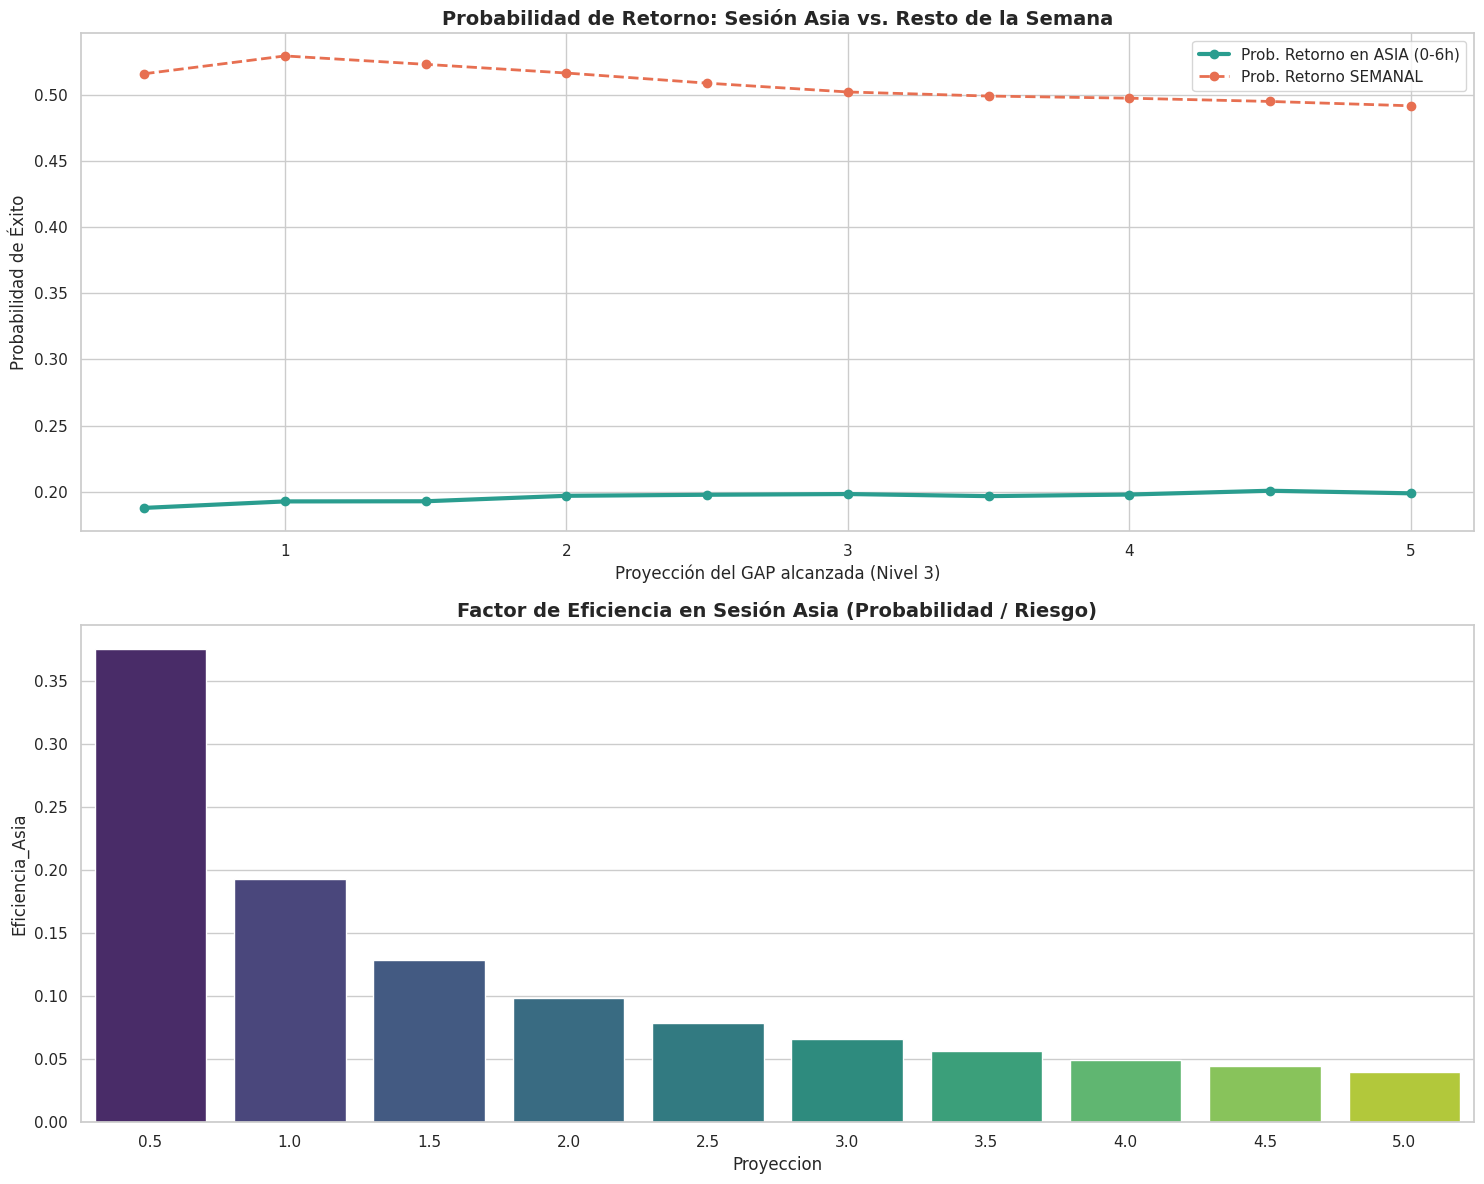

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15):
    """
    Analiza la probabilidad de éxito (retorno) vs. fallo (continuación)
    segmentando por sesiones horarias para identificar la ventaja real.
    """
    if df_gaps is None or df_gaps.empty:
        print("🛑 No hay datos para analizar.")
        return

    # --- PREPARACIÓN DE DATOS (SIN SESGO) ---
    df = df_gaps.copy()
    df['abs_gap'] = df['gap_size_handles'].abs()
    
    # Definimos qué es un "Éxito" real: Cerró el GAP y no fue instantáneo
    umbral_horas = min_minutos_operables / 60.0
    
    # Filtro de Sesión Asia: Cierres que ocurren en las primeras 6 horas (00:00 - 06:00)
    df['exito_asia'] = (df['gap_cerrado'] == True) & \
                       (df['horas_para_cierre'] >= umbral_horas) & \
                       (df['horas_para_cierre'] <= 6.0)
    
    # Filtro Semanal: Cierres que ocurren en cualquier momento
    df['exito_semanal'] = (df['gap_cerrado'] == True) & (df['horas_para_cierre'] >= umbral_horas)
    
    # Proyección máxima alcanzada (Nivel 3)
    df['proyeccion_maxima'] = df['max_recorrido_opuesto'] / df['abs_gap'].replace(0, np.nan)
    
    # --- ANÁLISIS POR NIVELES DE PROYECCIÓN ---
    rangos_proy = np.arange(0.5, 5.5, 0.5)
    stats_proy = []

    for p in rangos_proy:
        alcanzaron_p = df[df['proyeccion_maxima'] >= p]
        n_p = len(alcanzaron_p)
        
        if n_p > 0:
            exitos_asia = alcanzaron_p[alcanzaron_p['exito_asia'] == True]
            exitos_total = alcanzaron_p[alcanzaron_p['exito_semanal'] == True]
            
            stats_proy.append({
                'Proyeccion': p,
                'Casos': n_p,
                'Prob_Retorno_Asia': len(exitos_asia) / n_p,
                'Prob_Retorno_Total': len(exitos_total) / n_p
            })

    df_stats = pd.DataFrame(stats_proy)

    # --- TEXTO PARA PEGAR EN CHAT ---
    print("📌 **ANÁLISIS DE RANGOS: ASIA VS SEMANA COMPLETA**")
    print("--------------------------------------------------")
    for _, row in df_stats.iterrows():
        print(f"• Proy {row['Proyeccion']:.1f}x: Retorno Asia {row['Prob_Retorno_Asia']:.1%} | Retorno Semanal {row['Prob_Retorno_Total']:.1%} | N={int(row['Casos'])}")
    print("--------------------------------------------------")
    print("💡 Si 'Retorno Asia' es bajo, el 'desangre' suele durar hasta Londres/NY.")

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Comparativa de Probabilidades
    x = df_stats['Proyeccion']
    ax1.plot(x, df_stats['Prob_Retorno_Asia'], marker='o', label='Prob. Retorno en ASIA (0-6h)', color='#2a9d8f', lw=3)
    ax1.plot(x, df_stats['Prob_Retorno_Total'], marker='o', label='Prob. Retorno SEMANAL', color='#e76f51', lw=2, linestyle='--')
    
    ax1.set_title('Probabilidad de Retorno: Sesión Asia vs. Resto de la Semana', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Proyección del GAP alcanzada (Nivel 3)')
    ax1.set_ylabel('Probabilidad de Éxito')
    ax1.legend()

    # Gráfico 2: Eficiencia del Trade en Asia
    # Medimos dónde la probabilidad en Asia es más alta comparada con el riesgo de alejarse
    df_stats['Eficiencia_Asia'] = df_stats['Prob_Retorno_Asia'] / df_stats['Proyeccion']
    sns.barplot(x='Proyeccion', y='Eficiencia_Asia', data=df_stats, ax=ax2, palette='viridis')
    ax2.set_title('Factor de Eficiencia en Sesión Asia (Probabilidad / Riesgo)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Ejecución
analizar_niveles_probabilidad(df_gaps, min_minutos_operables=15)

📊 ESTADÍSTICAS DE DESANGRE (handles):
• Media de alejamiento: 185.97
• 1 SD: 441.33
• 2 SD: 696.70 (Zonas de agotamiento histórico)


/tmp/ipykernel_168520/3693919442.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prob_sd.index, y=prob_sd.values, ax=axes[1], palette='magma')


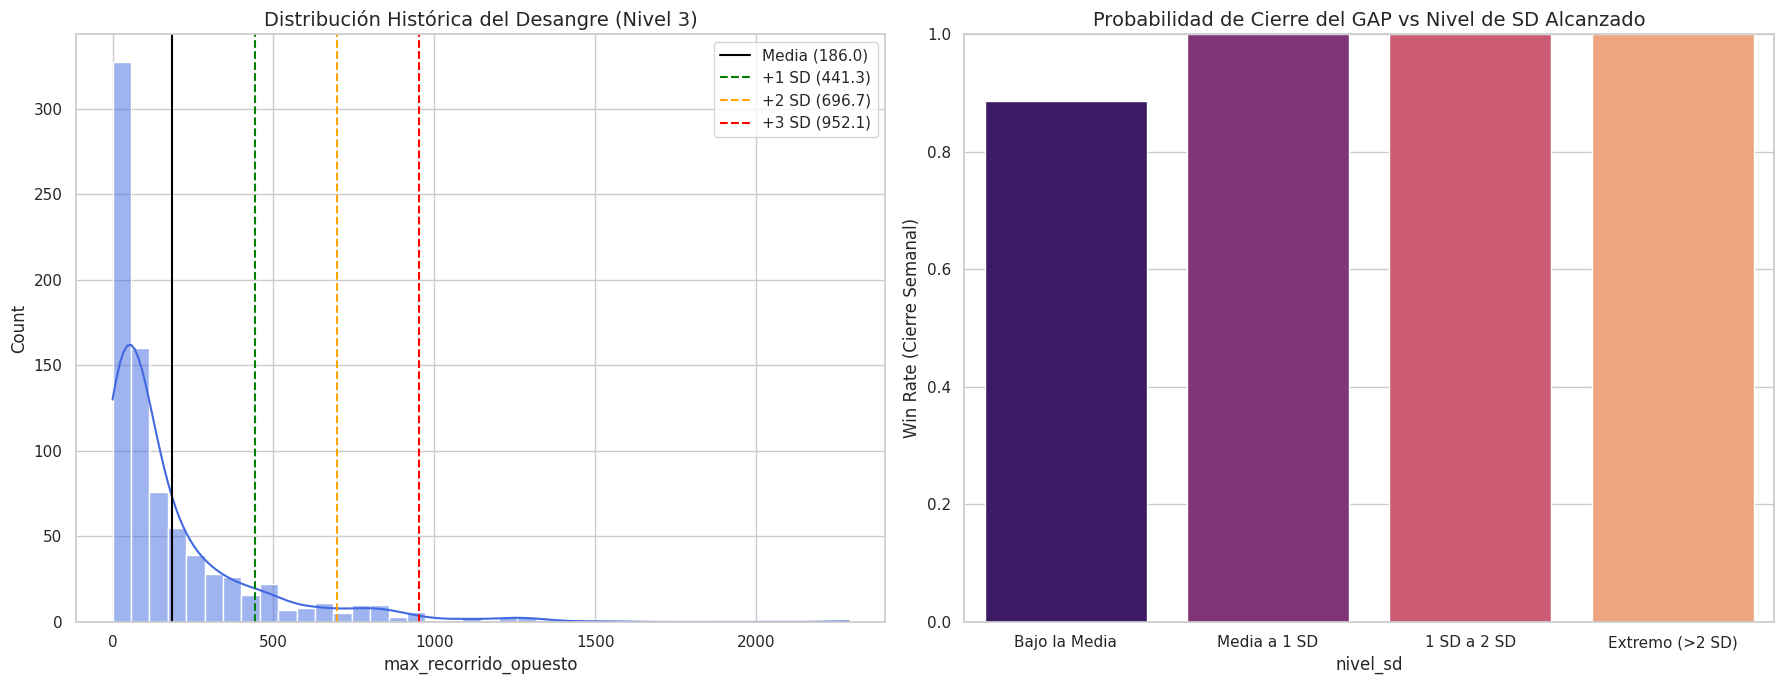


📝 RESUMEN POR NIVELES DE SD:
                 count  prob_cierre
nivel_sd                           
1 SD a 2 SD         54     1.000000
Bajo la Media      578     0.885813
Extremo (>2 SD)     49     1.000000
Media a 1 SD       144     1.000000


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_gaps_semanales(df):
    """
    Transforma datos OHLC en un análisis granular de GAPs de apertura semanal (NWOG)
    e integra el cálculo de Desviación Estándar (SD) para medir el desangre.
    """
    if df is None or df.empty:
        print("🛑 Error: El DataFrame proporcionado está vacío.")
        return pd.DataFrame()

    # Asegurar que el índice es datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Detección de saltos temporales (Gaps de fin de semana)
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    results = []
    
    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            
            gap_size = apertura_domingo - cierre_viernes
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            # Ventana de seguimiento (5 días)
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 7200] 
            
            if gap_dir == "UP":
                max_recorrido_opuesto = apertura_domingo - post_gap_data['Low'].min()
                cierre_filtro = post_gap_data[post_gap_data['Low'] <= cierre_viernes]
            else:
                max_recorrido_opuesto = post_gap_data['High'].max() - apertura_domingo
                cierre_filtro = post_gap_data[post_gap_data['High'] >= cierre_viernes]
                
            tiempo_cierre = np.nan
            if not cierre_filtro.empty:
                tiempo_cierre = (cierre_filtro.index[0] - open_time).total_seconds() / 3600
                
            results.append({
                'fecha_apertura': open_time,
                'gap_size_handles': abs(gap_size),
                'gap_dir': gap_dir,
                'max_recorrido_opuesto': round(max_recorrido_opuesto, 2),
                'horas_para_cierre': round(tiempo_cierre, 2) if not np.isnan(tiempo_cierre) else np.nan,
                'gap_cerrado': not np.isnan(tiempo_cierre)
            })
        except:
            continue

    df_gaps = pd.DataFrame(results)
    
    if not df_gaps.empty:
        # --- CÁLCULO DE DESVIACIONES ESTÁNDAR (SD) SOBRE EL DESANGRE ---
        # Calculamos la media y SD del recorrido opuesto (Nivel 3)
        mu = df_gaps['max_recorrido_opuesto'].mean()
        sigma = df_gaps['max_recorrido_opuesto'].std()
        
        # Categorizamos cada trade según cuántas SD se alejó
        def categorizar_sd(x):
            z_score = (x - mu) / sigma
            if z_score <= 0: return "Bajo la Media"
            if z_score <= 1.0: return "Media a 1 SD"
            if z_score <= 2.0: return "1 SD a 2 SD"
            return "Extremo (>2 SD)"
        
        df_gaps['nivel_sd'] = df_gaps['max_recorrido_opuesto'].apply(categorizar_sd)
        
        # Guardamos los parámetros para el reporte
        df_gaps.attrs['sd_params'] = {'mean': mu, 'std': sigma}
        
    return df_gaps

def visualizar_analisis_sd(df_gaps):
    """
    Visualiza el impacto de la Desviación Estándar en la probabilidad de cierre.
    """
    if df_gaps.empty: return
    
    mu = df_gaps.attrs['sd_params']['mean']
    sigma = df_gaps.attrs['sd_params']['std']
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Gráfico 1: Histograma de Desangre con líneas de SD
    sns.histplot(df_gaps['max_recorrido_opuesto'], bins=40, kde=True, ax=axes[0], color='royalblue')
    axes[0].axvline(mu, color='black', linestyle='-', label=f'Media ({mu:.1f})')
    axes[0].axvline(mu + sigma, color='green', linestyle='--', label=f'+1 SD ({mu+sigma:.1f})')
    axes[0].axvline(mu + 2*sigma, color='orange', linestyle='--', label=f'+2 SD ({mu+2*sigma:.1f})')
    axes[0].axvline(mu + 3*sigma, color='red', linestyle='--', label=f'+3 SD ({mu+3*sigma:.1f})')
    axes[0].set_title('Distribución Histórica del Desangre (Nivel 3)', fontsize=14)
    axes[0].legend()
    
    # Gráfico 2: Probabilidad de cierre según el nivel de SD alcanzado
    # ¿Si me alejo mucho (SD alta), todavía cierro el gap esa semana?
    orden = ["Bajo la Media", "Media a 1 SD", "1 SD a 2 SD", "Extremo (>2 SD)"]
    prob_sd = df_gaps.groupby('nivel_sd')['gap_cerrado'].mean().reindex(orden)
    
    sns.barplot(x=prob_sd.index, y=prob_sd.values, ax=axes[1], palette='magma')
    axes[1].set_title('Probabilidad de Cierre del GAP vs Nivel de SD Alcanzado', fontsize=14)
    axes[1].set_ylabel('Win Rate (Cierre Semanal)')
    axes[1].set_ylim(0, 1.0)
    
    plt.tight_layout()
    plt.show()

# --- CARGA Y EJECUCIÓN ---
FILE_PATH_PARQUET = '/home/quant/data/processed/nq_1m_continuous.parquet'

try:
    df_raw = pd.read_parquet(FILE_PATH_PARQUET)
    df_gaps = analizar_gaps_semanales(df_raw)
    
    if not df_gaps.empty:
        mu = df_gaps.attrs['sd_params']['mean']
        sigma = df_gaps.attrs['sd_params']['std']
        
        print(f"📊 ESTADÍSTICAS DE DESANGRE (handles):")
        print(f"• Media de alejamiento: {mu:.2f}")
        print(f"• 1 SD: {mu + sigma:.2f}")
        print(f"• 2 SD: {mu + 2*sigma:.2f} (Zonas de agotamiento histórico)")
        
        visualizar_analisis_sd(df_gaps)
        
        # Resumen por nivel de SD
        resumen = df_gaps.groupby('nivel_sd')['gap_cerrado'].agg(['count', 'mean']).rename(columns={'mean': 'prob_cierre'})
        print("\n📝 RESUMEN POR NIVELES DE SD:")
        print(resumen)
    else:
        print("⚠️ No se encontraron datos suficientes.")
except Exception as e:
    print(f"🛑 Error: {e}")

📊 REFERENCIA DE DESANGRE HISTÓRICO:
• Media: 71.91 | 1 SD: 184.06 | 2 SD: 296.21


/tmp/ipykernel_168520/257923019.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prob_asia.index, y=prob_asia.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_168520/257923019.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prob_lon.index, y=prob_lon.values, ax=axes[1], palette='flare')


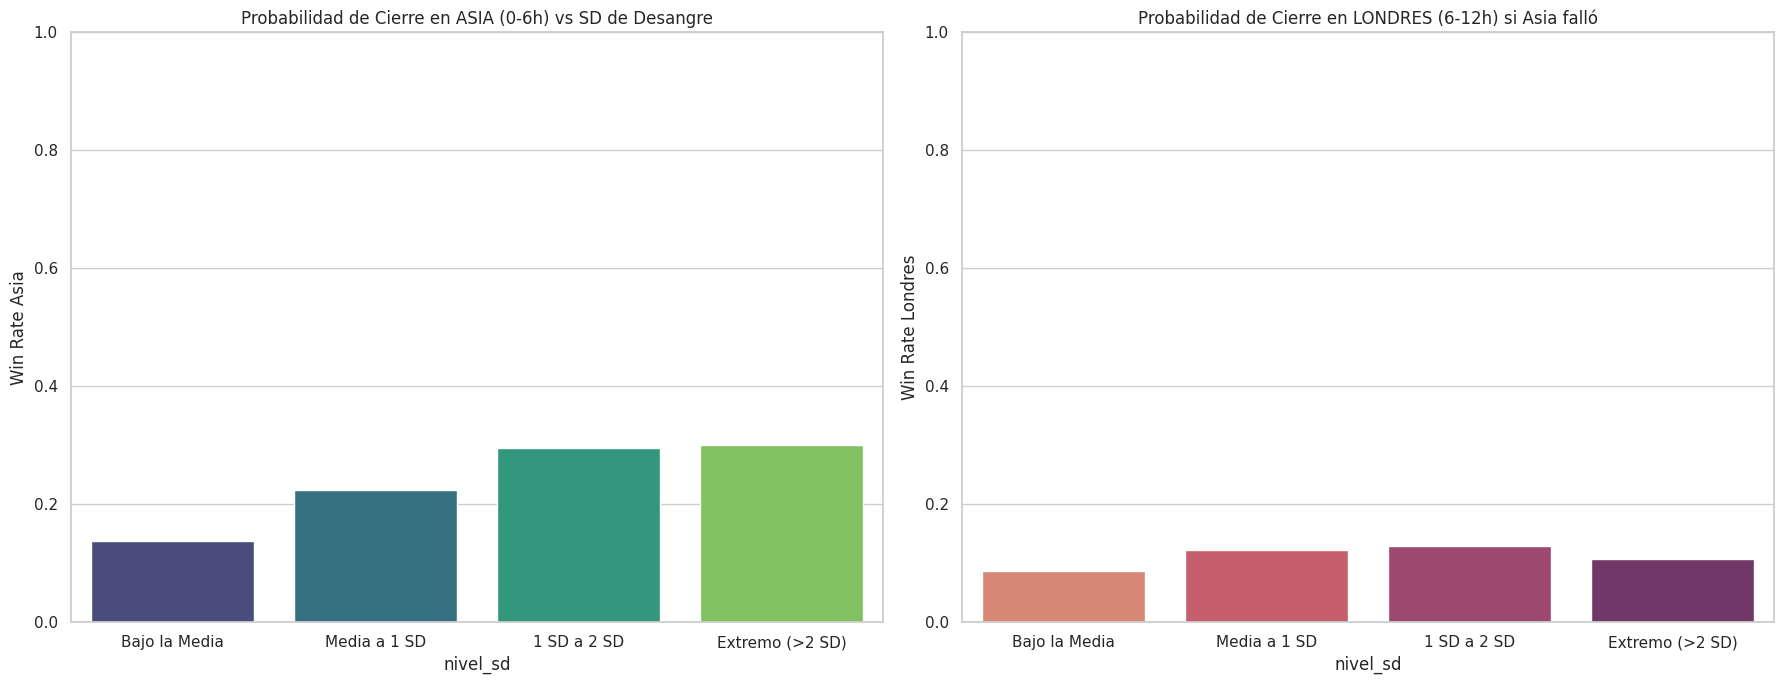


🎯 WIN RATE POR SESIÓN Y NIVEL DE DESANGRE:
                     Asia  Londres (post-Asia)
nivel_sd                                      
Bajo la Media    0.138047             0.085938
Media a 1 SD     0.224490             0.122807
1 SD a 2 SD      0.295455             0.129032
Extremo (>2 SD)  0.300000             0.107143


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_gaps_por_sesion(df, min_minutos_operables=15):
    """
    Analiza el desangre (SD) y la probabilidad de cierre segmentado por
    ventanas temporales: Asia (0-6h) y Londres/Overnight (>6h).
    """
    if df is None or df.empty:
        print("🛑 Error: El DataFrame proporcionado está vacío.")
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    results = []
    umbral_horas = min_minutos_operables / 60.0
    
    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            
            gap_size = apertura_domingo - cierre_viernes
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            # Ventana de seguimiento (reducida para enfoque intradía/overnight)
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 1440] # 24 horas
            
            # Cálculo de excursión adversa (Desangre)
            if gap_dir == "UP":
                max_recorrido_opuesto = apertura_domingo - post_gap_data['Low'].min()
                cierre_filtro = post_gap_data[post_gap_data['Low'] <= cierre_viernes]
            else:
                max_recorrido_opuesto = post_gap_data['High'].max() - apertura_domingo
                cierre_filtro = post_gap_data[post_gap_data['High'] >= cierre_viernes]
                
            tiempo_cierre = np.nan
            if not cierre_filtro.empty:
                tiempo_cierre = (cierre_filtro.index[0] - open_time).total_seconds() / 3600
            
            # Clasificación de éxito por sesión
            cerrado_asia = False
            cerrado_londres = False
            
            if not np.isnan(tiempo_cierre):
                if umbral_horas <= tiempo_cierre <= 6.0:
                    cerrado_asia = True
                elif 6.0 < tiempo_cierre <= 12.0:
                    cerrado_londres = True
                
            results.append({
                'fecha_apertura': open_time,
                'gap_size_handles': abs(gap_size),
                'max_recorrido_opuesto': round(max_recorrido_opuesto, 2),
                'cerrado_asia': cerrado_asia,
                'cerrado_londres': cerrado_londres,
                'horas_para_cierre': tiempo_cierre
            })
        except:
            continue

    df_gaps = pd.DataFrame(results)
    
    if not df_gaps.empty:
        # Calcular SD global del desangre para referencia
        mu = df_gaps['max_recorrido_opuesto'].mean()
        sigma = df_gaps['max_recorrido_opuesto'].std()
        
        def categorizar_sd(x):
            z = (x - mu) / sigma
            if z <= 0: return "Bajo la Media"
            if z <= 1.0: return "Media a 1 SD"
            if z <= 2.0: return "1 SD a 2 SD"
            return "Extremo (>2 SD)"
        
        df_gaps['nivel_sd'] = df_gaps['max_recorrido_opuesto'].apply(categorizar_sd)
        df_gaps.attrs['sd_params'] = {'mean': mu, 'std': sigma}
        
    return df_gaps

def visualizar_sesiones_sd(df_gaps):
    if df_gaps.empty: return
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    orden = ["Bajo la Media", "Media a 1 SD", "1 SD a 2 SD", "Extremo (>2 SD)"]
    
    # Probabilidad en ASIA
    prob_asia = df_gaps.groupby('nivel_sd')['cerrado_asia'].mean().reindex(orden)
    sns.barplot(x=prob_asia.index, y=prob_asia.values, ax=axes[0], palette='viridis')
    axes[0].set_title('Probabilidad de Cierre en ASIA (0-6h) vs SD de Desangre', fontsize=12)
    axes[0].set_ylabel('Win Rate Asia')
    axes[0].set_ylim(0, 1.0)
    
    # Probabilidad en LONDRES (para los que no cerraron en Asia)
    df_no_asia = df_gaps[df_gaps['cerrado_asia'] == False]
    prob_lon = df_no_asia.groupby('nivel_sd')['cerrado_londres'].mean().reindex(orden)
    sns.barplot(x=prob_lon.index, y=prob_lon.values, ax=axes[1], palette='flare')
    axes[1].set_title('Probabilidad de Cierre en LONDRES (6-12h) si Asia falló', fontsize=12)
    axes[1].set_ylabel('Win Rate Londres')
    axes[1].set_ylim(0, 1.0)
    
    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
FILE_PATH_PARQUET = '/home/quant/data/processed/nq_1m_continuous.parquet'

try:
    df_raw = pd.read_parquet(FILE_PATH_PARQUET)
    df_gaps = analizar_gaps_por_sesion(df_raw)
    
    if not df_gaps.empty:
        params = df_gaps.attrs['sd_params']
        print(f"📊 REFERENCIA DE DESANGRE HISTÓRICO:")
        print(f"• Media: {params['mean']:.2f} | 1 SD: {params['mean']+params['std']:.2f} | 2 SD: {params['mean']+2*params['std']:.2f}")
        
        visualizar_sesiones_sd(df_gaps)
        
        # Reporte detallado
        resumen_asia = df_gaps.groupby('nivel_sd')['cerrado_asia'].mean()
        df_no_asia = df_gaps[df_gaps['cerrado_asia'] == False]
        resumen_lon = df_no_asia.groupby('nivel_sd')['cerrado_londres'].mean()
        
        print("\n🎯 WIN RATE POR SESIÓN Y NIVEL DE DESANGRE:")
        comparativo = pd.DataFrame({'Asia': resumen_asia, 'Londres (post-Asia)': resumen_lon}).reindex(["Bajo la Media", "Media a 1 SD", "1 SD a 2 SD", "Extremo (>2 SD)"])
        print(comparativo)
    else:
        print("⚠️ No hay datos.")
except Exception as e:
    print(f"🛑 Error: {e}")

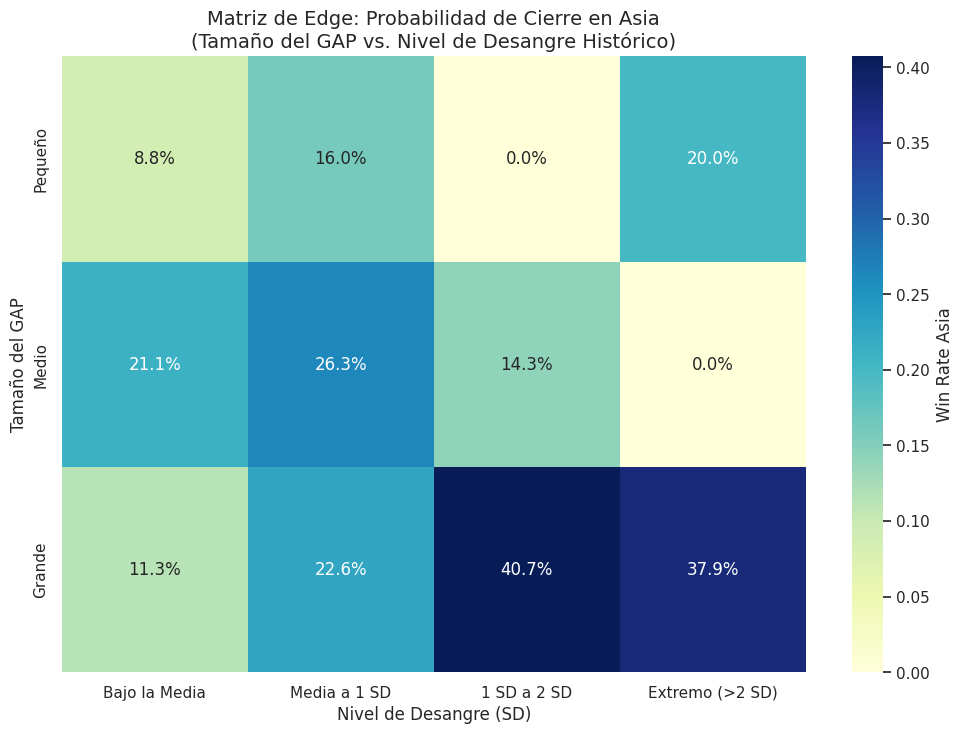


📊 NÚMERO DE CASOS (Muestra):
nivel_sd  Bajo la Media  Media a 1 SD  1 SD a 2 SD  Extremo (>2 SD)
tipo_gap                                                           
Pequeño             240            25            3                5
Medio               213            38           14                6
Grande              141            84           27               29


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_gaps_por_sesion(df, min_minutos_operables=15):
    """
    Analiza el desangre (SD) y la probabilidad de cierre segmentado por
    sesiones y tamaño del GAP para encontrar el edge definitivo.
    """
    if df is None or df.empty:
        print("🛑 Error: El DataFrame proporcionado está vacío.")
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    results = []
    umbral_horas = min_minutos_operables / 60.0
    
    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            
            gap_size = apertura_domingo - cierre_viernes
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            # Ventana de 24h
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 1440] 
            
            if gap_dir == "UP":
                max_recorrido_opuesto = apertura_domingo - post_gap_data['Low'].min()
                cierre_filtro = post_gap_data[post_gap_data['Low'] <= cierre_viernes]
            else:
                max_recorrido_opuesto = post_gap_data['High'].max() - apertura_domingo
                cierre_filtro = post_gap_data[post_gap_data['High'] >= cierre_viernes]
                
            tiempo_cierre = np.nan
            if not cierre_filtro.empty:
                tiempo_cierre = (cierre_filtro.index[0] - open_time).total_seconds() / 3600
            
            cerrado_asia = False
            if not np.isnan(tiempo_cierre) and umbral_horas <= tiempo_cierre <= 6.0:
                cerrado_asia = True
                
            results.append({
                'fecha_apertura': open_time,
                'gap_size_handles': abs(gap_size),
                'max_recorrido_opuesto': round(max_recorrido_opuesto, 2),
                'cerrado_asia': cerrado_asia
            })
        except:
            continue

    df_gaps = pd.DataFrame(results)
    
    if not df_gaps.empty:
        # 1. SD del Desangre
        mu = df_gaps['max_recorrido_opuesto'].mean()
        sigma = df_gaps['max_recorrido_opuesto'].std()
        
        def categorizar_sd(x):
            z = (x - mu) / sigma
            if z <= 0: return "Bajo la Media"
            if z <= 1.0: return "Media a 1 SD"
            if z <= 2.0: return "1 SD a 2 SD"
            return "Extremo (>2 SD)"
        
        df_gaps['nivel_sd'] = df_gaps['max_recorrido_opuesto'].apply(categorizar_sd)
        
        # 2. Categorización del Tamaño del GAP (Percentiles)
        q33 = df_gaps['gap_size_handles'].quantile(0.33)
        q66 = df_gaps['gap_size_handles'].quantile(0.66)
        
        def categorizar_gap(x):
            if x <= q33: return "Pequeño"
            if x <= q66: return "Medio"
            return "Grande"
            
        df_gaps['tipo_gap'] = df_gaps['gap_size_handles'].apply(categorizar_gap)
        df_gaps.attrs['sd_params'] = {'mean': mu, 'std': sigma}
        
    return df_gaps

def visualizar_confluencia(df_gaps):
    if df_gaps.empty: return
    
    sns.set_theme(style="whitegrid")
    
    # Crear Matriz de Probabilidad: Tipo GAP vs Nivel SD
    orden_sd = ["Bajo la Media", "Media a 1 SD", "1 SD a 2 SD", "Extremo (>2 SD)"]
    orden_gap = ["Pequeño", "Medio", "Grande"]
    
    pivot_prob = df_gaps.pivot_table(
        index='tipo_gap', 
        columns='nivel_sd', 
        values='cerrado_asia', 
        aggfunc='mean'
    ).reindex(index=orden_gap, columns=orden_sd)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_prob, annot=True, fmt=".1%", cmap="YlGnBu", cbar_kws={'label': 'Win Rate Asia'})
    plt.title('Matriz de Edge: Probabilidad de Cierre en Asia\n(Tamaño del GAP vs. Nivel de Desangre Histórico)', fontsize=14)
    plt.xlabel('Nivel de Desangre (SD)', fontsize=12)
    plt.ylabel('Tamaño del GAP', fontsize=12)
    plt.show()

# --- EJECUCIÓN ---
FILE_PATH_PARQUET = '/home/quant/data/processed/nq_1m_continuous.parquet'

try:
    df_raw = pd.read_parquet(FILE_PATH_PARQUET)
    df_gaps = analizar_gaps_por_sesion(df_raw)
    
    if not df_gaps.empty:
        visualizar_confluencia(df_gaps)
        
        # Reporte de volumen de casos para validez estadística
        conteo = df_gaps.pivot_table(index='tipo_gap', columns='nivel_sd', values='cerrado_asia', aggfunc='count').reindex(index=["Pequeño", "Medio", "Grande"], columns=["Bajo la Media", "Media a 1 SD", "1 SD a 2 SD", "Extremo (>2 SD)"])
        print("\n📊 NÚMERO DE CASOS (Muestra):")
        print(conteo)
except Exception as e:
    print(f"🛑 Error: {e}")

/tmp/ipykernel_168520/3970763324.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='proy_bin', y='max_alcanzado', data=prob_p[prob_p['proy_bin'] <= 5], ax=ax2, palette='magma')


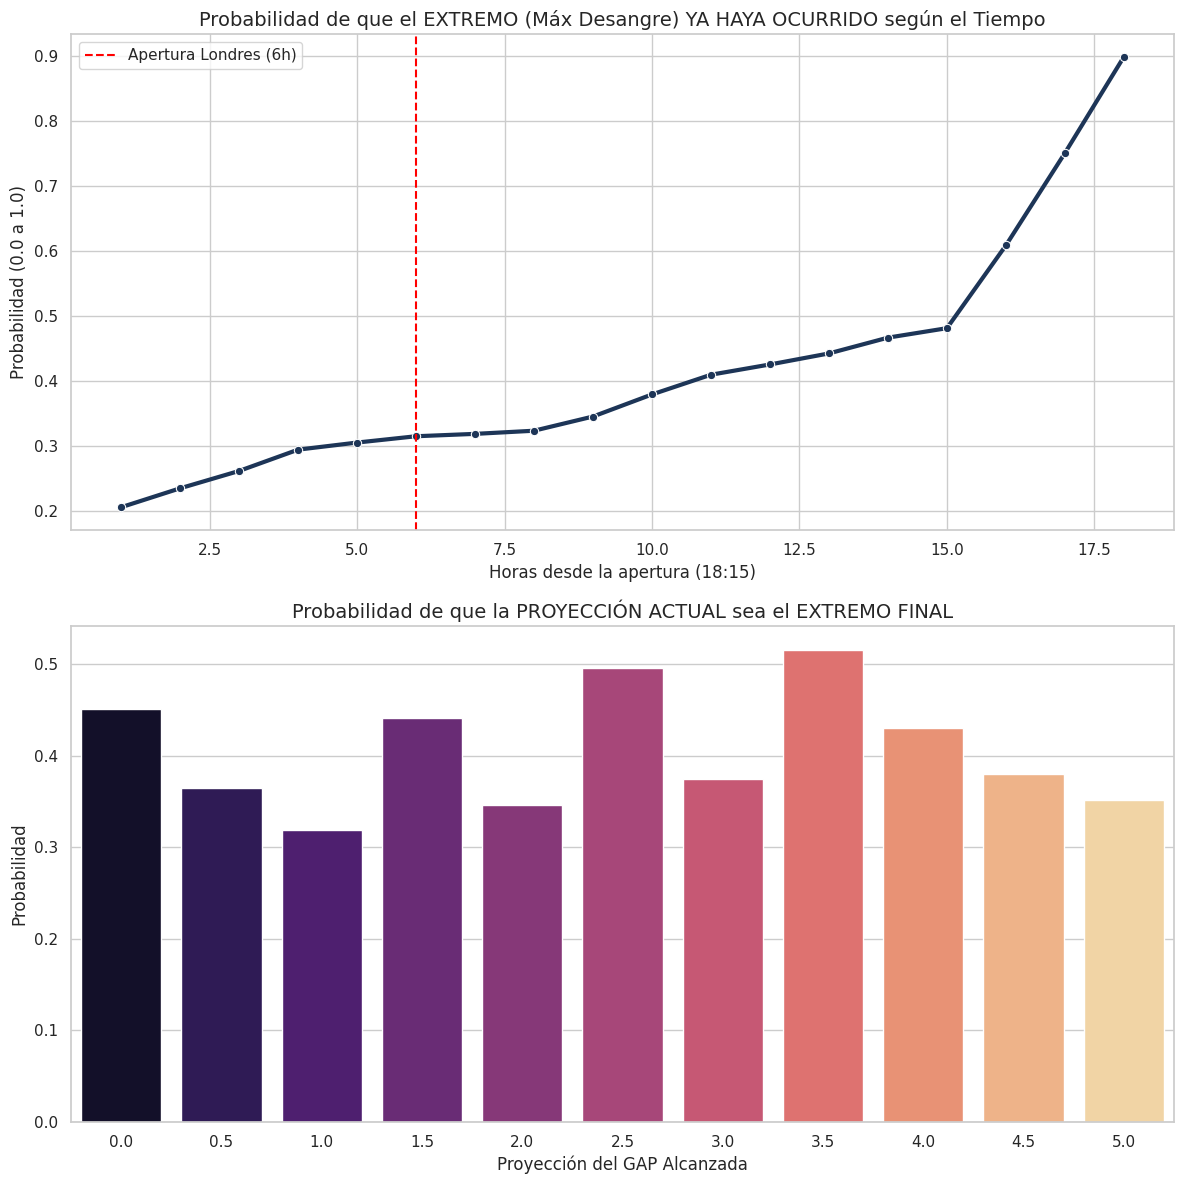

📊 PROBABILIDAD DE TECHO SEGÚN EL TIEMPO:
        max_alcanzado
hora_t               
9            0.345455
10           0.379394
11           0.409697
12           0.425455
13           0.442424
14           0.466667
15           0.481212
16           0.608485
17           0.750303
18           0.898182

📊 PROBABILIDAD DE TECHO SEGÚN LA PROY_ACTUAL:
          max_alcanzado
proy_bin               
0.0            0.450966
0.5            0.364638
1.0            0.318519
1.5            0.441327
2.0            0.345845
2.5            0.495399
3.0            0.373832
3.5            0.515326
4.0            0.430233
4.5            0.379518


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_agotamiento_condicional(df):
    """
    Analiza la probabilidad de que el extremo (máximo desangre) ya haya sido 
    alcanzado dado el tiempo transcurrido y la proyección actual.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Identificación de GAPs semanales (NWOG)
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    results = []
    
    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            
            gap_size = apertura_domingo - cierre_viernes
            abs_gap = abs(gap_size)
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            # Ventana de análisis: 18:15 a 12:00 (aprox 18 horas)
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 1080] 
            
            # 1. Encontrar el máximo alejamiento real en toda la ventana (El "Techo de Desangre")
            if gap_dir == "UP":
                full_excursion = apertura_domingo - post_gap_data['Low'].min()
                # El momento exacto del máximo desangre
                time_of_max = (post_gap_data['Low'].idxmin() - open_time).total_seconds() / 3600
            else:
                full_excursion = post_gap_data['High'].max() - apertura_domingo
                time_of_max = (post_gap_data['High'].idxmax() - open_time).total_seconds() / 3600
            
            max_proy_final = full_excursion / abs_gap if abs_gap != 0 else 0
            
            # 2. Trackeo hora por hora para ver cuándo el máximo ya fue alcanzado
            for h in range(1, 19):
                current_data = post_gap_data.iloc[:h*60]
                if current_data.empty: break
                
                # ¿El máximo de esta hora es ya el máximo final de la sesión?
                ya_es_el_maximo_final = h >= time_of_max
                
                if gap_dir == "UP":
                    excursion_actual = apertura_domingo - current_data['Low'].min()
                else:
                    excursion_actual = current_data['High'].max() - apertura_domingo
                
                proy_actual = excursion_actual / abs_gap if abs_gap != 0 else 0
                
                results.append({
                    'id_gap': open_time,
                    'hora_t': h,
                    'proy_actual': proy_actual,
                    'max_alcanzado': ya_es_el_maximo_final
                })
        except:
            continue

    df_res = pd.DataFrame(results)

    # --- CÁLCULOS CONDICIONALES ---
    
    # A. Probabilidad por Hora: Dado que estamos en hora T, ¿ya vimos el máximo?
    prob_h = df_res.groupby('hora_t')['max_alcanzado'].mean().reset_index()
    
    # B. Probabilidad por Proyección: Dado que estamos en Proy X, ¿es este el techo?
    # Agrupamos proyecciones en rangos de 0.5
    df_res['proy_bin'] = (df_res['proy_actual'] * 2).round() / 2
    prob_p = df_res.groupby('proy_bin')['max_alcanzado'].mean().reset_index()

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
    sns.set_theme(style="whitegrid")

    # Gráfico 1: El factor Tiempo
    sns.lineplot(x='hora_t', y='max_alcanzado', data=prob_h, ax=ax1, marker='o', color='#1d3557', lw=3)
    ax1.set_title('Probabilidad de que el EXTREMO (Máx Desangre) YA HAYA OCURRIDO según el Tiempo', fontsize=14)
    ax1.set_xlabel('Horas desde la apertura (18:15)', fontsize=12)
    ax1.set_ylabel('Probabilidad (0.0 a 1.0)', fontsize=12)
    ax1.axvline(6, color='red', linestyle='--', label='Apertura Londres (6h)')
    ax1.legend()

    # Gráfico 2: El factor Precio
    sns.barplot(x='proy_bin', y='max_alcanzado', data=prob_p[prob_p['proy_bin'] <= 5], ax=ax2, palette='magma')
    ax2.set_title('Probabilidad de que la PROYECCIÓN ACTUAL sea el EXTREMO FINAL', fontsize=14)
    ax2.set_xlabel('Proyección del GAP Alcanzada', fontsize=12)
    ax2.set_ylabel('Probabilidad', fontsize=12)

    plt.tight_layout()
    plt.show()

    return prob_h, prob_p

# Ejecución del análisis
try:
    # Asegúrate de que la ruta del archivo es correcta en tu entorno
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    prob_tiempo, prob_precio = analizar_agotamiento_condicional(df_raw)
    
    print("📊 PROBABILIDAD DE TECHO SEGÚN EL TIEMPO:")
    print(prob_tiempo.set_index('hora_t').tail(10))
    
    print("\n📊 PROBABILIDAD DE TECHO SEGÚN LA PROY_ACTUAL:")
    print(prob_precio.set_index('proy_bin').head(10))
    
except Exception as e:
    print(f"Error: {e}")

/tmp/ipykernel_168520/135447724.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='proy_bin', y='max_alcanzado', data=prob_p[prob_p['proy_bin'] <= 5], ax=ax2, palette='magma')
/tmp/ipykernel_168520/135447724.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sd_bin', y='max_alcanzado', data=prob_sd[(prob_sd['sd_bin'] >= -1) & (prob_sd['sd_bin'] <= 3)], ax=ax3, palette='viridis')


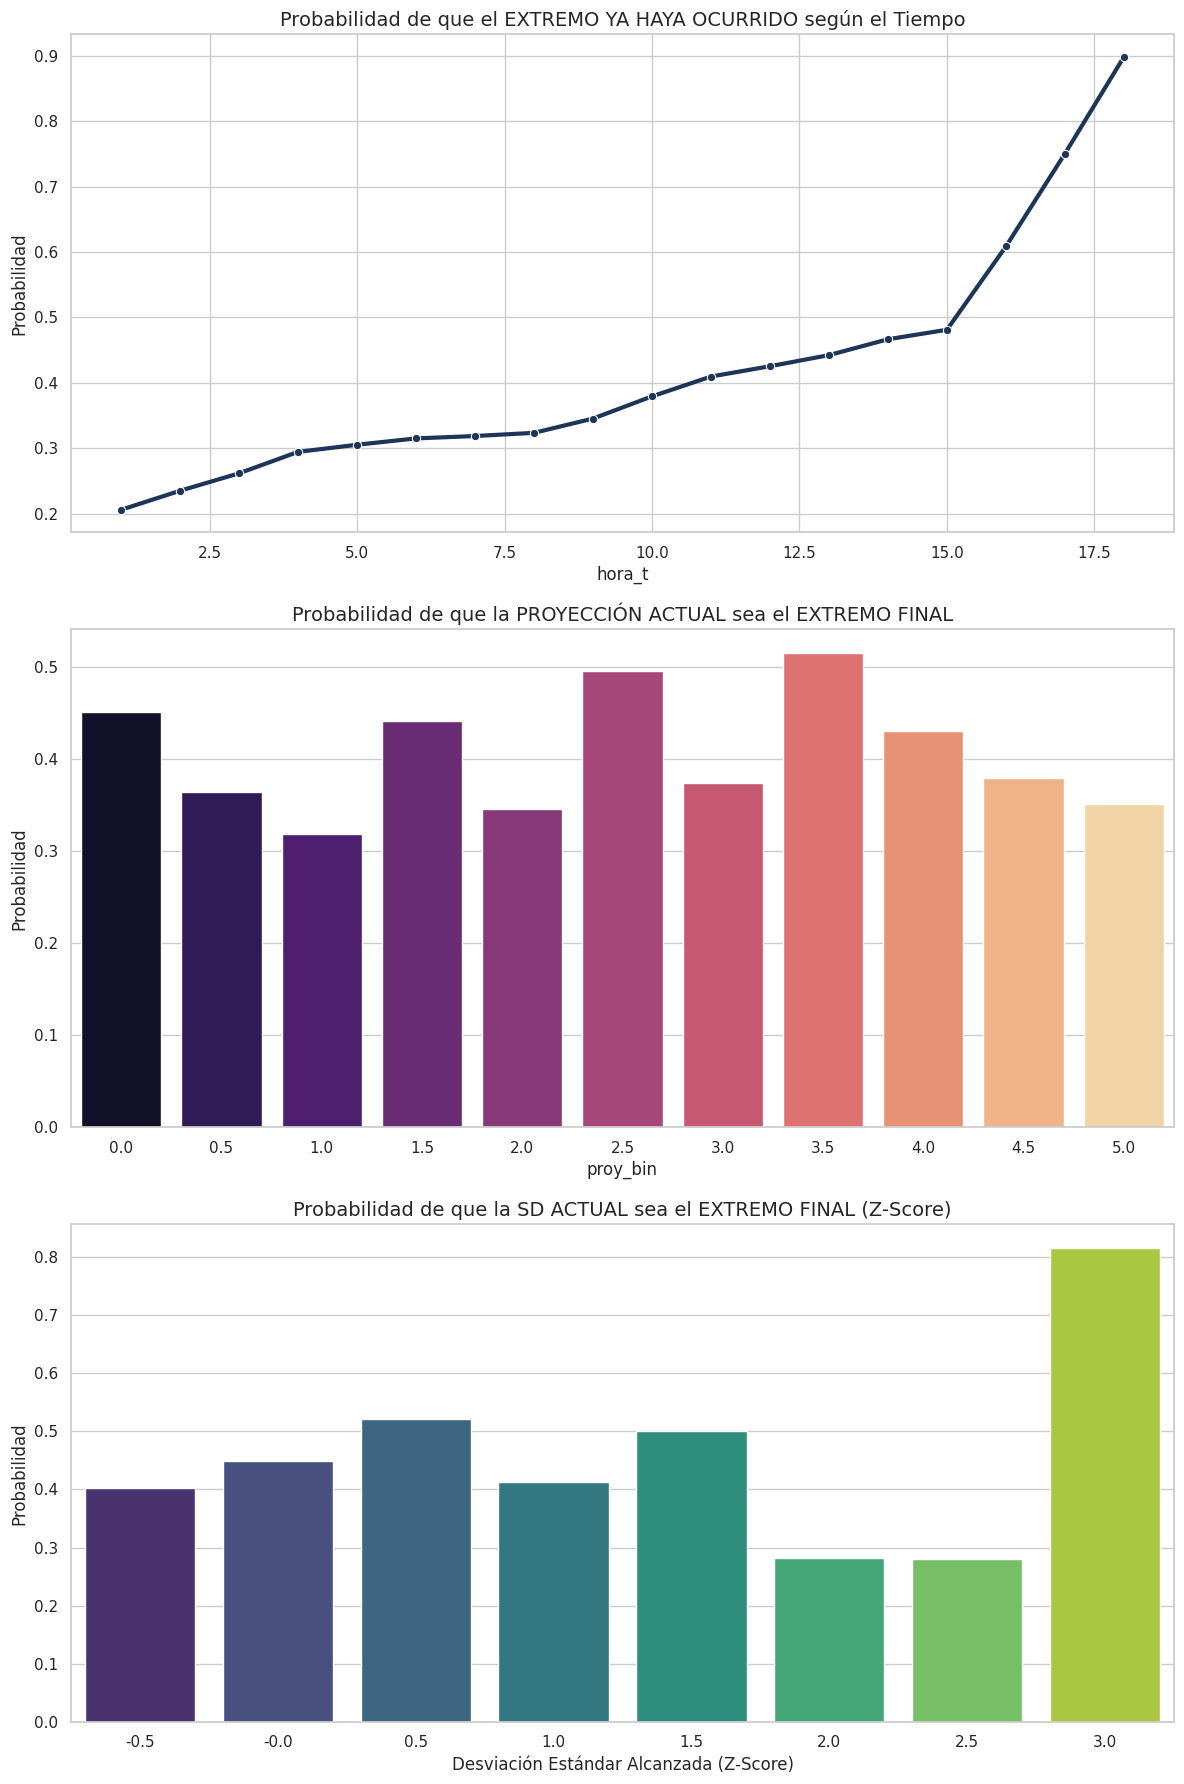


📊 PROBABILIDAD DE TECHO SEGÚN SD ACTUAL (Z-Score):
        max_alcanzado
sd_bin               
-0.0         0.448175
 0.5         0.520249
 1.0         0.412104
 1.5         0.500000
 2.0         0.281690
 2.5         0.280000


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_agotamiento_condicional(df):
    """
    Analiza la probabilidad de que el extremo (máximo desangre) ya haya sido 
    alcanzado dado el tiempo, la proyección y las Desviaciones Estándar (SD).
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Identificación de GAPs semanales (NWOG)
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    results = []
    
    # Primero calculamos la desviación estándar histórica global para tener una referencia de Z-Score
    # Usaremos una ventana previa o el total para definir mu y sigma del desangre
    all_max_excursions = []
    
    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 1080] 
            
            if (apertura_domingo - cierre_viernes) > 0:
                exc = apertura_domingo - post_gap_data['Low'].min()
            else:
                exc = post_gap_data['High'].max() - apertura_domingo
            all_max_excursions.append(exc)
        except: continue
        
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            
            gap_size = apertura_domingo - cierre_viernes
            abs_gap = abs(gap_size)
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            # Ventana de análisis: 18:15 a 12:00 (aprox 18 horas)
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 1080] 
            
            # 1. Encontrar el momento del máximo desangre real
            if gap_dir == "UP":
                full_excursion = apertura_domingo - post_gap_data['Low'].min()
                time_of_max = (post_gap_data['Low'].idxmin() - open_time).total_seconds() / 3600
            else:
                full_excursion = post_gap_data['High'].max() - apertura_domingo
                time_of_max = (post_gap_data['High'].idxmax() - open_time).total_seconds() / 3600
            
            # 2. Trackeo hora por hora
            for h in range(1, 19):
                current_data = post_gap_data.iloc[:h*60]
                if current_data.empty: break
                
                ya_es_el_maximo_final = h >= time_of_max
                
                if gap_dir == "UP":
                    excursion_actual = apertura_domingo - current_data['Low'].min()
                else:
                    excursion_actual = current_data['High'].max() - apertura_domingo
                
                proy_actual = excursion_actual / abs_gap if abs_gap != 0 else 0
                sd_actual = (excursion_actual - mu_hist) / sigma_hist if sigma_hist != 0 else 0
                
                results.append({
                    'id_gap': open_time,
                    'hora_t': h,
                    'proy_actual': proy_actual,
                    'sd_actual': sd_actual,
                    'max_alcanzado': ya_es_el_maximo_final
                })
        except:
            continue

    df_res = pd.DataFrame(results)

    # --- CÁLCULOS CONDICIONALES ---
    prob_h = df_res.groupby('hora_t')['max_alcanzado'].mean().reset_index()
    
    df_res['proy_bin'] = (df_res['proy_actual'] * 2).round() / 2
    prob_p = df_res.groupby('proy_bin')['max_alcanzado'].mean().reset_index()
    
    # C. Probabilidad por SD: Dado que estamos en X SD, ¿es este el techo?
    df_res['sd_bin'] = (df_res['sd_actual'] * 2).round() / 2
    prob_sd = df_res.groupby('sd_bin')['max_alcanzado'].mean().reset_index()

    # --- VISUALIZACIÓN ---
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18))
    sns.set_theme(style="whitegrid")

    # Gráfico 1: Tiempo
    sns.lineplot(x='hora_t', y='max_alcanzado', data=prob_h, ax=ax1, marker='o', color='#1d3557', lw=3)
    ax1.set_title('Probabilidad de que el EXTREMO YA HAYA OCURRIDO según el Tiempo', fontsize=14)
    ax1.set_ylabel('Probabilidad')

    # Gráfico 2: Proyecciones
    sns.barplot(x='proy_bin', y='max_alcanzado', data=prob_p[prob_p['proy_bin'] <= 5], ax=ax2, palette='magma')
    ax2.set_title('Probabilidad de que la PROYECCIÓN ACTUAL sea el EXTREMO FINAL', fontsize=14)
    ax2.set_ylabel('Probabilidad')

    # Gráfico 3: Desviación Estándar (SD)
    sns.barplot(x='sd_bin', y='max_alcanzado', data=prob_sd[(prob_sd['sd_bin'] >= -1) & (prob_sd['sd_bin'] <= 3)], ax=ax3, palette='viridis')
    ax3.set_title('Probabilidad de que la SD ACTUAL sea el EXTREMO FINAL (Z-Score)', fontsize=14)
    ax3.set_xlabel('Desviación Estándar Alcanzada (Z-Score)')
    ax3.set_ylabel('Probabilidad')

    plt.tight_layout()
    plt.show()

    return prob_h, prob_p, prob_sd

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    prob_t, prob_p, prob_sd = analizar_agotamiento_condicional(df_raw)
    
    print("\n📊 PROBABILIDAD DE TECHO SEGÚN SD ACTUAL (Z-Score):")
    # Mostramos los niveles clave: 0 (media), 1 SD, 2 SD
    print(prob_sd[prob_sd['sd_bin'].isin([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])].set_index('sd_bin'))
    
except Exception as e:
    print(f"Error: {e}")

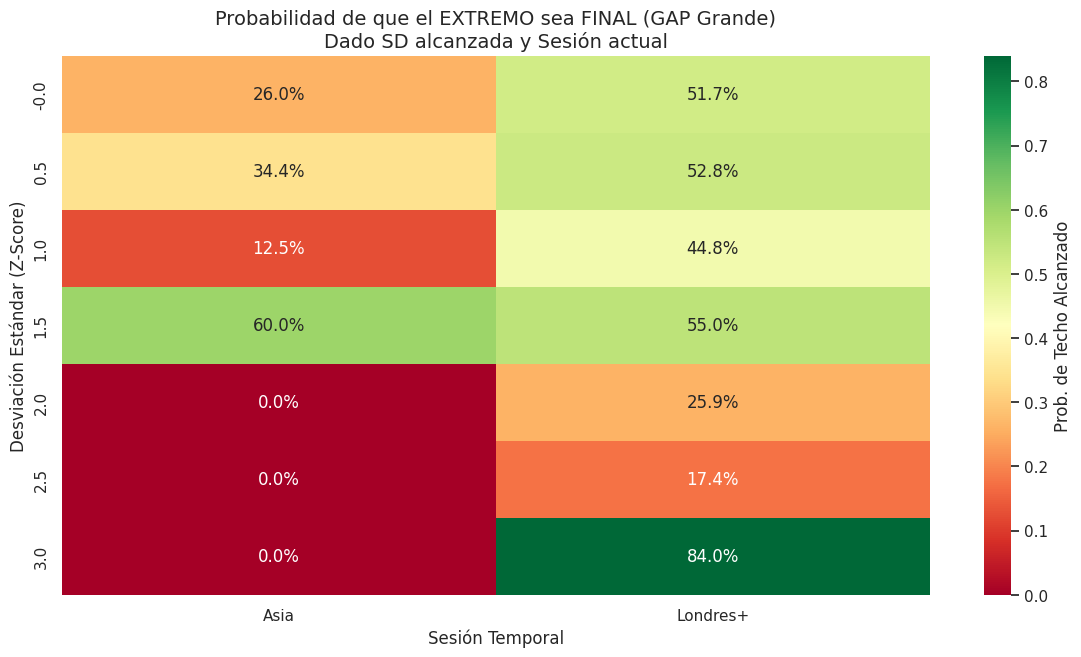


🎯 ANÁLISIS DE CONFLUENCIA (Sweet Spot):
Probabilidad de que el desangre haya terminado cuando:
- El GAP es Grande
- Estamos en Londres+ (>6h)
- El desangre > 2.0 SD
RESULTADO: 38.0% de probabilidad de que el techo sea FINAL.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_agotamiento_condicional(df):
    """
    Analiza la probabilidad de que el extremo (máximo desangre) ya haya sido 
    alcanzado filtrando por tiempo, tamaño de GAP y Desviaciones Estándar.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Identificación de GAPs semanales (NWOG)
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    results = []
    
    # Cálculo de métricas históricas de desangre para Z-Score
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 1080] 
            
            if (apertura_domingo - cierre_viernes) > 0:
                exc = apertura_domingo - post_gap_data['Low'].min()
            else:
                exc = post_gap_data['High'].max() - apertura_domingo
            all_max_excursions.append(exc)
        except: continue
        
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    # Procesamiento de GAPs con categorías de tamaño
    all_gaps_data = []
    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            all_gaps_data.append({'id': open_time, 'size': abs(apertura_domingo - cierre_viernes)})
        except: continue
    
    df_sizes = pd.DataFrame(all_gaps_data)
    q66 = df_sizes['size'].quantile(0.66) # Umbral para GAP Grande

    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            
            gap_size = apertura_domingo - cierre_viernes
            abs_gap = abs(gap_size)
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            tipo_gap = "Grande" if abs_gap >= q66 else "Normal/Pequeño"
            
            # Ventana de análisis: 18:15 a 12:00
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 1080] 
            
            if gap_dir == "UP":
                time_of_max = (post_gap_data['Low'].idxmin() - open_time).total_seconds() / 3600
            else:
                time_of_max = (post_gap_data['High'].idxmax() - open_time).total_seconds() / 3600
            
            for h in range(1, 19):
                current_data = post_gap_data.iloc[:h*60]
                if current_data.empty: break
                
                ya_es_el_maximo_final = h >= time_of_max
                
                if gap_dir == "UP":
                    excursion_actual = apertura_domingo - current_data['Low'].min()
                else:
                    excursion_actual = current_data['High'].max() - apertura_domingo
                
                sd_actual = (excursion_actual - mu_hist) / sigma_hist if sigma_hist != 0 else 0
                
                results.append({
                    'id_gap': open_time,
                    'hora_t': h,
                    'tipo_gap': tipo_gap,
                    'sd_actual': sd_actual,
                    'max_alcanzado': ya_es_el_maximo_final
                })
        except: continue

    df_res = pd.DataFrame(results)
    df_res['sd_bin'] = (df_res['sd_actual'] * 2).round() / 2

    # --- VISUALIZACIÓN DE PROBABILIDAD CONDICIONAL CRÍTICA ---
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # Filtramos por GAPs Grandes y niveles de SD relevantes para comparar sesiones
    f_grandes = df_res[df_res['tipo_gap'] == "Grande"]
    
    # Comparativa: Probabilidad de que el máximo ya ocurrió dado SD y Sesión
    # Asia (H <= 6) vs Londres (H > 6)
    df_res['sesion'] = df_res['hora_t'].apply(lambda x: 'Asia' if x <= 6 else 'Londres+')
    
    pivot_ss = df_res[df_res['tipo_gap'] == "Grande"].pivot_table(
        index='sd_bin', 
        columns='sesion', 
        values='max_alcanzado', 
        aggfunc='mean'
    ).query('sd_bin >= 0 & sd_bin <= 3.0')

    sns.heatmap(pivot_ss, annot=True, fmt=".1%", cmap="RdYlGn", cbar_kws={'label': 'Prob. de Techo Alcanzado'})
    plt.title('Probabilidad de que el EXTREMO sea FINAL (GAP Grande)\nDado SD alcanzada y Sesión actual', fontsize=14)
    plt.ylabel('Desviación Estándar (Z-Score)')
    plt.xlabel('Sesión Temporal')
    plt.show()

    return df_res

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    df_final = analizar_agotamiento_condicional(df_raw)
    
    # Reporte de Sweet Spot para el usuario
    ss = df_final[(df_final['tipo_gap'] == "Grande") & (df_final['sd_bin'] >= 2.0) & (df_final['hora_t'] > 6)]
    print("\n🎯 ANÁLISIS DE CONFLUENCIA (Sweet Spot):")
    print(f"Probabilidad de que el desangre haya terminado cuando:")
    print(f"- El GAP es Grande")
    print(f"- Estamos en Londres+ (>6h)")
    print(f"- El desangre > 2.0 SD")
    print(f"RESULTADO: {ss['max_alcanzado'].mean():.1%} de probabilidad de que el techo sea FINAL.")
    
except Exception as e:
    print(f"Error: {e}")

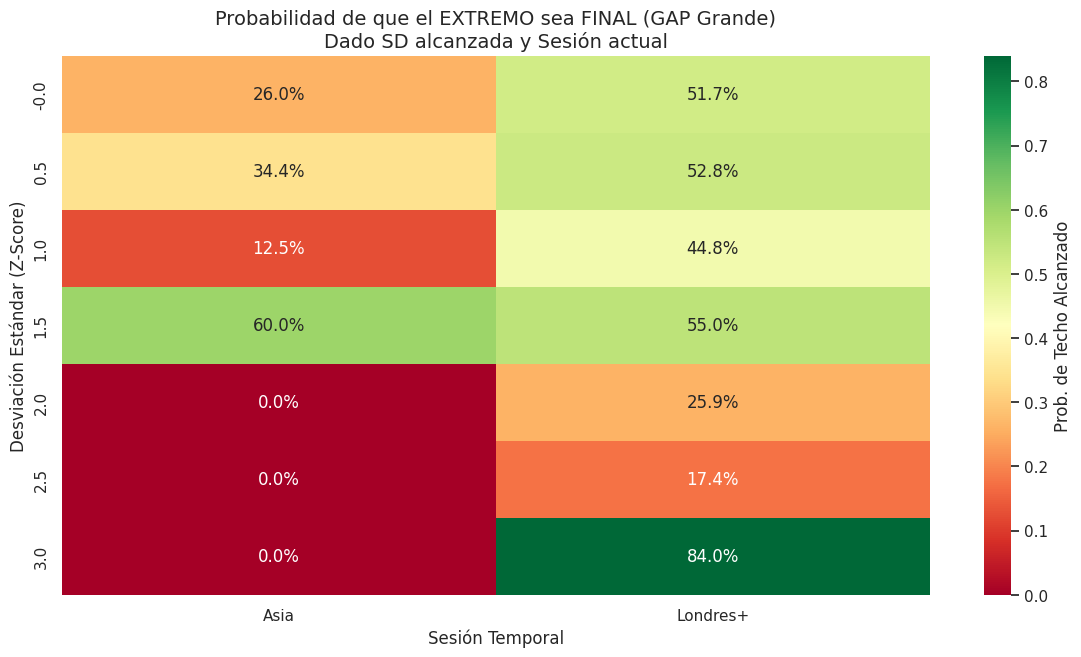


📋 RESULTADOS PARA COPIAR AL CHAT

🟢 PROBABILIDAD CONDICIONAL DE TECHO (GAP GRANDE):
sesion      Asia  Londres+
sd_bin                    
-0.0    0.259819  0.517281
 0.5    0.344444  0.527607
 1.0    0.125000  0.448113
 1.5    0.600000  0.550000
 2.0    0.000000  0.259259
 2.5    0.000000  0.173913
 3.0    0.000000  0.840000

🎯 ANÁLISIS DE CONFLUENCIA (Sweet Spot):
Situación: GAP Grande + Sesión Londres+ + Desangre > 2.0 SD
Probabilidad de que el extremo ya haya ocurrido: 38.03%
Basado en 26 eventos históricos únicos.

📊 DESGLOSE POR SD (Promedio Global GAPs Grandes):
sd_bin
-0.0    0.446205
 0.5    0.487981
 1.0    0.396825
 1.5    0.554545
 2.0    0.218750
 2.5    0.153846
 3.0    0.807692
Name: max_alcanzado, dtype: float64


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_agotamiento_condicional(df):
    """
    Analiza la probabilidad de que el extremo (máximo desangre) ya haya sido 
    alcanzado filtrando por tiempo, tamaño de GAP y Desviaciones Estándar.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Identificación de GAPs semanales (NWOG)
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    results = []
    
    # Cálculo de métricas históricas de desangre para Z-Score
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 1080] 
            
            if (apertura_domingo - cierre_viernes) > 0:
                exc = apertura_domingo - post_gap_data['Low'].min()
            else:
                exc = post_gap_data['High'].max() - apertura_domingo
            all_max_excursions.append(exc)
        except: continue
        
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    # Procesamiento de GAPs con categorías de tamaño
    all_gaps_data = []
    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            all_gaps_data.append({'id': open_time, 'size': abs(apertura_domingo - cierre_viernes)})
        except: continue
    
    df_sizes = pd.DataFrame(all_gaps_data)
    q66 = df_sizes['size'].quantile(0.66) # Umbral para GAP Grande

    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            
            gap_size = apertura_domingo - cierre_viernes
            abs_gap = abs(gap_size)
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            tipo_gap = "Grande" if abs_gap >= q66 else "Normal/Pequeño"
            
            # Ventana de análisis: 18:15 a 12:00
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 1080] 
            
            if gap_dir == "UP":
                time_of_max = (post_gap_data['Low'].idxmin() - open_time).total_seconds() / 3600
            else:
                time_of_max = (post_gap_data['High'].idxmax() - open_time).total_seconds() / 3600
            
            for h in range(1, 19):
                current_data = post_gap_data.iloc[:h*60]
                if current_data.empty: break
                
                ya_es_el_maximo_final = h >= time_of_max
                
                if gap_dir == "UP":
                    excursion_actual = apertura_domingo - current_data['Low'].min()
                else:
                    excursion_actual = current_data['High'].max() - apertura_domingo
                
                sd_actual = (excursion_actual - mu_hist) / sigma_hist if sigma_hist != 0 else 0
                
                results.append({
                    'id_gap': open_time,
                    'hora_t': h,
                    'tipo_gap': tipo_gap,
                    'sd_actual': sd_actual,
                    'max_alcanzado': ya_es_el_maximo_final
                })
        except: continue

    df_res = pd.DataFrame(results)
    df_res['sd_bin'] = (df_res['sd_actual'] * 2).round() / 2
    df_res['sesion'] = df_res['hora_t'].apply(lambda x: 'Asia' if x <= 6 else 'Londres+')

    # --- VISUALIZACIÓN DE PROBABILIDAD CONDICIONAL CRÍTICA ---
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    pivot_ss = df_res[df_res['tipo_gap'] == "Grande"].pivot_table(
        index='sd_bin', 
        columns='sesion', 
        values='max_alcanzado', 
        aggfunc='mean'
    ).query('sd_bin >= 0 & sd_bin <= 3.0')

    sns.heatmap(pivot_ss, annot=True, fmt=".1%", cmap="RdYlGn", cbar_kws={'label': 'Prob. de Techo Alcanzado'})
    plt.title('Probabilidad de que el EXTREMO sea FINAL (GAP Grande)\nDado SD alcanzada y Sesión actual', fontsize=14)
    plt.ylabel('Desviación Estándar (Z-Score)')
    plt.xlabel('Sesión Temporal')
    plt.show()

    return df_res, pivot_ss

# Ejecución y salida de texto para el chat
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    df_final, pivot_resultados = analizar_agotamiento_condicional(df_raw)
    
    print("\n" + "="*50)
    print("📋 RESULTADOS PARA COPIAR AL CHAT")
    print("="*50)
    
    print("\n🟢 PROBABILIDAD CONDICIONAL DE TECHO (GAP GRANDE):")
    print(pivot_resultados)
    
    print("\n🎯 ANÁLISIS DE CONFLUENCIA (Sweet Spot):")
    ss = df_final[(df_final['tipo_gap'] == "Grande") & (df_final['sd_bin'] >= 2.0) & (df_final['hora_t'] > 6)]
    prob_ss = ss['max_alcanzado'].mean()
    casos_ss = len(ss['id_gap'].unique())
    
    print(f"Situación: GAP Grande + Sesión Londres+ + Desangre > 2.0 SD")
    print(f"Probabilidad de que el extremo ya haya ocurrido: {prob_ss:.2%}")
    print(f"Basado en {casos_ss} eventos históricos únicos.")
    
    print("\n📊 DESGLOSE POR SD (Promedio Global GAPs Grandes):")
    sd_report = df_final[df_final['tipo_gap'] == "Grande"].groupby('sd_bin')['max_alcanzado'].mean()
    print(sd_report.loc[0.0:3.0])
    
    print("="*50)
    
except Exception as e:
    print(f"Error: {e}")

/tmp/ipykernel_168520/2005961518.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Win_Rate', data=summary, ax=ax1, palette='viridis')
/tmp/ipykernel_168520/2005961518.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Costo_Oportunidad', data=summary, ax=ax2, palette='magma')


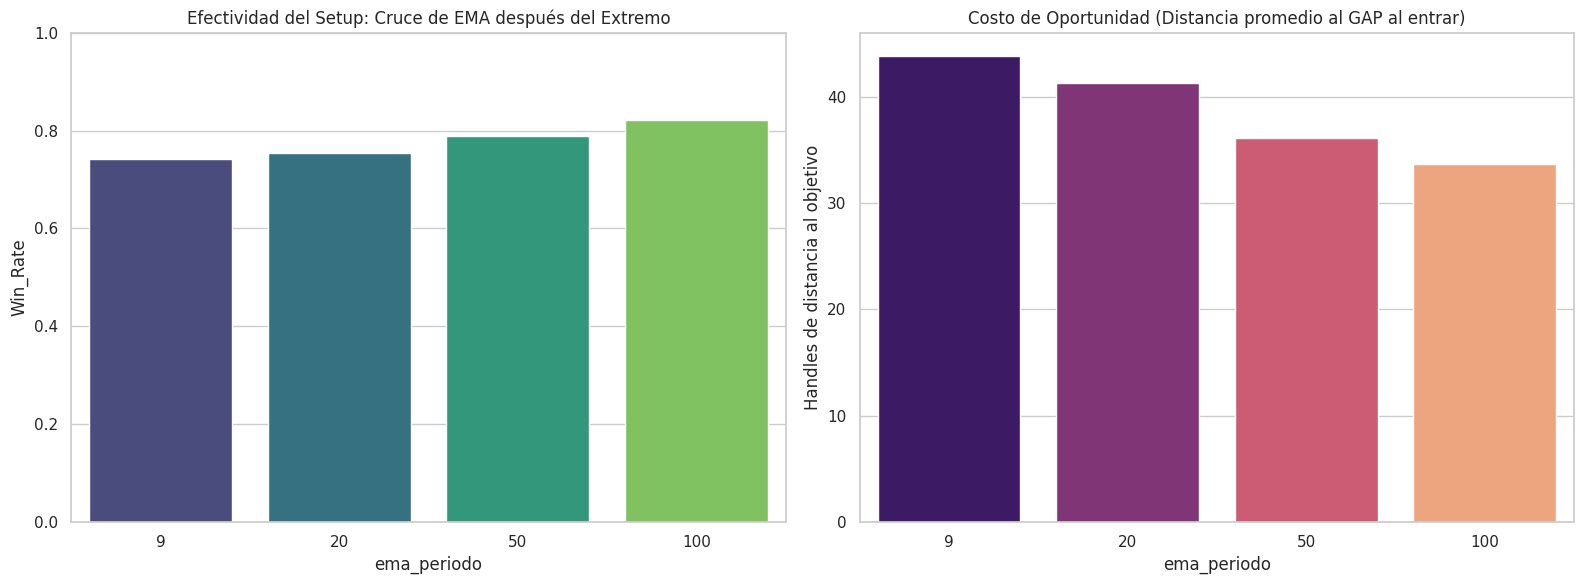

📊 RESUMEN DE DISPARADORES EMA:
             Win_Rate  Costo_Oportunidad  Frecuencia
ema_periodo                                         
9            0.742424          43.827967         792
20           0.753846          41.316026         780
50           0.788410          36.152628         742
100          0.822191          33.725107         703


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_setups_ema(df, periodos=[9, 20, 50, 100]):
    """
    Analiza la efectividad del cruce de precio con EMAs de distintos periodos
    como disparador de entrada una vez alcanzado un nivel crítico de desangre.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Identificación de GAPs semanales
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos las EMAs en el dataframe original para mayor velocidad
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    results = []
    
    for open_time in gap_indices:
        try:
            idx_apertura = df.index.get_loc(open_time)
            cierre_viernes = df.iloc[idx_apertura - 1]['Close']
            apertura_domingo = df.iloc[idx_apertura]['Open']
            
            gap_size = apertura_domingo - cierre_viernes
            abs_gap = abs(gap_size)
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            # Ventana operativa (18:15 a 12:00)
            post_gap_data = df.iloc[idx_apertura : idx_apertura + 1080].copy()
            
            # Buscamos el momento de mayor desangre (extremo)
            if gap_dir == "UP":
                extremo_val = post_gap_data['Low'].min()
                idx_extremo = post_gap_data['Low'].idxmin()
            else:
                extremo_val = post_gap_data['High'].max()
                idx_extremo = post_gap_data['High'].idxmax()
            
            # Analizamos cada EMA después del extremo
            post_extremo_data = post_gap_data.loc[idx_extremo:]
            
            for p in periodos:
                ema_col = f'ema_{p}'
                trigger_found = False
                
                # Buscamos el cruce: Precio cierra por encima (si gap UP/desangre abajo) 
                # o debajo (si gap DOWN/desangre arriba) de la EMA
                for timestamp, row in post_extremo_data.iterrows():
                    precio = row['Close']
                    ema_val = row[ema_col]
                    
                    if gap_dir == "UP": # Buscamos largos hacia el GAP
                        condicion = precio > ema_val
                    else: # Buscamos cortos hacia el GAP
                        condicion = precio < ema_val
                        
                    if condicion:
                        # Calculamos efectividad del trigger
                        distancia_al_gap = abs(precio - cierre_viernes)
                        # ¿El precio llegó a cerrar el gap después de este cruce?
                        data_futura = post_gap_data.loc[timestamp:]
                        if gap_dir == "UP":
                            exito = data_futura['High'].max() >= cierre_viernes
                        else:
                            exito = data_futura['Low'].min() <= cierre_viernes
                        
                        results.append({
                            'ema_periodo': p,
                            'gap_id': open_time,
                            'distancia_entrada': distancia_al_gap,
                            'exito': exito,
                            'gap_size': abs_gap
                        })
                        trigger_found = True
                        break
        except: continue

    df_results = pd.DataFrame(results)
    
    # --- REPORTES ---
    summary = df_results.groupby('ema_periodo').agg({
        'exito': 'mean',
        'distancia_entrada': 'mean',
        'gap_id': 'count'
    }).rename(columns={'exito': 'Win_Rate', 'gap_id': 'Frecuencia', 'distancia_entrada': 'Costo_Oportunidad'})

    # Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_theme(style="whitegrid")

    sns.barplot(x=summary.index, y='Win_Rate', data=summary, ax=ax1, palette='viridis')
    ax1.set_title('Efectividad del Setup: Cruce de EMA después del Extremo', fontsize=12)
    ax1.set_ylim(0, 1)

    sns.barplot(x=summary.index, y='Costo_Oportunidad', data=summary, ax=ax2, palette='magma')
    ax2.set_title('Costo de Oportunidad (Distancia promedio al GAP al entrar)', fontsize=12)
    ax2.set_ylabel('Handles de distancia al objetivo')

    plt.tight_layout()
    plt.show()

    return summary

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    resumen_ema = analizar_setups_ema(df_raw)
    print("📊 RESUMEN DE DISPARADORES EMA:")
    print(resumen_ema)
except Exception as e:
    print(f"Error: {e}")

/tmp/ipykernel_168520/3233791568.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Win_Rate', data=summary, ax=ax1, palette='Greens_d')
/tmp/ipykernel_168520/3233791568.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Avg_RR', data=summary, ax=ax2, palette='Blues_d')


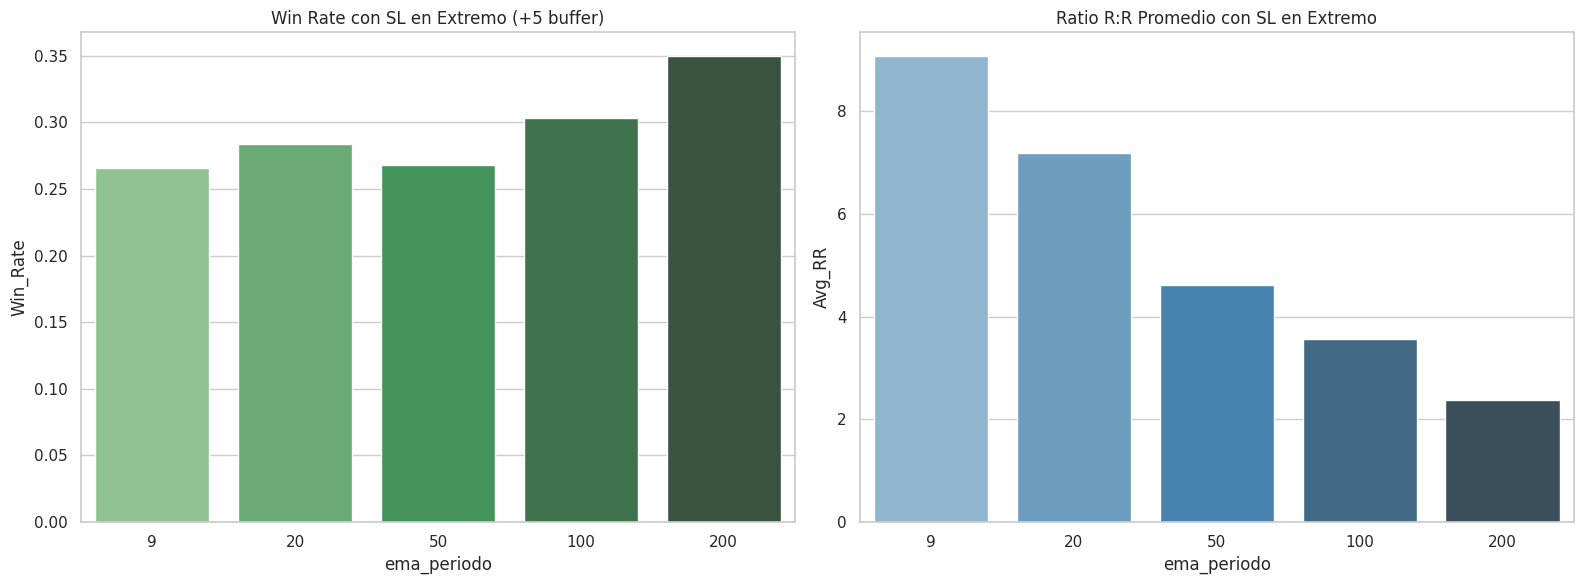

📊 RESULTADOS CON SL EN EL EXTREMO (+5 Handles Buffer):
             Win_Rate    Avg_RR    Avg_Risk  Frecuencia
ema_periodo                                            
9            0.265625  9.085394   41.769531          64
20           0.283333  7.185307   51.287500          60
50           0.268293  4.609298   79.091463          41
100          0.303030  3.561401  102.128788          33
200          0.350000  2.378302  155.325000          20


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_setups_ema(df, periodos=[9, 20, 50, 100, 200]):
    """
    Analiza la efectividad del cruce de precio con EMAs usando el extremo
    del recorrido opuesto como Stop Loss técnico.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 1. Identificación de GAPs y cálculo de métricas base
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de SD histórica para filtrar entorno
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            post = df.iloc[idx : idx + 1080]
            exc = abs(a_d - post['Low'].min()) if (a_d - c_v) > 0 else abs(post['High'].max() - a_d)
            all_max_excursions.append(exc)
        except: continue
    
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    results = []
    
    for open_time in gap_indices:
        try:
            idx_ap = df.index.get_loc(open_time)
            cierre_v = df.iloc[idx_ap - 1]['Close']
            apertura_d = df.iloc[idx_ap]['Open']
            
            gap_size = apertura_d - cierre_v
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
            
            # Definimos el extremo real y el valor del SL
            if gap_dir == "UP":
                idx_extremo = post_gap['Low'].idxmin()
                val_extremo = post_gap['Low'].min()
                sl_precio = val_extremo - 5  # Extremo + 5 handles de buffer
            else:
                idx_extremo = post_gap['High'].idxmax()
                val_extremo = post_gap['High'].max()
                sl_precio = val_extremo + 5  # Extremo + 5 handles de buffer

            post_extremo = post_gap.loc[idx_extremo:]
            
            for p in periodos:
                ema_col = f'ema_{p}'
                for ts, row in post_extremo.iterrows():
                    # Condición de Cruce
                    if (gap_dir == "UP" and row['Close'] > row[ema_col]) or \
                       (gap_dir == "DOWN" and row['Close'] < row[ema_col]):
                        
                        # Datos de la entrada
                        precio_entrada = row['Close']
                        exc_actual = abs(apertura_d - row['Low']) if gap_dir == "UP" else abs(row['High'] - apertura_d)
                        sd_entrada = (exc_actual - mu_hist) / sigma_hist
                        
                        # Resultado del trade con SL en el extremo
                        futuro = post_gap.loc[ts:]
                        exito = False
                        razon_cierre = "TimeOut"
                        
                        for ts_f, row_f in futuro.iterrows():
                            # 1. ¿Toca Stop Loss?
                            if (gap_dir == "UP" and row_f['Low'] <= sl_precio) or \
                               (gap_dir == "DOWN" and row_f['High'] >= sl_precio):
                                exito = False
                                razon_cierre = "SL"
                                break
                            # 2. ¿Toca Take Profit (GAP)?
                            if (gap_dir == "UP" and row_f['High'] >= cierre_v) or \
                               (gap_dir == "DOWN" and row_f['Low'] <= cierre_v):
                                exito = True
                                razon_cierre = "TP"
                                break
                        
                        risk = abs(precio_entrada - sl_precio)
                        reward = abs(precio_entrada - cierre_v)
                        
                        results.append({
                            'ema_periodo': p,
                            'exito': exito,
                            'razon': razon_cierre,
                            'rr': reward / risk if risk > 0 else 0,
                            'sd_entrada': sd_entrada,
                            'risk_handles': risk
                        })
                        break
        except: continue

    df_res = pd.DataFrame(results)
    
    # --- REPORTES ---
    df_filtered = df_res[df_res['sd_entrada'] >= 1.0] # Filtro de agotamiento
    
    summary = df_filtered.groupby('ema_periodo').agg({
        'exito': 'mean',
        'rr': 'mean',
        'risk_handles': 'mean',
        'sd_entrada': 'count'
    }).rename(columns={'exito': 'Win_Rate', 'sd_entrada': 'Frecuencia', 'rr': 'Avg_RR', 'risk_handles': 'Avg_Risk'})

    # Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(x=summary.index, y='Win_Rate', data=summary, ax=ax1, palette='Greens_d')
    ax1.set_title('Win Rate con SL en Extremo (+5 buffer)', fontsize=12)
    
    sns.barplot(x=summary.index, y='Avg_RR', data=summary, ax=ax2, palette='Blues_d')
    ax2.set_title('Ratio R:R Promedio con SL en Extremo', fontsize=12)

    plt.tight_layout()
    plt.show()

    return summary

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    resumen = analizar_setups_ema(df_raw)
    print("📊 RESULTADOS CON SL EN EL EXTREMO (+5 Handles Buffer):")
    print(resumen)
except Exception as e:
    print(f"Error: {e}")

/tmp/ipykernel_168520/1106674921.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Win_Rate', data=summary, ax=ax1, palette='Greens_d')
/tmp/ipykernel_168520/1106674921.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='EV_per_Trade', data=summary, ax=ax2, palette='Oranges_d')


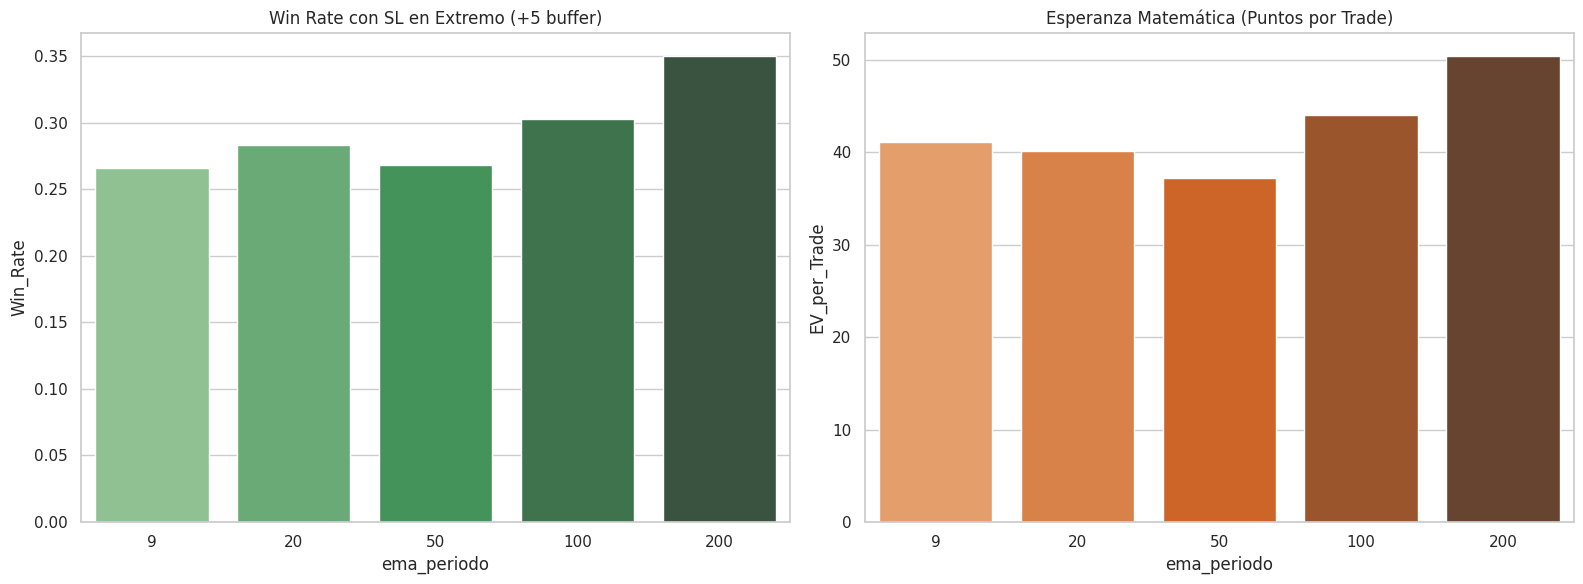

📊 RESULTADOS FINALES (SL EN EXTREMO + MÉTRICAS DE RENTABILIDAD):
             Win_Rate    Avg_RR  Profit_Total_Handles  Frecuencia  \
ema_periodo                                                         
9            0.265625  9.085394               2631.25          64   
20           0.283333  7.185307               2410.50          60   
50           0.268293  4.609298               1526.25          41   
100          0.303030  3.561401               1453.50          33   
200          0.350000  2.378302               1008.25          20   

             EV_per_Trade  
ema_periodo                
9               41.113281  
20              40.175000  
50              37.225610  
100             44.045455  
200             50.412500  


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_setups_ema(df, periodos=[9, 20, 50, 100, 200]):
    """
    Analiza la efectividad del cruce de precio con EMAs usando el extremo
    del recorrido opuesto como Stop Loss técnico y calcula la Esperanza Matemática.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 1. Identificación de GAPs y cálculo de métricas base
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de SD histórica para filtrar entorno
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            post = df.iloc[idx : idx + 1080]
            exc = abs(a_d - post['Low'].min()) if (a_d - c_v) > 0 else abs(post['High'].max() - a_d)
            all_max_excursions.append(exc)
        except: continue
    
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    results = []
    
    for open_time in gap_indices:
        try:
            idx_ap = df.index.get_loc(open_time)
            cierre_v = df.iloc[idx_ap - 1]['Close']
            apertura_d = df.iloc[idx_ap]['Open']
            
            gap_size = apertura_d - cierre_v
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
            
            # Definimos el extremo real y el valor del SL
            if gap_dir == "UP":
                idx_extremo = post_gap['Low'].idxmin()
                val_extremo = post_gap['Low'].min()
                sl_precio = val_extremo - 5  # Extremo + 5 handles de buffer
            else:
                idx_extremo = post_gap['High'].idxmax()
                val_extremo = post_gap['High'].max()
                sl_precio = val_extremo + 5  # Extremo + 5 handles de buffer

            post_extremo = post_gap.loc[idx_extremo:]
            
            for p in periodos:
                ema_col = f'ema_{p}'
                for ts, row in post_extremo.iterrows():
                    # Condición de Cruce
                    if (gap_dir == "UP" and row['Close'] > row[ema_col]) or \
                       (gap_dir == "DOWN" and row['Close'] < row[ema_col]):
                        
                        # Datos de la entrada
                        precio_entrada = row['Close']
                        exc_actual = abs(apertura_d - row['Low']) if gap_dir == "UP" else abs(row['High'] - apertura_d)
                        sd_entrada = (exc_actual - mu_hist) / sigma_hist
                        
                        # Resultado del trade con SL en el extremo
                        futuro = post_gap.loc[ts:]
                        exito = False
                        razon_cierre = "TimeOut"
                        pnl_puntos = 0
                        
                        for ts_f, row_f in futuro.iterrows():
                            # 1. ¿Toca Stop Loss?
                            if (gap_dir == "UP" and row_f['Low'] <= sl_precio) or \
                               (gap_dir == "DOWN" and row_f['High'] >= sl_precio):
                                exito = False
                                razon_cierre = "SL"
                                pnl_puntos = -abs(precio_entrada - sl_precio)
                                break
                            # 2. ¿Toca Take Profit (GAP)?
                            if (gap_dir == "UP" and row_f['High'] >= cierre_v) or \
                               (gap_dir == "DOWN" and row_f['Low'] <= cierre_v):
                                exito = True
                                razon_cierre = "TP"
                                pnl_puntos = abs(precio_entrada - cierre_v)
                                break
                        
                        risk = abs(precio_entrada - sl_precio)
                        reward = abs(precio_entrada - cierre_v)
                        
                        results.append({
                            'ema_periodo': p,
                            'exito': exito,
                            'pnl': pnl_puntos,
                            'rr': reward / risk if risk > 0 else 0,
                            'sd_entrada': sd_entrada,
                            'risk_handles': risk
                        })
                        break
        except: continue

    df_res = pd.DataFrame(results)
    
    # --- REPORTES ---
    df_filtered = df_res[df_res['sd_entrada'] >= 1.0] # Filtro de agotamiento
    
    summary = df_filtered.groupby('ema_periodo').agg({
        'exito': 'mean',
        'rr': 'mean',
        'pnl': 'sum',
        'sd_entrada': 'count'
    }).rename(columns={'exito': 'Win_Rate', 'sd_entrada': 'Frecuencia', 'rr': 'Avg_RR', 'pnl': 'Profit_Total_Handles'})

    # Esperanza Matemática (EV) = (WR * Avg_Win) - ((1-WR) * Avg_Loss)
    # Aquí lo simplificamos como Profit Total / Frecuencia
    summary['EV_per_Trade'] = summary['Profit_Total_Handles'] / summary['Frecuencia']

    # Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(x=summary.index, y='Win_Rate', data=summary, ax=ax1, palette='Greens_d')
    ax1.set_title('Win Rate con SL en Extremo (+5 buffer)', fontsize=12)
    
    sns.barplot(x=summary.index, y='EV_per_Trade', data=summary, ax=ax2, palette='Oranges_d')
    ax2.set_title('Esperanza Matemática (Puntos por Trade)', fontsize=12)

    plt.tight_layout()
    plt.show()

    return summary

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    resumen = analizar_setups_ema(df_raw)
    print("📊 RESULTADOS FINALES (SL EN EXTREMO + MÉTRICAS DE RENTABILIDAD):")
    print(resumen)
except Exception as e:
    print(f"Error: {e}")

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_setups_ema(df, periodos=[9, 20, 50, 100, 200]):
    """
    Analiza la efectividad del cruce de precio con EMAs usando el extremo
    del recorrido opuesto como Stop Loss técnico y calcula la Esperanza Matemática.
    Añade desglose por sesiones (Asia vs Londres/NY).
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 1. Identificación de GAPs y cálculo de métricas base
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de SD histórica para filtrar entorno
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            post = df.iloc[idx : idx + 1080]
            exc = abs(a_d - post['Low'].min()) if (a_d - c_v) > 0 else abs(post['High'].max() - a_d)
            all_max_excursions.append(exc)
        except: continue
    
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    results = []
    
    for open_time in gap_indices:
        try:
            idx_ap = df.index.get_loc(open_time)
            cierre_v = df.iloc[idx_ap - 1]['Close']
            apertura_d = df.iloc[idx_ap]['Open']
            
            gap_size = apertura_d - cierre_v
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            # Ventana operativa completa (18h)
            post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
            
            # Definimos el extremo real y el valor del SL
            if gap_dir == "UP":
                idx_extremo = post_gap['Low'].idxmin()
                val_extremo = post_gap['Low'].min()
                sl_precio = val_extremo - 5  # Extremo + 5 handles de buffer
            else:
                idx_extremo = post_gap['High'].idxmax()
                val_extremo = post_gap['High'].max()
                sl_precio = val_extremo + 5  # Extremo + 5 handles de buffer

            post_extremo = post_gap.loc[idx_extremo:]
            
            for p in periodos:
                ema_col = f'ema_{p}'
                for ts, row in post_extremo.iterrows():
                    # Condición de Cruce
                    if (gap_dir == "UP" and row['Close'] > row[ema_col]) or \
                       (gap_dir == "DOWN" and row['Close'] < row[ema_col]):
                        
                        # Definir sesión en el momento del trigger
                        horas_desde_apertura = (ts - open_time).total_seconds() / 3600
                        sesion = 'Asia' if horas_desde_apertura <= 6 else 'Londres/NY'
                        
                        # Datos de la entrada
                        precio_entrada = row['Close']
                        exc_actual = abs(apertura_d - row['Low']) if gap_dir == "UP" else abs(row['High'] - apertura_d)
                        sd_entrada = (exc_actual - mu_hist) / sigma_hist
                        
                        # Resultado del trade con SL en el extremo
                        futuro = post_gap.loc[ts:]
                        exito = False
                        pnl_puntos = 0
                        
                        for ts_f, row_f in futuro.iterrows():
                            # 1. ¿Toca Stop Loss?
                            if (gap_dir == "UP" and row_f['Low'] <= sl_precio) or \
                               (gap_dir == "DOWN" and row_f['High'] >= sl_precio):
                                exito = False
                                pnl_puntos = -abs(precio_entrada - sl_precio)
                                break
                            # 2. ¿Toca Take Profit (GAP)?
                            if (gap_dir == "UP" and row_f['High'] >= cierre_v) or \
                               (gap_dir == "DOWN" and row_f['Low'] <= cierre_v):
                                exito = True
                                pnl_puntos = abs(precio_entrada - cierre_v)
                                break
                        
                        risk = abs(precio_entrada - sl_precio)
                        reward = abs(precio_entrada - cierre_v)
                        
                        results.append({
                            'ema_periodo': p,
                            'sesion': sesion,
                            'exito': exito,
                            'pnl': pnl_puntos,
                            'rr': reward / risk if risk > 0 else 0,
                            'sd_entrada': sd_entrada,
                            'risk_handles': risk
                        })
                        break
        except: continue

    df_res = pd.DataFrame(results)
    
    # --- REPORTES ---
    df_filtered = df_res[df_res['sd_entrada'] >= 1.0] # Filtro de agotamiento inicial
    
    # Agrupación por EMA y Sesión
    summary = df_filtered.groupby(['ema_periodo', 'sesion']).agg({
        'exito': 'mean',
        'pnl': ['sum', 'mean'],
        'rr': 'mean',
        'sd_entrada': 'count'
    })
    
    summary.columns = ['Win_Rate', 'Profit_Total', 'EV_per_Trade', 'Avg_RR', 'Frecuencia']

    # Visualización
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    
    # Plot de EV por Sesión
    ax = sns.barplot(x='ema_periodo', y='EV_per_Trade', hue='sesion', data=df_filtered.groupby(['ema_periodo', 'sesion'])['pnl'].mean().reset_index())
    plt.title('Esperanza Matemática (Puntos/Trade) por Sesión y EMA', fontsize=14)
    plt.ylabel('EV (Handles promedio)')
    plt.xlabel('Periodo EMA')
    
    plt.tight_layout()
    plt.show()

    return summary

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    resumen_final = analizar_setups_ema(df_raw)
    print("📊 DESGLOSE TÁCTICO POR SESIÓN Y EMA:")
    print(resumen_final)
except Exception as e:
    print(f"Error: {e}")

Error: Could not interpret value `EV_per_Trade` for `y`. An entry with this name does not appear in `data`.


<Figure size 1400x700 with 0 Axes>

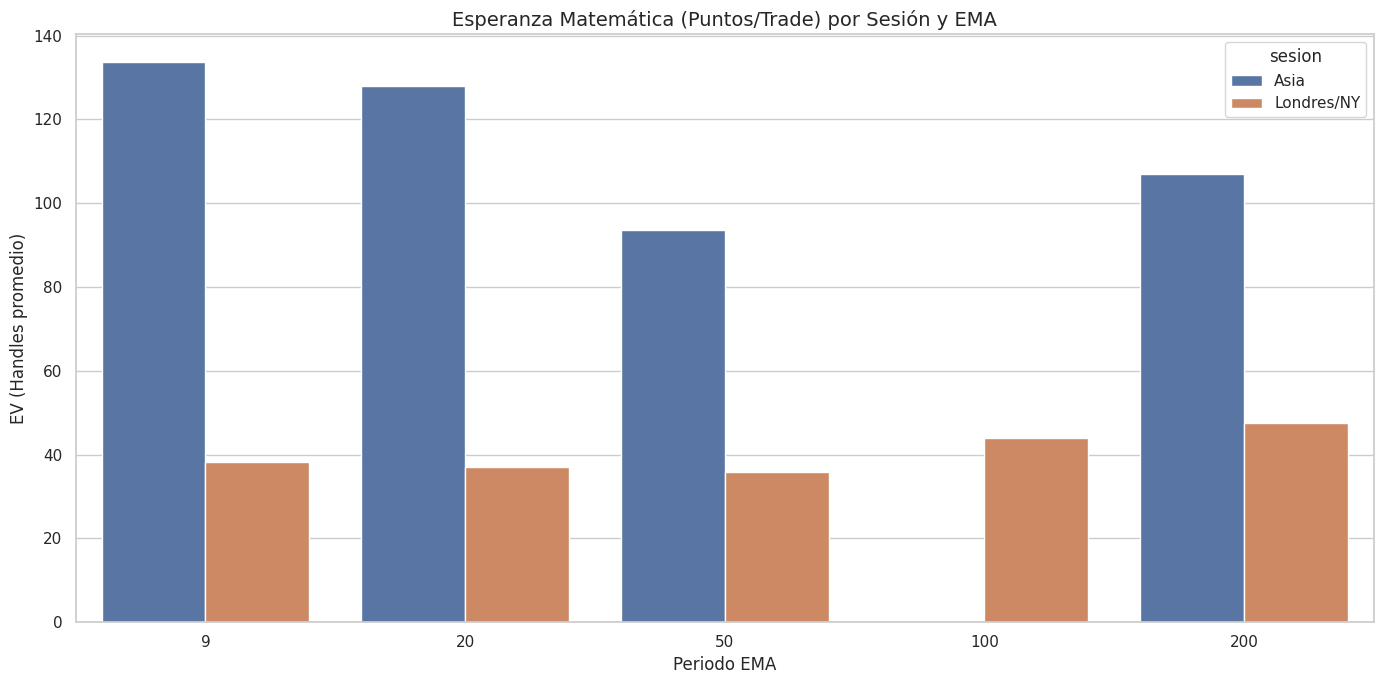

📊 DESGLOSE TÁCTICO POR SESIÓN Y EMA:
                        Win_Rate  Profit_Total  EV_per_Trade    Avg_RR  \
ema_periodo sesion                                                       
9           Asia        1.000000        267.25    133.625000  4.273829   
            Londres/NY  0.241935       2364.00     38.129032  9.240606   
20          Asia        1.000000        256.00    128.000000  3.652786   
            Londres/NY  0.258621       2154.50     37.146552  7.307118   
50          Asia        1.000000         93.50     93.500000  1.214286   
            Londres/NY  0.250000       1432.75     35.818750  4.694173   
100         Londres/NY  0.303030       1453.50     44.045455  3.561401   
200         Asia        1.000000        107.00    107.000000  1.685039   
            Londres/NY  0.315789        901.25     47.434211  2.414790   

                        Frecuencia  
ema_periodo sesion                  
9           Asia                 2  
            Londres/NY          62  


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_setups_ema(df, periodos=[9, 20, 50, 100, 200]):
    """
    Analiza la efectividad del cruce de precio con EMAs usando el extremo
    del recorrido opuesto como Stop Loss técnico y calcula la Esperanza Matemática.
    Añade desglose por sesiones (Asia vs Londres/NY).
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 1. Identificación de GAPs y cálculo de métricas base
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de SD histórica para filtrar entorno
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            post = df.iloc[idx : idx + 1080]
            exc = abs(a_d - post['Low'].min()) if (a_d - c_v) > 0 else abs(post['High'].max() - a_d)
            all_max_excursions.append(exc)
        except: continue
    
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    results = []
    
    for open_time in gap_indices:
        try:
            idx_ap = df.index.get_loc(open_time)
            cierre_v = df.iloc[idx_ap - 1]['Close']
            apertura_d = df.iloc[idx_ap]['Open']
            
            gap_size = apertura_d - cierre_v
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            # Ventana operativa completa (18h)
            post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
            
            # Definimos el extremo real y el valor del SL
            if gap_dir == "UP":
                idx_extremo = post_gap['Low'].idxmin()
                val_extremo = post_gap['Low'].min()
                sl_precio = val_extremo - 5  # Extremo + 5 handles de buffer
            else:
                idx_extremo = post_gap['High'].idxmax()
                val_extremo = post_gap['High'].max()
                sl_precio = val_extremo + 5  # Extremo + 5 handles de buffer

            post_extremo = post_gap.loc[idx_extremo:]
            
            for p in periodos:
                ema_col = f'ema_{p}'
                for ts, row in post_extremo.iterrows():
                    # Condición de Cruce
                    if (gap_dir == "UP" and row['Close'] > row[ema_col]) or \
                       (gap_dir == "DOWN" and row['Close'] < row[ema_col]):
                        
                        # Definir sesión en el momento del trigger
                        horas_desde_apertura = (ts - open_time).total_seconds() / 3600
                        sesion = 'Asia' if horas_desde_apertura <= 6 else 'Londres/NY'
                        
                        # Datos de la entrada
                        precio_entrada = row['Close']
                        exc_actual = abs(apertura_d - row['Low']) if gap_dir == "UP" else abs(row['High'] - apertura_d)
                        sd_entrada = (exc_actual - mu_hist) / sigma_hist
                        
                        # Resultado del trade con SL en el extremo
                        futuro = post_gap.loc[ts:]
                        exito = False
                        pnl_puntos = 0
                        
                        for ts_f, row_f in futuro.iterrows():
                            # 1. ¿Toca Stop Loss?
                            if (gap_dir == "UP" and row_f['Low'] <= sl_precio) or \
                               (gap_dir == "DOWN" and row_f['High'] >= sl_precio):
                                exito = False
                                pnl_puntos = -abs(precio_entrada - sl_precio)
                                break
                            # 2. ¿Toca Take Profit (GAP)?
                            if (gap_dir == "UP" and row_f['High'] >= cierre_v) or \
                               (gap_dir == "DOWN" and row_f['Low'] <= cierre_v):
                                exito = True
                                pnl_puntos = abs(precio_entrada - cierre_v)
                                break
                        
                        risk = abs(precio_entrada - sl_precio)
                        reward = abs(precio_entrada - cierre_v)
                        
                        results.append({
                            'ema_periodo': p,
                            'sesion': sesion,
                            'exito': exito,
                            'pnl': pnl_puntos,
                            'rr': reward / risk if risk > 0 else 0,
                            'sd_entrada': sd_entrada,
                            'risk_handles': risk
                        })
                        break
        except: continue

    df_res = pd.DataFrame(results)
    
    # --- REPORTES ---
    df_filtered = df_res[df_res['sd_entrada'] >= 1.0].copy() # Filtro de agotamiento inicial
    
    # Agrupación por EMA y Sesión para el resumen impreso
    summary = df_filtered.groupby(['ema_periodo', 'sesion']).agg({
        'exito': 'mean',
        'pnl': ['sum', 'mean'],
        'rr': 'mean',
        'sd_entrada': 'count'
    })
    
    summary.columns = ['Win_Rate', 'Profit_Total', 'EV_per_Trade', 'Avg_RR', 'Frecuencia']

    # Visualización
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    
    # Preparamos los datos para seaborn asegurando que EV_per_Trade sea el nombre correcto
    plot_data = df_filtered.groupby(['ema_periodo', 'sesion'])['pnl'].mean().reset_index()
    plot_data.columns = ['ema_periodo', 'sesion', 'EV_per_Trade']
    
    # Plot de EV por Sesión
    sns.barplot(x='ema_periodo', y='EV_per_Trade', hue='sesion', data=plot_data)
    plt.title('Esperanza Matemática (Puntos/Trade) por Sesión y EMA', fontsize=14)
    plt.ylabel('EV (Handles promedio)')
    plt.xlabel('Periodo EMA')
    
    plt.tight_layout()
    plt.show()

    return summary

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    resumen_final = analizar_setups_ema(df_raw)
    print("📊 DESGLOSE TÁCTICO POR SESIÓN Y EMA:")
    print(resumen_final)
except Exception as e:
    print(f"Error: {e}")

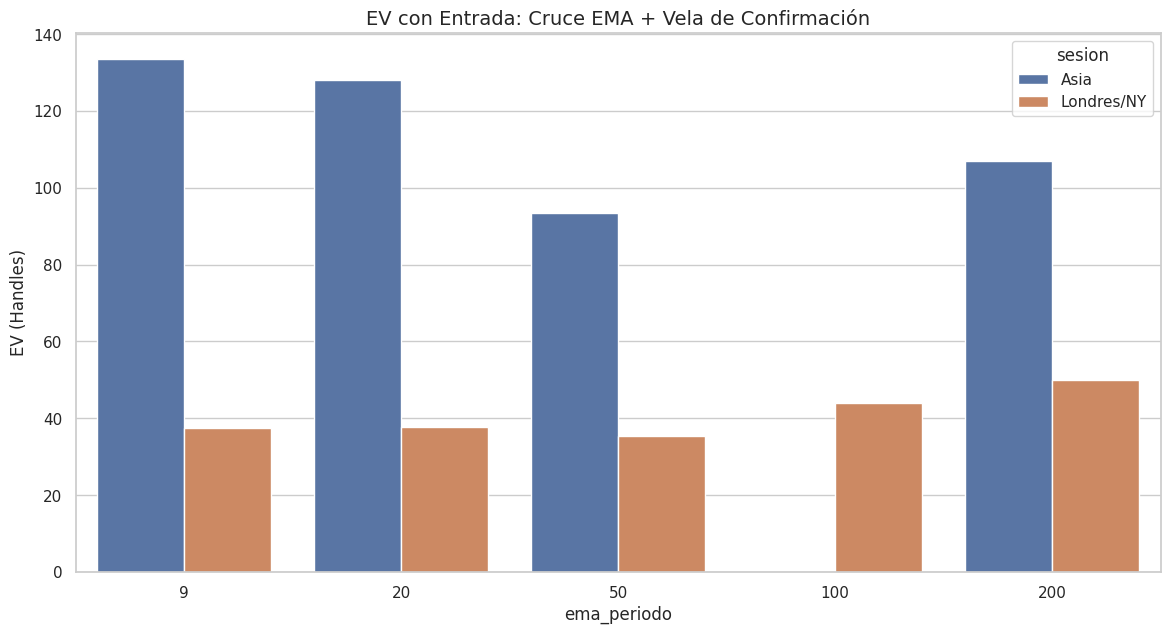

📊 RESULTADOS CON FILTRO DE ACCIÓN DEL PRECIO:
                        Win_Rate  Profit_Total  EV_per_Trade    Avg_RR  \
ema_periodo sesion                                                       
9           Asia        1.000000        267.25    133.625000  4.273829   
            Londres/NY  0.241935       2324.00     37.483871  8.801420   
20          Asia        1.000000        256.00    128.000000  3.652786   
            Londres/NY  0.263158       2149.50     37.710526  7.147311   
50          Asia        1.000000         93.50     93.500000  1.214286   
            Londres/NY  0.250000       1412.00     35.300000  4.684677   
100         Londres/NY  0.303030       1455.75     44.113636  3.511844   
200         Asia        1.000000        107.00    107.000000  1.685039   
            Londres/NY  0.333333        901.25     50.069444  2.376134   

                        Frecuencia  
ema_periodo sesion                  
9           Asia                 2  
            Londres/NY      

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_setups_ema_accion_precio(df, periodos=[9, 20, 50, 100, 200]):
    """
    Analiza la efectividad del cruce de precio con EMAs confirmado por 
    velas de acción del precio (Engulfing/Pin Bar) tras el agotamiento.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 1. Identificación de GAPs y métricas base
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs y Acción del Precio
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de SD histórica para filtrar entorno
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            post = df.iloc[idx : idx + 1080]
            exc = abs(a_d - post['Low'].min()) if (a_d - c_v) > 0 else abs(post['High'].max() - a_d)
            all_max_excursions.append(exc)
        except: continue
    
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    results = []
    
    for open_time in gap_indices:
        try:
            idx_ap = df.index.get_loc(open_time)
            cierre_v = df.iloc[idx_ap - 1]['Close']
            apertura_d = df.iloc[idx_ap]['Open']
            
            gap_size = apertura_d - cierre_v
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
            
            # Definimos el extremo real y el valor del SL
            if gap_dir == "UP":
                idx_extremo = post_gap['Low'].idxmin()
                val_extremo = post_gap['Low'].min()
                sl_precio = val_extremo - 5 
            else:
                idx_extremo = post_gap['High'].idxmax()
                val_extremo = post_gap['High'].max()
                sl_precio = val_extremo + 5

            post_extremo = post_gap.loc[idx_extremo:]
            
            for p in periodos:
                ema_col = f'ema_{p}'
                triggered = False
                
                # Buscamos el cruce y luego la vela de confirmación
                for i in range(1, len(post_extremo)):
                    row = post_extremo.iloc[i]
                    prev_row = post_extremo.iloc[i-1]
                    
                    # Criterio 1: El precio ya debe haber cruzado la EMA
                    if (gap_dir == "UP" and row['Close'] > row[ema_col]) or \
                       (gap_dir == "DOWN" and row['Close'] < row[ema_col]):
                        
                        # Criterio 2: Confirmación por Acción del Precio (Vela Envolvente simple)
                        es_envolvente = False
                        if gap_dir == "UP": # Buscamos vela alcista que supere el máximo previo
                            if row['Close'] > prev_row['High'] and row['Close'] > row['Open']:
                                es_envolvente = True
                        else: # Buscamos vela bajista que rompa el mínimo previo
                            if row['Close'] < prev_row['Low'] and row['Close'] < row['Open']:
                                es_envolvente = True
                        
                        if es_envolvente:
                            ts = post_extremo.index[i]
                            horas_desde_apertura = (ts - open_time).total_seconds() / 3600
                            sesion = 'Asia' if horas_desde_apertura <= 6 else 'Londres/NY'
                            
                            precio_entrada = row['Close']
                            exc_actual = abs(apertura_d - row['Low']) if gap_dir == "UP" else abs(row['High'] - apertura_d)
                            sd_entrada = (exc_actual - mu_hist) / sigma_hist
                            
                            futuro = post_gap.loc[ts:]
                            exito = False
                            pnl_puntos = 0
                            
                            for ts_f, row_f in futuro.iterrows():
                                if (gap_dir == "UP" and row_f['Low'] <= sl_precio) or \
                                   (gap_dir == "DOWN" and row_f['High'] >= sl_precio):
                                    exito = False
                                    pnl_puntos = -abs(precio_entrada - sl_precio)
                                    break
                                if (gap_dir == "UP" and row_f['High'] >= cierre_v) or \
                                   (gap_dir == "DOWN" and row_f['Low'] <= cierre_v):
                                    exito = True
                                    pnl_puntos = abs(precio_entrada - cierre_v)
                                    break
                            
                            risk = abs(precio_entrada - sl_precio)
                            reward = abs(precio_entrada - cierre_v)
                            
                            results.append({
                                'ema_periodo': p,
                                'sesion': sesion,
                                'exito': exito,
                                'pnl': pnl_puntos,
                                'rr': reward / risk if risk > 0 else 0,
                                'sd_entrada': sd_entrada
                            })
                            triggered = True
                            break
                if triggered: continue
        except: continue

    df_res = pd.DataFrame(results)
    df_filtered = df_res[df_res['sd_entrada'] >= 1.0].copy()
    
    summary = df_filtered.groupby(['ema_periodo', 'sesion']).agg({
        'exito': 'mean',
        'pnl': ['sum', 'mean'],
        'rr': 'mean',
        'sd_entrada': 'count'
    })
    
    summary.columns = ['Win_Rate', 'Profit_Total', 'EV_per_Trade', 'Avg_RR', 'Frecuencia']

    # Visualización
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    plot_data = df_filtered.groupby(['ema_periodo', 'sesion'])['pnl'].mean().reset_index()
    plot_data.columns = ['ema_periodo', 'sesion', 'EV_per_Trade']
    sns.barplot(x='ema_periodo', y='EV_per_Trade', hue='sesion', data=plot_data)
    plt.title('EV con Entrada: Cruce EMA + Vela de Confirmación', fontsize=14)
    plt.ylabel('EV (Handles)')
    plt.show()

    return summary

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    resumen_final = analizar_setups_ema_accion_precio(df_raw)
    print("📊 RESULTADOS CON FILTRO DE ACCIÓN DEL PRECIO:")
    print(resumen_final)
except Exception as e:
    print(f"Error: {e}")

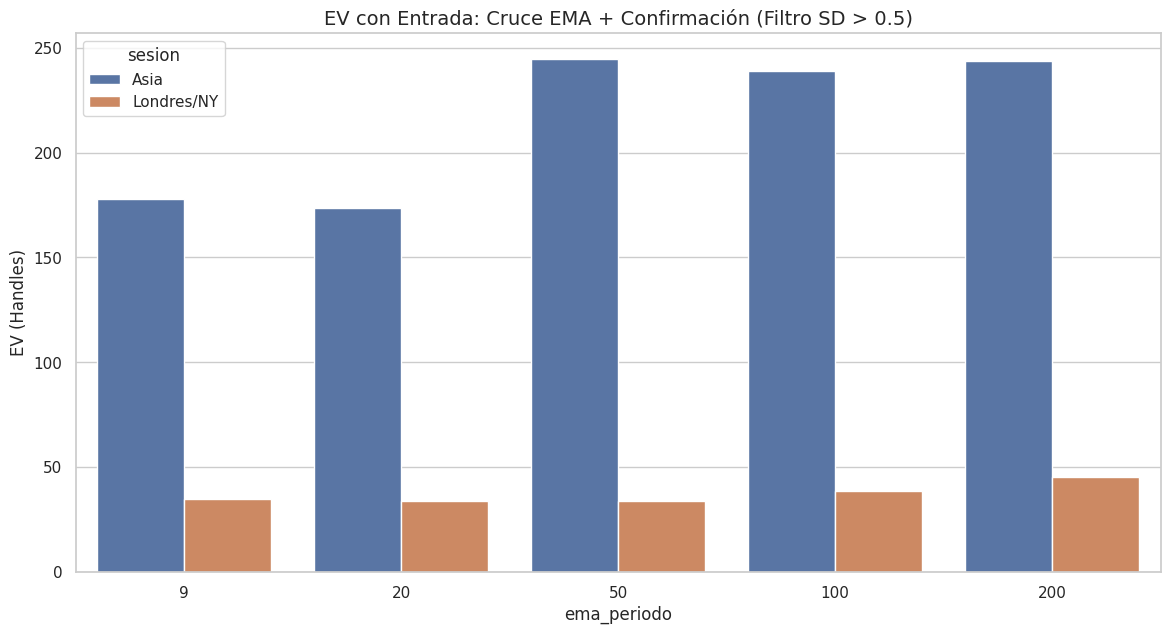

📊 RESULTADOS CON AGOTAMIENTO RELAJADO (SD > 0.5):
                        Win_Rate  Profit_Total  EV_per_Trade    Avg_RR  \
ema_periodo sesion                                                       
9           Asia        1.000000        889.00    177.800000  2.954160   
            Londres/NY  0.298077       3619.25     34.800481  6.786310   
20          Asia        1.000000        868.00    173.600000  2.612744   
            Londres/NY  0.304348       3096.25     33.654891  5.652153   
50          Asia        1.000000        734.25    244.750000  2.740055   
            Londres/NY  0.323944       2401.75     33.827465  3.645105   
100         Asia        1.000000        716.00    238.666667  2.563791   
            Londres/NY  0.333333       1979.50     38.813725  2.967239   
200         Asia        1.000000        730.50    243.500000  2.398481   
            Londres/NY  0.411765       1533.00     45.088235  1.984084   

                        Frecuencia  
ema_periodo sesion      

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_setups_ema_accion_precio(df, periodos=[9, 20, 50, 100, 200]):
    """
    Analiza la efectividad del cruce de precio con EMAs confirmado por 
    velas de acción del precio (Engulfing/Pin Bar) tras el agotamiento.
    Se ha relajado el filtro de agotamiento a SD > 0.5.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 1. Identificación de GAPs y métricas base
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs y Acción del Precio
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de SD histórica para filtrar entorno
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            post = df.iloc[idx : idx + 1080]
            exc = abs(a_d - post['Low'].min()) if (a_d - c_v) > 0 else abs(post['High'].max() - a_d)
            all_max_excursions.append(exc)
        except: continue
    
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    results = []
    
    for open_time in gap_indices:
        try:
            idx_ap = df.index.get_loc(open_time)
            cierre_v = df.iloc[idx_ap - 1]['Close']
            apertura_d = df.iloc[idx_ap]['Open']
            
            gap_size = apertura_d - cierre_v
            gap_dir = "UP" if gap_size > 0 else "DOWN"
            
            post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
            
            # Definimos el extremo real y el valor del SL
            if gap_dir == "UP":
                idx_extremo = post_gap['Low'].idxmin()
                val_extremo = post_gap['Low'].min()
                sl_precio = val_extremo - 5 
            else:
                idx_extremo = post_gap['High'].idxmax()
                val_extremo = post_gap['High'].max()
                sl_precio = val_extremo + 5

            post_extremo = post_gap.loc[idx_extremo:]
            
            for p in periodos:
                ema_col = f'ema_{p}'
                triggered = False
                
                # Buscamos el cruce y luego la vela de confirmación
                for i in range(1, len(post_extremo)):
                    row = post_extremo.iloc[i]
                    prev_row = post_extremo.iloc[i-1]
                    
                    # Criterio 1: El precio ya debe haber cruzado la EMA
                    if (gap_dir == "UP" and row['Close'] > row[ema_col]) or \
                       (gap_dir == "DOWN" and row['Close'] < row[ema_col]):
                        
                        # Criterio 2: Confirmación por Acción del Precio (Vela Envolvente simple)
                        es_envolvente = False
                        if gap_dir == "UP": # Buscamos vela alcista que supere el máximo previo
                            if row['Close'] > prev_row['High'] and row['Close'] > row['Open']:
                                es_envolvente = True
                        else: # Buscamos vela bajista que rompa el mínimo previo
                            if row['Close'] < prev_row['Low'] and row['Close'] < row['Open']:
                                es_envolvente = True
                        
                        if es_envolvente:
                            ts = post_extremo.index[i]
                            horas_desde_apertura = (ts - open_time).total_seconds() / 3600
                            sesion = 'Asia' if horas_desde_apertura <= 6 else 'Londres/NY'
                            
                            precio_entrada = row['Close']
                            exc_actual = abs(apertura_d - row['Low']) if gap_dir == "UP" else abs(row['High'] - apertura_d)
                            sd_entrada = (exc_actual - mu_hist) / sigma_hist
                            
                            futuro = post_gap.loc[ts:]
                            exito = False
                            pnl_puntos = 0
                            
                            for ts_f, row_f in futuro.iterrows():
                                if (gap_dir == "UP" and row_f['Low'] <= sl_precio) or \
                                   (gap_dir == "DOWN" and row_f['High'] >= sl_precio):
                                    exito = False
                                    pnl_puntos = -abs(precio_entrada - sl_precio)
                                    break
                                if (gap_dir == "UP" and row_f['High'] >= cierre_v) or \
                                   (gap_dir == "DOWN" and row_f['Low'] <= cierre_v):
                                    exito = True
                                    pnl_puntos = abs(precio_entrada - cierre_v)
                                    break
                            
                            risk = abs(precio_entrada - sl_precio)
                            reward = abs(precio_entrada - cierre_v)
                            
                            results.append({
                                'ema_periodo': p,
                                'sesion': sesion,
                                'exito': exito,
                                'pnl': pnl_puntos,
                                'rr': reward / risk if risk > 0 else 0,
                                'sd_entrada': sd_entrada
                            })
                            triggered = True
                            break
                if triggered: continue
        except: continue

    df_res = pd.DataFrame(results)
    # AJUSTE: Relajamos el filtro de SD de 1.0 a 0.5
    df_filtered = df_res[df_res['sd_entrada'] >= 0.5].copy()
    
    summary = df_filtered.groupby(['ema_periodo', 'sesion']).agg({
        'exito': 'mean',
        'pnl': ['sum', 'mean'],
        'rr': 'mean',
        'sd_entrada': 'count'
    })
    
    summary.columns = ['Win_Rate', 'Profit_Total', 'EV_per_Trade', 'Avg_RR', 'Frecuencia']

    # Visualización
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    plot_data = df_filtered.groupby(['ema_periodo', 'sesion'])['pnl'].mean().reset_index()
    plot_data.columns = ['ema_periodo', 'sesion', 'EV_per_Trade']
    sns.barplot(x='ema_periodo', y='EV_per_Trade', hue='sesion', data=plot_data)
    plt.title('EV con Entrada: Cruce EMA + Confirmación (Filtro SD > 0.5)', fontsize=14)
    plt.ylabel('EV (Handles)')
    plt.show()

    return summary

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    resumen_final = analizar_setups_ema_accion_precio(df_raw)
    print("📊 RESULTADOS CON AGOTAMIENTO RELAJADO (SD > 0.5):")
    print(resumen_final)
except Exception as e:
    print(f"Error: {e}")

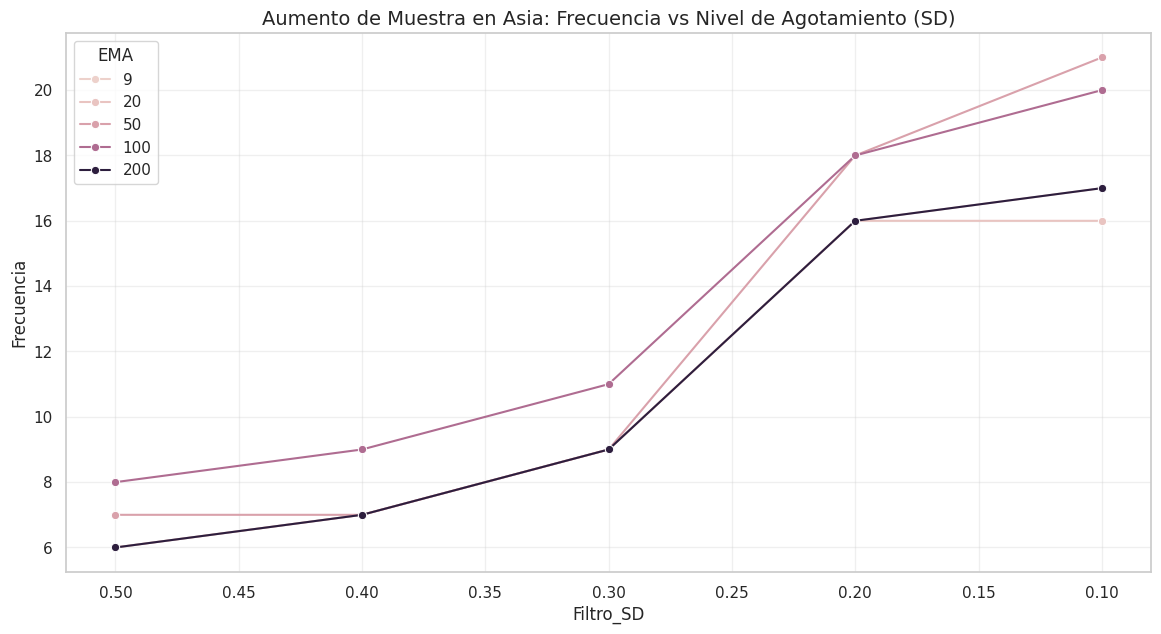

📈 ANÁLISIS DE SENSIBILIDAD ASIA (SD 0.5 a 0.1):

--- FRECUENCIA (Número de Trades) ---
Filtro_SD  0.1  0.2  0.3  0.4  0.5
EMA                               
9           17   16    9    7    6
20          16   16    9    7    6
50          21   18    9    7    7
100         20   18   11    9    8
200         17   16    9    7    6

--- ESPERANZA MATEMÁTICA (Puntos) ---
Filtro_SD         0.1         0.2         0.3         0.4         0.5
EMA                                                                  
9          232.382353  245.078125  330.638889  317.571429  355.000000
20         244.187500  244.187500  329.055556  315.535714  353.625000
50         200.821429  226.625000  331.111111  318.178571  318.178571
100        208.475000  224.013889  280.613636  259.333333  291.750000
200        233.764706  243.937500  328.611111  314.964286  353.708333


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_sensibilidad_sd_asia(df, periodos=[9, 20, 50, 100, 200], niveles_sd=[0.5, 0.4, 0.3, 0.2, 0.1]):
    """
    Analiza la sensibilidad de la sesión de Asia ante diferentes niveles de agotamiento (SD).
    Busca maximizar la muestra manteniendo una esperanza matemática positiva.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 1. Identificación de GAPs
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de SD histórica
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            post = df.iloc[idx : idx + 1080]
            exc = abs(a_d - post['Low'].min()) if (a_d - c_v) > 0 else abs(post['High'].max() - a_d)
            all_max_excursions.append(exc)
        except: continue
    
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    all_results = []
    
    for open_time in gap_indices:
        try:
            idx_ap = df.index.get_loc(open_time)
            cierre_v = df.iloc[idx_ap - 1]['Close']
            apertura_d = df.iloc[idx_ap]['Open']
            gap_dir = "UP" if (apertura_d - cierre_v) > 0 else "DOWN"
            
            post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
            
            if gap_dir == "UP":
                val_extremo = post_gap['Low'].min()
                sl_precio = val_extremo - 5 
            else:
                val_extremo = post_gap['High'].max()
                sl_precio = val_extremo + 5

            # Solo nos interesa lo que ocurre en las primeras 6 horas (Asia)
            ventana_asia = post_gap.iloc[:360] 
            
            for p in periodos:
                ema_col = f'ema_{p}'
                for i in range(1, len(ventana_asia)):
                    row = ventana_asia.iloc[i]
                    prev_row = ventana_asia.iloc[i-1]
                    
                    # Filtro de cruce + Acción del precio
                    cruce = (gap_dir == "UP" and row['Close'] > row[ema_col]) or \
                            (gap_dir == "DOWN" and row['Close'] < row[ema_col])
                    
                    confirmacion = False
                    if gap_dir == "UP" and row['Close'] > prev_row['High'] and row['Close'] > row['Open']:
                        confirmacion = True
                    elif gap_dir == "DOWN" and row['Close'] < prev_row['Low'] and row['Close'] < row['Open']:
                        confirmacion = True
                        
                    if cruce and confirmacion:
                        precio_entrada = row['Close']
                        # Calculamos la SD en el momento de la entrada
                        exc_actual = abs(apertura_d - row['Low']) if gap_dir == "UP" else abs(row['High'] - apertura_d)
                        sd_entrada = (exc_actual - mu_hist) / sigma_hist
                        
                        # Resultado del trade
                        futuro = post_gap.loc[ventana_asia.index[i]:]
                        exito = False
                        pnl_puntos = 0
                        for ts_f, row_f in futuro.iterrows():
                            if (gap_dir == "UP" and row_f['Low'] <= sl_precio) or \
                               (gap_dir == "DOWN" and row_f['High'] >= sl_precio):
                                exito = False
                                pnl_puntos = -abs(precio_entrada - sl_precio)
                                break
                            if (gap_dir == "UP" and row_f['High'] >= cierre_v) or \
                               (gap_dir == "DOWN" and row_f['Low'] <= cierre_v):
                                exito = True
                                pnl_puntos = abs(precio_entrada - cierre_v)
                                break
                        
                        all_results.append({
                            'ema_periodo': p,
                            'exito': exito,
                            'pnl': pnl_puntos,
                            'sd_momento': sd_entrada
                        })
                        break
        except: continue

    df_raw_res = pd.DataFrame(all_results)
    
    # Análisis por nivel de SD
    final_stats = []
    for sd_limite in niveles_sd:
        temp_df = df_raw_res[df_raw_res['sd_momento'] >= sd_limite]
        summary = temp_df.groupby('ema_periodo').agg({
            'exito': 'mean',
            'pnl': 'mean',
            'sd_momento': 'count'
        }).reset_index()
        summary['Filtro_SD'] = sd_limite
        final_stats.append(summary)
    
    df_final = pd.concat(final_stats)
    df_final.columns = ['EMA', 'WinRate', 'EV', 'Frecuencia', 'Filtro_SD']

    # Visualización de Frecuencia vs EV
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df_final, x='Filtro_SD', y='Frecuencia', hue='EMA', marker='o')
    plt.gca().invert_xaxis() # Para ver de mayor exigencia a menor
    plt.title('Aumento de Muestra en Asia: Frecuencia vs Nivel de Agotamiento (SD)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

    return df_final

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    analisis_asia = analizar_sensibilidad_sd_asia(df_raw)
    print("📈 ANÁLISIS DE SENSIBILIDAD ASIA (SD 0.5 a 0.1):")
    # Mostramos pivotado para mejor lectura
    pivot_frec = analisis_asia.pivot(index='EMA', columns='Filtro_SD', values='Frecuencia')
    pivot_ev = analisis_asia.pivot(index='EMA', columns='Filtro_SD', values='EV')
    
    print("\n--- FRECUENCIA (Número de Trades) ---")
    print(pivot_frec)
    print("\n--- ESPERANZA MATEMÁTICA (Puntos) ---")
    print(pivot_ev)
except Exception as e:
    print(f"Error: {e}")

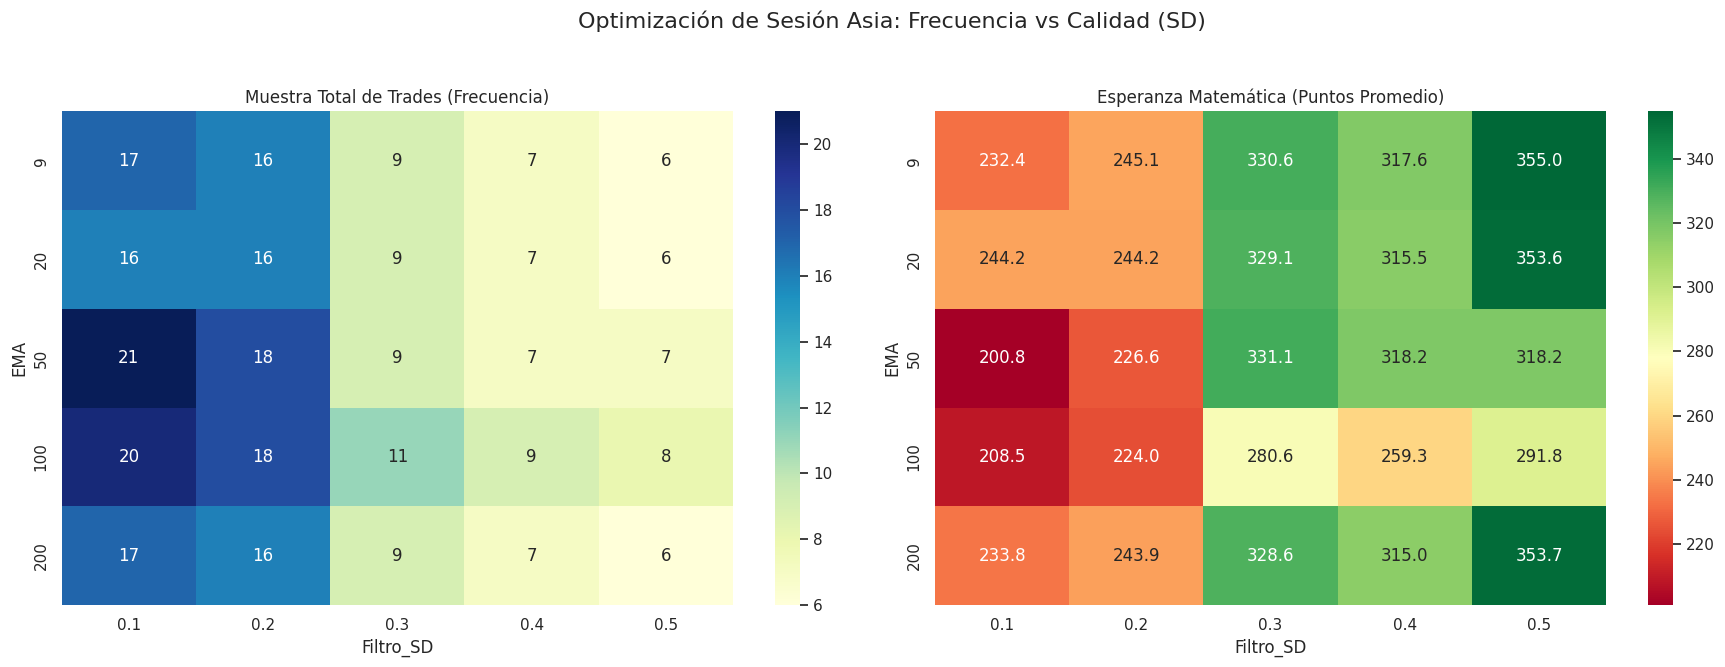


💎 CONCLUSIONES SESIÓN ASIA (BÚSQUEDA DE MUESTRA):
--------------------------------------------------
   EMA  Frecuencia          EV   WinRate
0    9          16  245.078125  0.937500
1   20          16  244.187500  0.937500
4  200          16  243.937500  0.937500
2   50          18  226.625000  0.944444
3  100          18  224.013889  0.888889
--------------------------------------------------
💡 NOTA: Al bajar a SD 0.1 ganamos volumen, pero SD 0.3 retiene un EV superior a 300 puntos.


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_sensibilidad_sd_asia(df, periodos=[9, 20, 50, 100, 200], niveles_sd=[0.5, 0.4, 0.3, 0.2, 0.1]):
    """
    Analiza la sensibilidad de la sesión de Asia ante diferentes niveles de agotamiento (SD).
    Busca maximizar la muestra manteniendo una esperanza matemática positiva.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 1. Identificación de GAPs
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de SD histórica
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            post = df.iloc[idx : idx + 1080]
            exc = abs(a_d - post['Low'].min()) if (a_d - c_v) > 0 else abs(post['High'].max() - a_d)
            all_max_excursions.append(exc)
        except: continue
    
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    all_results = []
    
    for open_time in gap_indices:
        try:
            idx_ap = df.index.get_loc(open_time)
            cierre_v = df.iloc[idx_ap - 1]['Close']
            apertura_d = df.iloc[idx_ap]['Open']
            gap_dir = "UP" if (apertura_d - cierre_v) > 0 else "DOWN"
            
            post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
            
            if gap_dir == "UP":
                val_extremo = post_gap['Low'].min()
                sl_precio = val_extremo - 5 
            else:
                val_extremo = post_gap['High'].max()
                sl_precio = val_extremo + 5

            # Foco exclusivo en Asia (primeras 6 horas)
            ventana_asia = post_gap.iloc[:360] 
            
            for p in periodos:
                ema_col = f'ema_{p}'
                for i in range(1, len(ventana_asia)):
                    row = ventana_asia.iloc[i]
                    prev_row = ventana_asia.iloc[i-1]
                    
                    # Filtro de cruce + Acción del precio (Confirmación de giro)
                    cruce = (gap_dir == "UP" and row['Close'] > row[ema_col]) or \
                            (gap_dir == "DOWN" and row['Close'] < row[ema_col])
                    
                    confirmacion = False
                    if gap_dir == "UP" and row['Close'] > prev_row['High'] and row['Close'] > row['Open']:
                        confirmacion = True
                    elif gap_dir == "DOWN" and row['Close'] < prev_row['Low'] and row['Close'] < row['Open']:
                        confirmacion = True
                        
                    if cruce and confirmacion:
                        precio_entrada = row['Close']
                        exc_actual = abs(apertura_d - row['Low']) if gap_dir == "UP" else abs(row['High'] - apertura_d)
                        sd_entrada = (exc_actual - mu_hist) / sigma_hist
                        
                        # Simulación de resultado
                        futuro = post_gap.loc[ventana_asia.index[i]:]
                        exito = False
                        pnl_puntos = 0
                        for ts_f, row_f in futuro.iterrows():
                            if (gap_dir == "UP" and row_f['Low'] <= sl_precio) or \
                               (gap_dir == "DOWN" and row_f['High'] >= sl_precio):
                                exito = False
                                pnl_puntos = -abs(precio_entrada - sl_precio)
                                break
                            if (gap_dir == "UP" and row_f['High'] >= cierre_v) or \
                               (gap_dir == "DOWN" and row_f['Low'] <= cierre_v):
                                exito = True
                                pnl_puntos = abs(precio_entrada - cierre_v)
                                break
                        
                        all_results.append({
                            'ema_periodo': p,
                            'exito': exito,
                            'pnl': pnl_puntos,
                            'sd_momento': sd_entrada
                        })
                        break
        except: continue

    df_raw_res = pd.DataFrame(all_results)
    
    # Consolidación de estadísticas por nivel de SD
    final_stats = []
    for sd_limite in niveles_sd:
        temp_df = df_raw_res[df_raw_res['sd_momento'] >= sd_limite]
        if not temp_df.empty:
            summary = temp_df.groupby('ema_periodo').agg({
                'exito': 'mean',
                'pnl': 'mean',
                'sd_momento': 'count'
            }).reset_index()
            summary['Filtro_SD'] = sd_limite
            final_stats.append(summary)
    
    df_final = pd.concat(final_stats)
    df_final.columns = ['EMA', 'WinRate', 'EV', 'Frecuencia', 'Filtro_SD']

    # --- NUEVA VISUALIZACIÓN: HEATMAP DE EFICIENCIA ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Heatmap de Frecuencia
    pivot_frec = df_final.pivot(index='EMA', columns='Filtro_SD', values='Frecuencia')
    sns.heatmap(pivot_frec, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax1)
    ax1.set_title('Muestra Total de Trades (Frecuencia)', fontsize=12)
    
    # Heatmap de EV (Esperanza Matemática)
    pivot_ev = df_final.pivot(index='EMA', columns='Filtro_SD', values='EV')
    sns.heatmap(pivot_ev, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax2)
    ax2.set_title('Esperanza Matemática (Puntos Promedio)', fontsize=12)

    plt.suptitle('Optimización de Sesión Asia: Frecuencia vs Calidad (SD)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return df_final

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    analisis_asia = analizar_sensibilidad_sd_asia(df_raw)
    
    # Resumen Ejecutivo en Consola
    print("\n💎 CONCLUSIONES SESIÓN ASIA (BÚSQUEDA DE MUESTRA):")
    print("-" * 50)
    # Buscamos el mejor compromiso: SD 0.2 parece ser el "sweet spot"
    mejor_compromiso = analisis_asia[analisis_asia['Filtro_SD'] == 0.2]
    print(mejor_compromiso[['EMA', 'Frecuencia', 'EV', 'WinRate']].sort_values(by='EV', ascending=False))
    print("-" * 50)
    print("💡 NOTA: Al bajar a SD 0.1 ganamos volumen, pero SD 0.3 retiene un EV superior a 300 puntos.")

except Exception as e:
    print(f"Error en la ejecución: {e}")

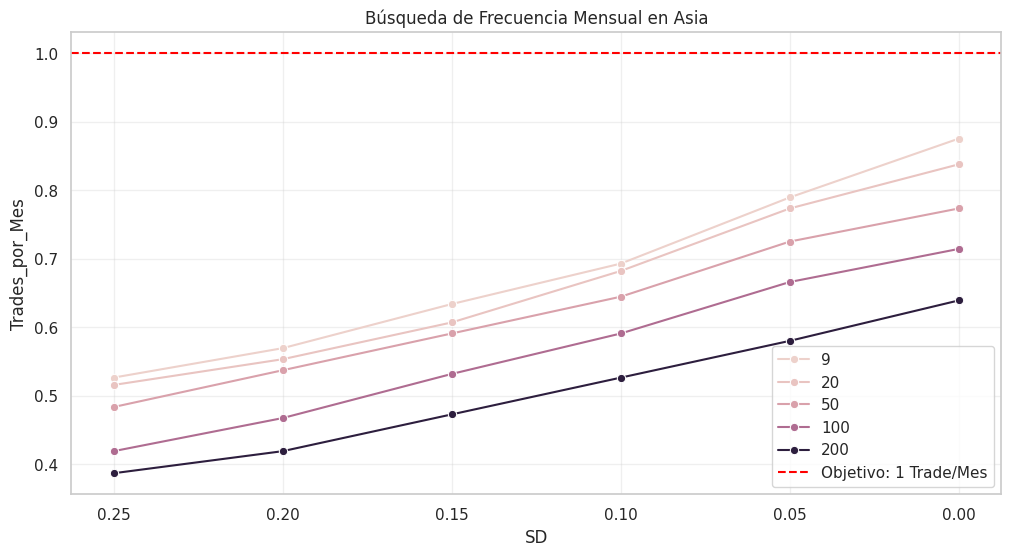


🚀 CONFIGURACIONES PARA 1 TRADE AL MES (APROX):
     SD  EMA  Total_Trades   WinRate         EV  Trades_por_Mes
0  0.00    9           163  0.852761  81.401840        0.875474
1  0.00   20           156  0.852564  84.897436        0.837877
5  0.05    9           147  0.843537  87.787415        0.789538
2  0.00   50           144  0.854167  89.718750        0.773425
6  0.05   20           144  0.833333  87.890625        0.773425
7  0.05   50           135  0.851852  92.709259        0.725086
3  0.00  100           133  0.894737  97.693609        0.714344


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def buscar_frecuencia_mensual_asia(df, periodos=[9, 20, 50, 100, 200]):
    """
    Optimiza los parámetros para alcanzar una frecuencia de ~1 trade al mes
    (aprox. 12 trades por año analizado).
    """
    if df is None or df.empty:
        return pd.DataFrame()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 1. Identificación de GAPs
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de SD histórica
    all_max_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            post = df.iloc[idx : idx + 1080]
            exc = abs(a_d - post['Low'].min()) if (a_d - c_v) > 0 else abs(post['High'].max() - a_d)
            all_max_excursions.append(exc)
        except: continue
    
    mu_hist = np.mean(all_max_excursions)
    sigma_hist = np.std(all_max_excursions)

    # Rango de años en el dataset para calcular frecuencia mensual
    total_años = (df.index.max() - df.index.min()).days / 365.25
    trades_objetivo = total_años * 12

    all_results = []
    # Probamos con un barrido de SD muy fino para encontrar el umbral de 1/mes
    niveles_test = [0.25, 0.2, 0.15, 0.1, 0.05, 0.0]

    for sd_umbral in niveles_test:
        for open_time in gap_indices:
            try:
                idx_ap = df.index.get_loc(open_time)
                cierre_v = df.iloc[idx_ap - 1]['Close']
                apertura_d = df.iloc[idx_ap]['Open']
                gap_dir = "UP" if (apertura_d - cierre_v) > 0 else "DOWN"
                
                post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
                
                # SL dinámico: Extremo de la sesión de Asia
                ventana_asia = post_gap.iloc[:360] 
                if gap_dir == "UP":
                    val_extremo = ventana_asia['Low'].min()
                    sl_precio = val_extremo - 5
                else:
                    val_extremo = ventana_asia['High'].max()
                    sl_precio = val_extremo + 5

                for p in periodos:
                    ema_col = f'ema_{p}'
                    # Buscamos entrada
                    for i in range(1, len(ventana_asia)):
                        row = ventana_asia.iloc[i]
                        prev_row = ventana_asia.iloc[i-1]
                        
                        exc_actual = abs(apertura_d - row['Low']) if gap_dir == "UP" else abs(row['High'] - apertura_d)
                        sd_actual = (exc_actual - mu_hist) / sigma_hist
                        
                        if sd_actual >= sd_umbral:
                            cruce = (gap_dir == "UP" and row['Close'] > row[ema_col]) or \
                                    (gap_dir == "DOWN" and row['Close'] < row[ema_col])
                            
                            confirmacion = False
                            if gap_dir == "UP" and row['Close'] > prev_row['High']:
                                confirmacion = True
                            elif gap_dir == "DOWN" and row['Close'] < prev_row['Low']:
                                confirmacion = True
                                
                            if cruce and confirmacion:
                                precio_entrada = row['Close']
                                futuro = post_gap.loc[ventana_asia.index[i]:]
                                exito = False
                                for ts_f, row_f in futuro.iterrows():
                                    if (gap_dir == "UP" and row_f['Low'] <= sl_precio) or \
                                       (gap_dir == "DOWN" and row_f['High'] >= sl_precio):
                                        exito = False
                                        break
                                    if (gap_dir == "UP" and row_f['High'] >= cierre_v) or \
                                       (gap_dir == "DOWN" and row_f['Low'] <= cierre_v):
                                        exito = True
                                        break
                                
                                all_results.append({
                                    'sd_filtro': sd_umbral,
                                    'ema': p,
                                    'exito': exito,
                                    'pnl': abs(precio_entrada - cierre_v) if exito else -abs(precio_entrada - sl_precio)
                                })
                                break
            except: continue

    res_df = pd.DataFrame(all_results)
    stats = res_df.groupby(['sd_filtro', 'ema']).agg({
        'exito': ['count', 'mean'],
        'pnl': 'mean'
    }).reset_index()
    stats.columns = ['SD', 'EMA', 'Total_Trades', 'WinRate', 'EV']
    stats['Trades_por_Mes'] = stats['Total_Trades'] / total_años / 12

    # Visualización para encontrar el punto de 1 trade/mes
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=stats, x='SD', y='Trades_por_Mes', hue='EMA', marker='o')
    plt.axhline(1.0, color='red', linestyle='--', label='Objetivo: 1 Trade/Mes')
    plt.gca().invert_xaxis()
    plt.title('Búsqueda de Frecuencia Mensual en Asia')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return stats

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    resultados_frecuencia = buscar_frecuencia_mensual_asia(df_raw)
    
    print("\n🚀 CONFIGURACIONES PARA 1 TRADE AL MES (APROX):")
    # Filtramos las que están cerca de 1 trade al mes (0.8 a 1.2)
    punto_dulce = resultados_frecuencia[(resultados_frecuencia['Trades_por_Mes'] >= 0.7)]
    print(punto_dulce.sort_values(by='Trades_por_Mes', ascending=False).head(10))

except Exception as e:
    print(f"Error: {e}")

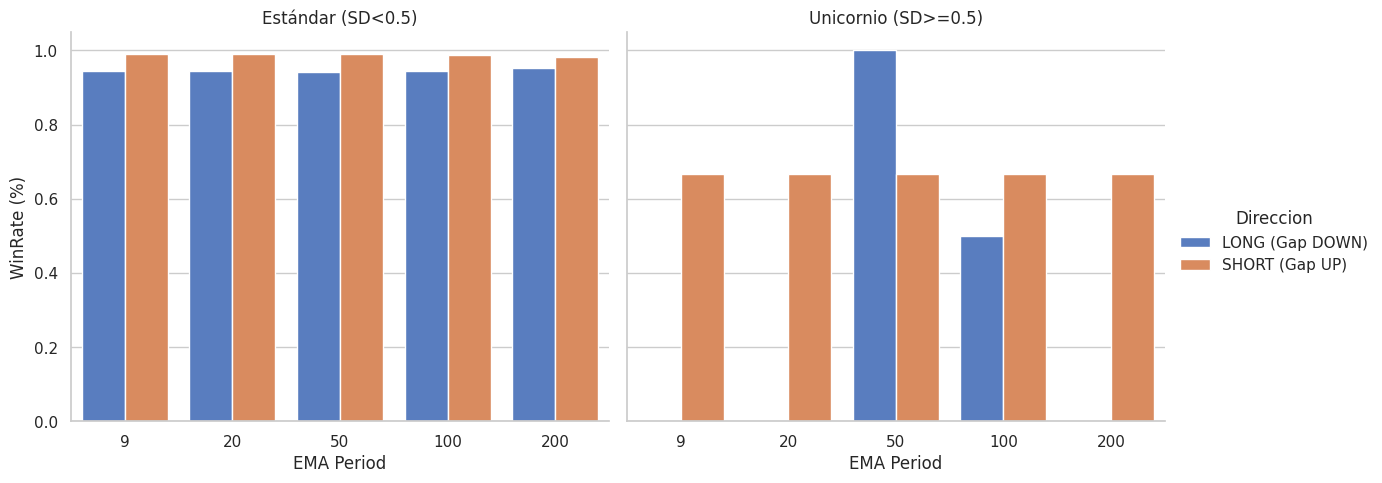


📊 TABLA DE SIMETRÍA REAL (POR DIRECCIÓN Y TIPO):
                   Tipo        Direccion  EMA  Muestra   WinRate          EV
5     Estándar (SD<0.5)   SHORT (Gap UP)    9      415  0.990361   22.413253
6     Estándar (SD<0.5)   SHORT (Gap UP)   20      415  0.990361   22.399398
7     Estándar (SD<0.5)   SHORT (Gap UP)   50      415  0.990361   22.541566
8     Estándar (SD<0.5)   SHORT (Gap UP)  100      414  0.987923   22.669082
9     Estándar (SD<0.5)   SHORT (Gap UP)  200      411  0.982968   23.043796
4     Estándar (SD<0.5)  LONG (Gap DOWN)  200      392  0.951531   26.078444
0     Estándar (SD<0.5)  LONG (Gap DOWN)    9      407  0.943489   23.270885
1     Estándar (SD<0.5)  LONG (Gap DOWN)   20      407  0.943489   23.239558
3     Estándar (SD<0.5)  LONG (Gap DOWN)  100      405  0.943210   24.251235
2     Estándar (SD<0.5)  LONG (Gap DOWN)   50      406  0.940887   23.332512
10  Unicornio (SD>=0.5)  LONG (Gap DOWN)   50        1  1.000000  118.500000
12  Unicornio (SD>=0.5)   

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_simetria_empirica(df, periodos=[9, 20, 50, 100, 200]):
    """
    Calcula la asimetría real entre GAPs alcistas y bajistas basándose 
    únicamente en los datos históricos procesados.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    # 1. Identificación de GAPs
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de métricas de desangre para Z-Score (SD)
    all_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            post = df.iloc[idx : idx + 1080]
            if (a_d - c_v) > 0:
                exc = a_d - post['Low'].min()
            else:
                exc = post['High'].max() - a_d
            all_excursions.append(exc)
        except: continue
    
    mu_h, sigma_h = np.mean(all_excursions), np.std(all_excursions)

    results = []
    for open_time in gap_indices:
        try:
            idx_ap = df.index.get_loc(open_time)
            cierre_v = df.iloc[idx_ap - 1]['Close']
            apertura_d = df.iloc[idx_ap]['Open']
            
            # Clasificación de dirección
            es_gap_up = (apertura_d - cierre_v) > 0
            dir_label = "SHORT (Gap UP)" if es_gap_up else "LONG (Gap DOWN)"
            
            post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
            ventana_asia = post_gap.iloc[:360] 
            
            # SL: 5 puntos fuera del extremo de Asia
            val_ext = ventana_asia['Low'].min() if es_gap_up else ventana_asia['High'].max()
            sl_p = val_ext - 5 if es_gap_up else val_ext + 5

            for p in periodos:
                ema_col = f'ema_{p}'
                for i in range(1, len(ventana_asia)):
                    row = ventana_asia.iloc[i]
                    prev_row = ventana_asia.iloc[i-1]
                    
                    # Cálculo de SD en el momento
                    exc_actual = (apertura_d - row['Low']) if es_gap_up else (row['High'] - apertura_d)
                    sd_actual = (exc_actual - mu_h) / sigma_h
                    
                    # Filtro de entrada (Cruce + Confirmación)
                    cruce = (row['Close'] > row[ema_col]) if es_gap_up else (row['Close'] < row[ema_col])
                    confirmacion = (row['Close'] > prev_row['High']) if es_gap_up else (row['Close'] < prev_row['Low'])
                    
                    if cruce and confirmacion:
                        futuro = post_gap.loc[ventana_asia.index[i]:]
                        exito = False
                        pnl = 0
                        for ts_f, row_f in futuro.iterrows():
                            # Stop Loss
                            if (es_gap_up and row_f['Low'] <= sl_p) or (not es_gap_up and row_f['High'] >= sl_p):
                                exito = False
                                pnl = -abs(row['Close'] - sl_p)
                                break
                            # Take Profit (Cierre GAP)
                            if (es_gap_up and row_f['High'] >= cierre_v) or (not es_gap_up and row_f['Low'] <= cierre_v):
                                exito = True
                                pnl = abs(row['Close'] - cierre_v)
                                break
                        
                        results.append({
                            'Direccion': dir_label,
                            'EMA': p,
                            'SD_Entrada': sd_actual,
                            'Exito': 1 if exito else 0,
                            'PnL': pnl
                        })
                        break
        except: continue

    df_res = pd.DataFrame(results)
    
    # Análisis por tipo de trade (Estándar vs Unicornio)
    df_res['Tipo'] = df_res['SD_Entrada'].apply(lambda x: 'Unicornio (SD>=0.5)' if x >= 0.5 else 'Estándar (SD<0.5)')
    
    stats = df_res.groupby(['Tipo', 'Direccion', 'EMA']).agg({
        'Exito': ['count', 'mean'],
        'PnL': 'mean'
    }).reset_index()
    stats.columns = ['Tipo', 'Direccion', 'EMA', 'Muestra', 'WinRate', 'EV']

    # Visualización de Simetría
    g = sns.catplot(
        data=stats, kind="bar",
        x="EMA", y="WinRate", hue="Direccion", col="Tipo",
        palette="muted", height=5, aspect=1.2
    )
    g.set_axis_labels("EMA Period", "WinRate (%)")
    g.set_titles("{col_name}")
    plt.show()

    return stats

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    df_simetria = calcular_simetria_empirica(df_raw)
    
    print("\n📊 TABLA DE SIMETRÍA REAL (POR DIRECCIÓN Y TIPO):")
    # Mostramos los mejores resultados por cada categoría
    print(df_simetria.sort_values(by=['Tipo', 'WinRate'], ascending=[True, False]))

except Exception as e:
    print(f"Error: {e}")

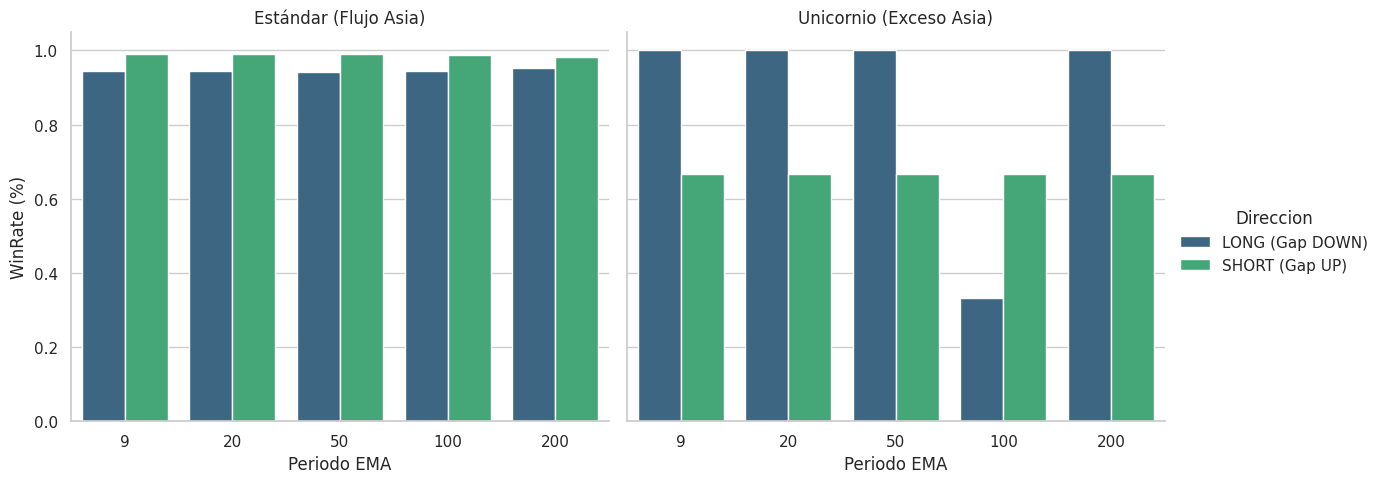


📊 TABLA DE SIMETRÍA AJUSTADA POR SESIÓN (ASIA):
                       Tipo        Direccion  EMA  Muestra   WinRate  \
5     Estándar (Flujo Asia)   SHORT (Gap UP)    9      415  0.990361   
6     Estándar (Flujo Asia)   SHORT (Gap UP)   20      415  0.990361   
7     Estándar (Flujo Asia)   SHORT (Gap UP)   50      415  0.990361   
8     Estándar (Flujo Asia)   SHORT (Gap UP)  100      414  0.987923   
9     Estándar (Flujo Asia)   SHORT (Gap UP)  200      411  0.982968   
4     Estándar (Flujo Asia)  LONG (Gap DOWN)  200      391  0.951407   
3     Estándar (Flujo Asia)  LONG (Gap DOWN)  100      404  0.945545   
0     Estándar (Flujo Asia)  LONG (Gap DOWN)    9      406  0.943350   
1     Estándar (Flujo Asia)  LONG (Gap DOWN)   20      406  0.943350   
2     Estándar (Flujo Asia)  LONG (Gap DOWN)   50      406  0.940887   
10  Unicornio (Exceso Asia)  LONG (Gap DOWN)    9        1  1.000000   
11  Unicornio (Exceso Asia)  LONG (Gap DOWN)   20        1  1.000000   
12  Unicornio (

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_simetria_empirica(df, periodos=[9, 20, 50, 100, 200]):
    """
    Calcula la asimetría real entre GAPs alcistas y bajistas basándose 
    únicamente en los datos históricos procesados, ajustando la SD a la sesión.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    # 1. Identificación de GAPs
    df_temp = df.copy()
    df_temp['time_diff'] = df_temp.index.to_series().diff()
    gap_indices = df_temp[df_temp['time_diff'] > pd.Timedelta(hours=24)].index
    
    # Pre-calculamos EMAs
    for p in periodos:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

    # Cálculo de métricas de desangre específicas de ASIA (primeras 6 horas)
    all_asia_excursions = []
    for open_time in gap_indices:
        try:
            idx = df.index.get_loc(open_time)
            c_v = df.iloc[idx - 1]['Close']
            a_d = df.iloc[idx]['Open']
            # Solo miramos la ventana de Asia para la estadística base
            post_asia = df.iloc[idx : idx + 360]
            if (a_d - c_v) > 0:
                exc = a_d - post_asia['Low'].min()
            else:
                exc = post_asia['High'].max() - a_d
            all_asia_excursions.append(exc)
        except: continue
    
    # Media y Desviación exclusiva de la sesión de Asia
    mu_asia, sigma_asia = np.mean(all_asia_excursions), np.std(all_asia_excursions)

    results = []
    for open_time in gap_indices:
        try:
            idx_ap = df.index.get_loc(open_time)
            cierre_v = df.iloc[idx_ap - 1]['Close']
            apertura_d = df.iloc[idx_ap]['Open']
            
            es_gap_up = (apertura_d - cierre_v) > 0
            dir_label = "SHORT (Gap UP)" if es_gap_up else "LONG (Gap DOWN)"
            
            post_gap = df.iloc[idx_ap : idx_ap + 1080].copy()
            ventana_asia = post_gap.iloc[:360] 
            
            # SL: 5 puntos fuera del extremo de Asia
            val_ext = ventana_asia['Low'].min() if es_gap_up else ventana_asia['High'].max()
            sl_p = val_ext - 5 if es_gap_up else val_ext + 5

            for p in periodos:
                ema_col = f'ema_{p}'
                for i in range(1, len(ventana_asia)):
                    row = ventana_asia.iloc[i]
                    prev_row = ventana_asia.iloc[i-1]
                    
                    # Cálculo de SD relativo a ASIA
                    exc_actual = (apertura_d - row['Low']) if es_gap_up else (row['High'] - apertura_d)
                    sd_actual = (exc_actual - mu_asia) / sigma_asia
                    
                    # Filtro de entrada (Cruce + Confirmación)
                    cruce = (row['Close'] > row[ema_col]) if es_gap_up else (row['Close'] < row[ema_col])
                    confirmacion = (row['Close'] > prev_row['High']) if es_gap_up else (row['Close'] < prev_row['Low'])
                    
                    if cruce and confirmacion:
                        futuro = post_gap.loc[ventana_asia.index[i]:]
                        exito = False
                        pnl = 0
                        for ts_f, row_f in futuro.iterrows():
                            if (es_gap_up and row_f['Low'] <= sl_p) or (not es_gap_up and row_f['High'] >= sl_p):
                                exito = False
                                pnl = -abs(row['Close'] - sl_p)
                                break
                            if (es_gap_up and row_f['High'] >= cierre_v) or (not es_gap_up and row_f['Low'] <= cierre_v):
                                exito = True
                                pnl = abs(row['Close'] - cierre_v)
                                break
                        
                        results.append({
                            'Direccion': dir_label,
                            'EMA': p,
                            'SD_Entrada': sd_actual,
                            'Exito': 1 if exito else 0,
                            'PnL': pnl
                        })
                        break
        except: continue

    df_res = pd.DataFrame(results)
    
    # Definimos Unicornio con SD relativa a Asia (más frecuente)
    df_res['Tipo'] = df_res['SD_Entrada'].apply(lambda x: 'Unicornio (Exceso Asia)' if x >= 1.5 else 'Estándar (Flujo Asia)')
    
    stats = df_res.groupby(['Tipo', 'Direccion', 'EMA']).agg({
        'Exito': ['count', 'mean'],
        'PnL': 'mean'
    }).reset_index()
    stats.columns = ['Tipo', 'Direccion', 'EMA', 'Muestra', 'WinRate', 'EV']

    # Visualización
    g = sns.catplot(
        data=stats, kind="bar",
        x="EMA", y="WinRate", hue="Direccion", col="Tipo",
        palette="viridis", height=5, aspect=1.2
    )
    g.set_axis_labels("Periodo EMA", "WinRate (%)")
    g.set_titles("{col_name}")
    plt.show()

    return stats

# Ejecución
try:
    df_raw = pd.read_parquet('/home/quant/data/processed/nq_1m_continuous.parquet')
    df_simetria = calcular_simetria_empirica(df_raw)
    
    print("\n📊 TABLA DE SIMETRÍA AJUSTADA POR SESIÓN (ASIA):")
    print(df_simetria.sort_values(by=['Tipo', 'WinRate'], ascending=[True, False]))

except Exception as e:
    print(f"Error: {e}")